DISPLAYING ALL SAVED FIGURES


### ROC Curves - Full Test Models

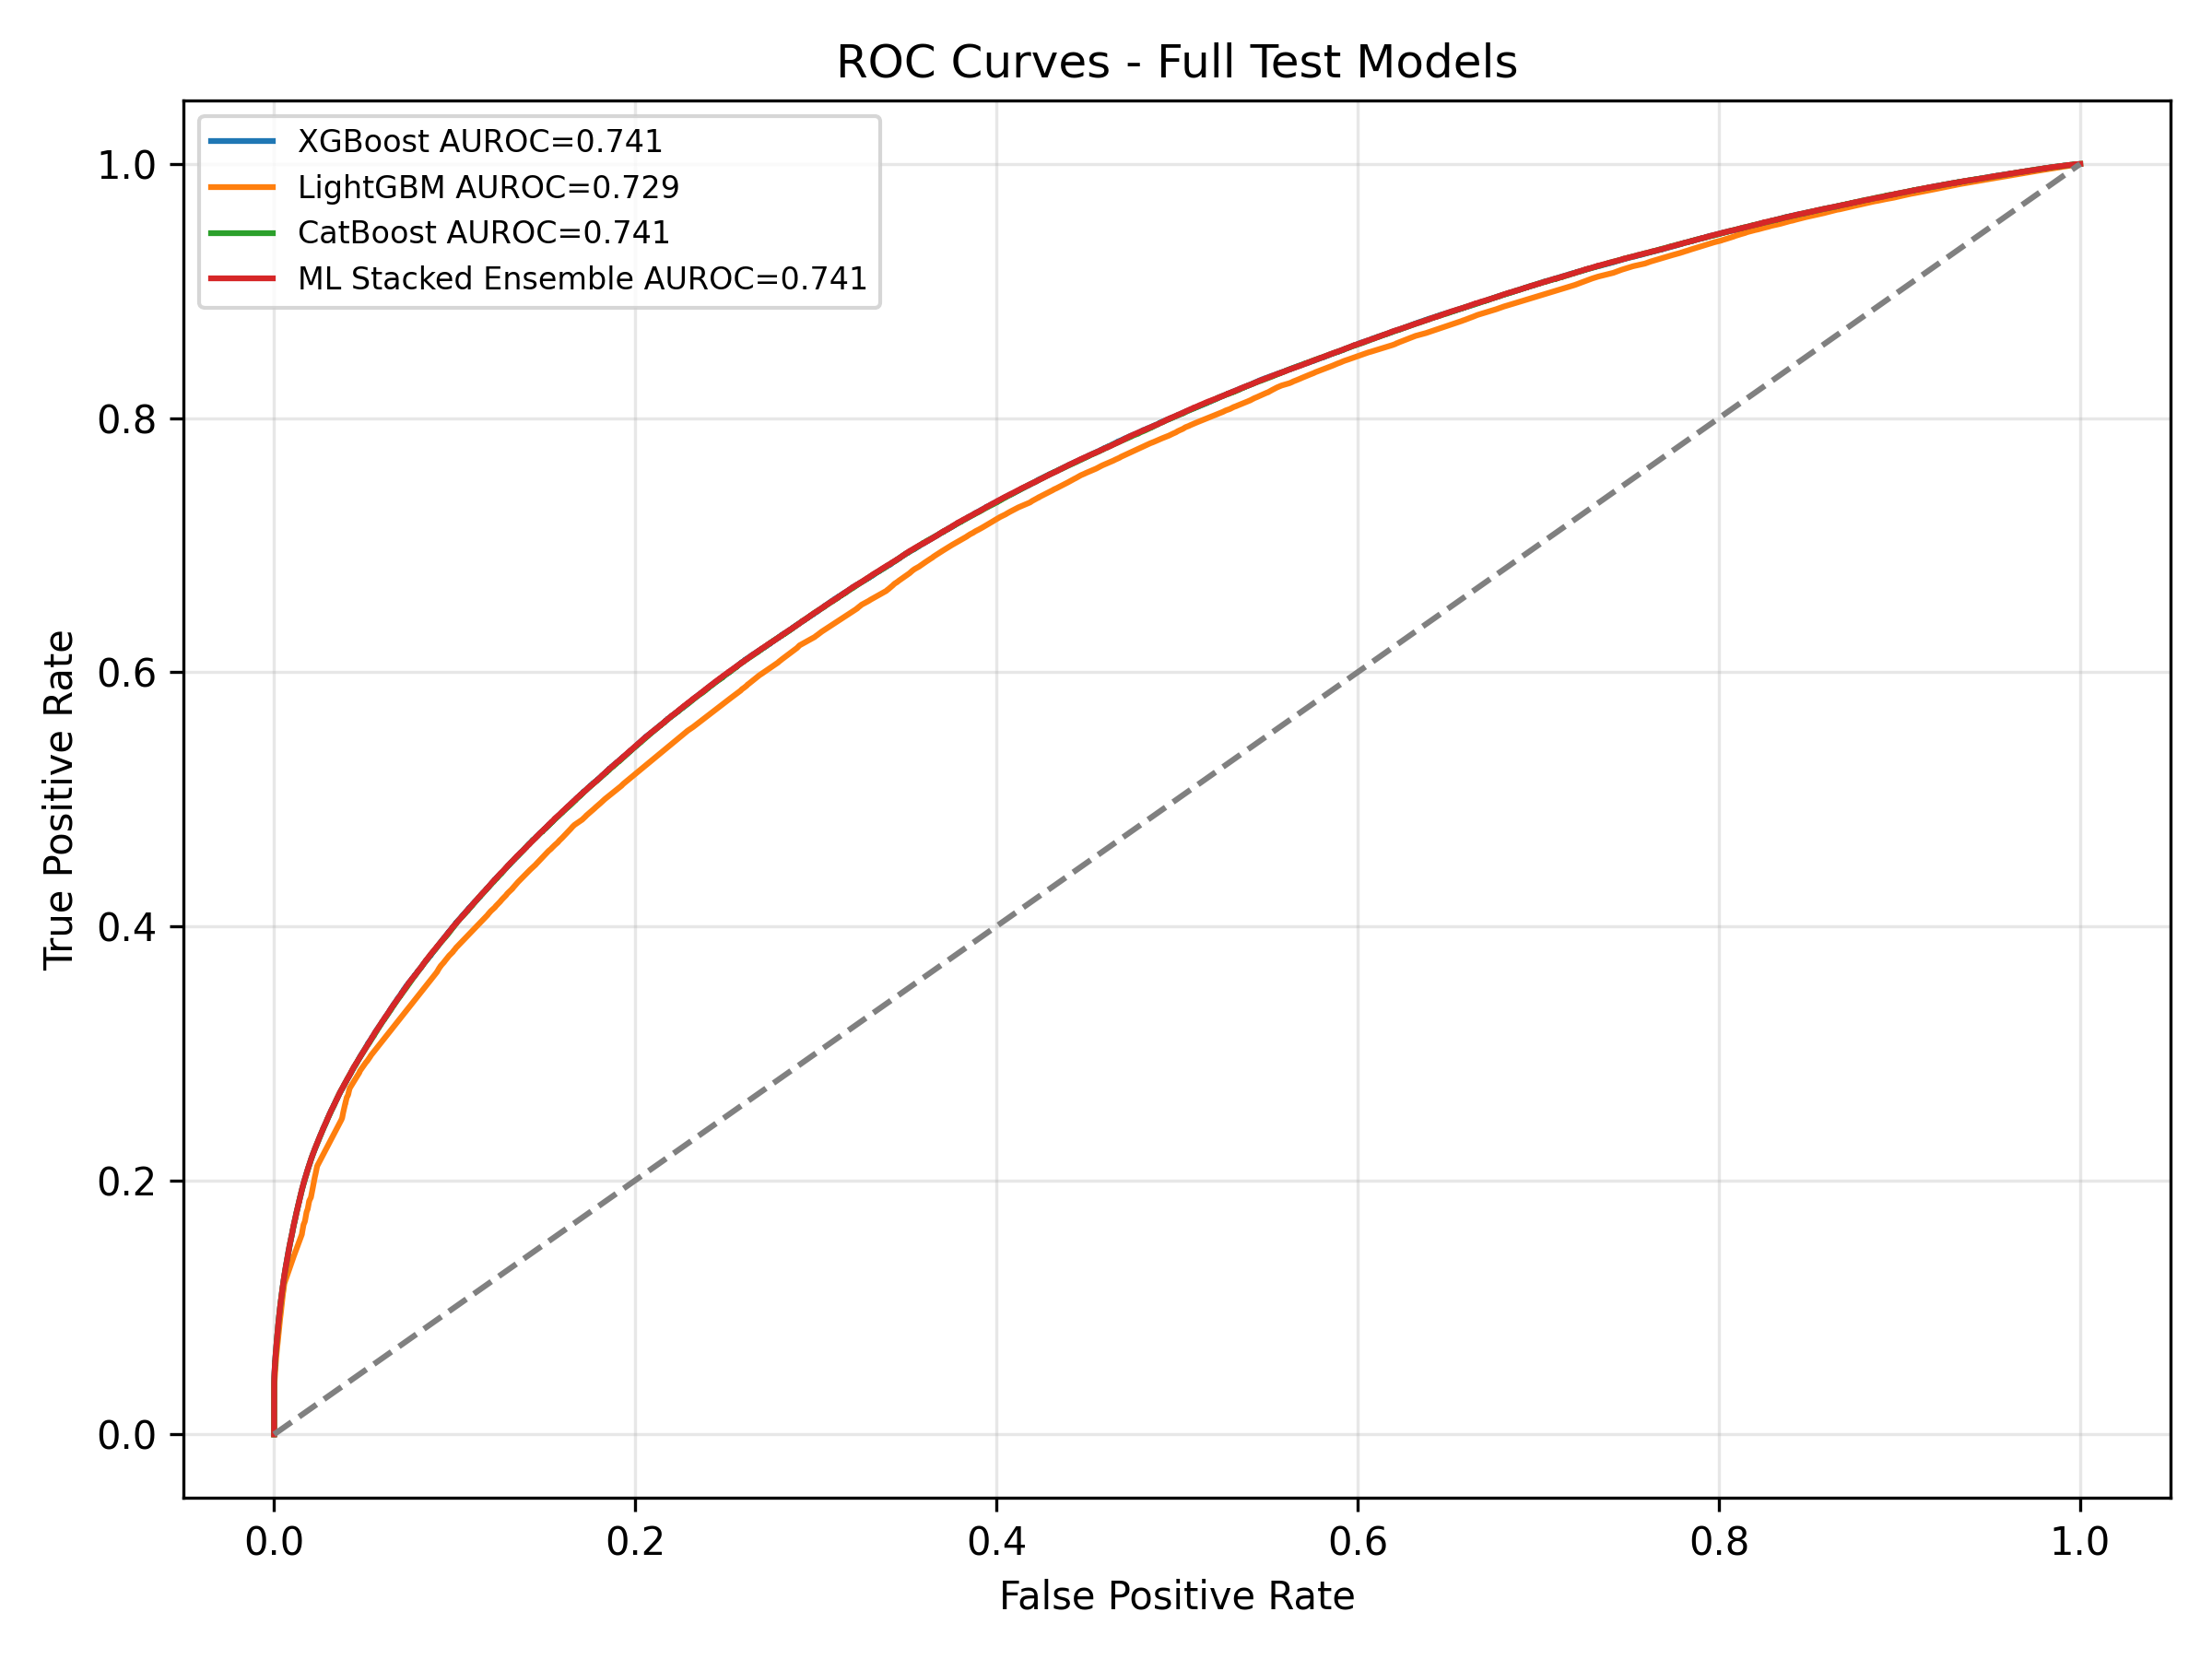

### Precision-Recall Curves - Full Test Models

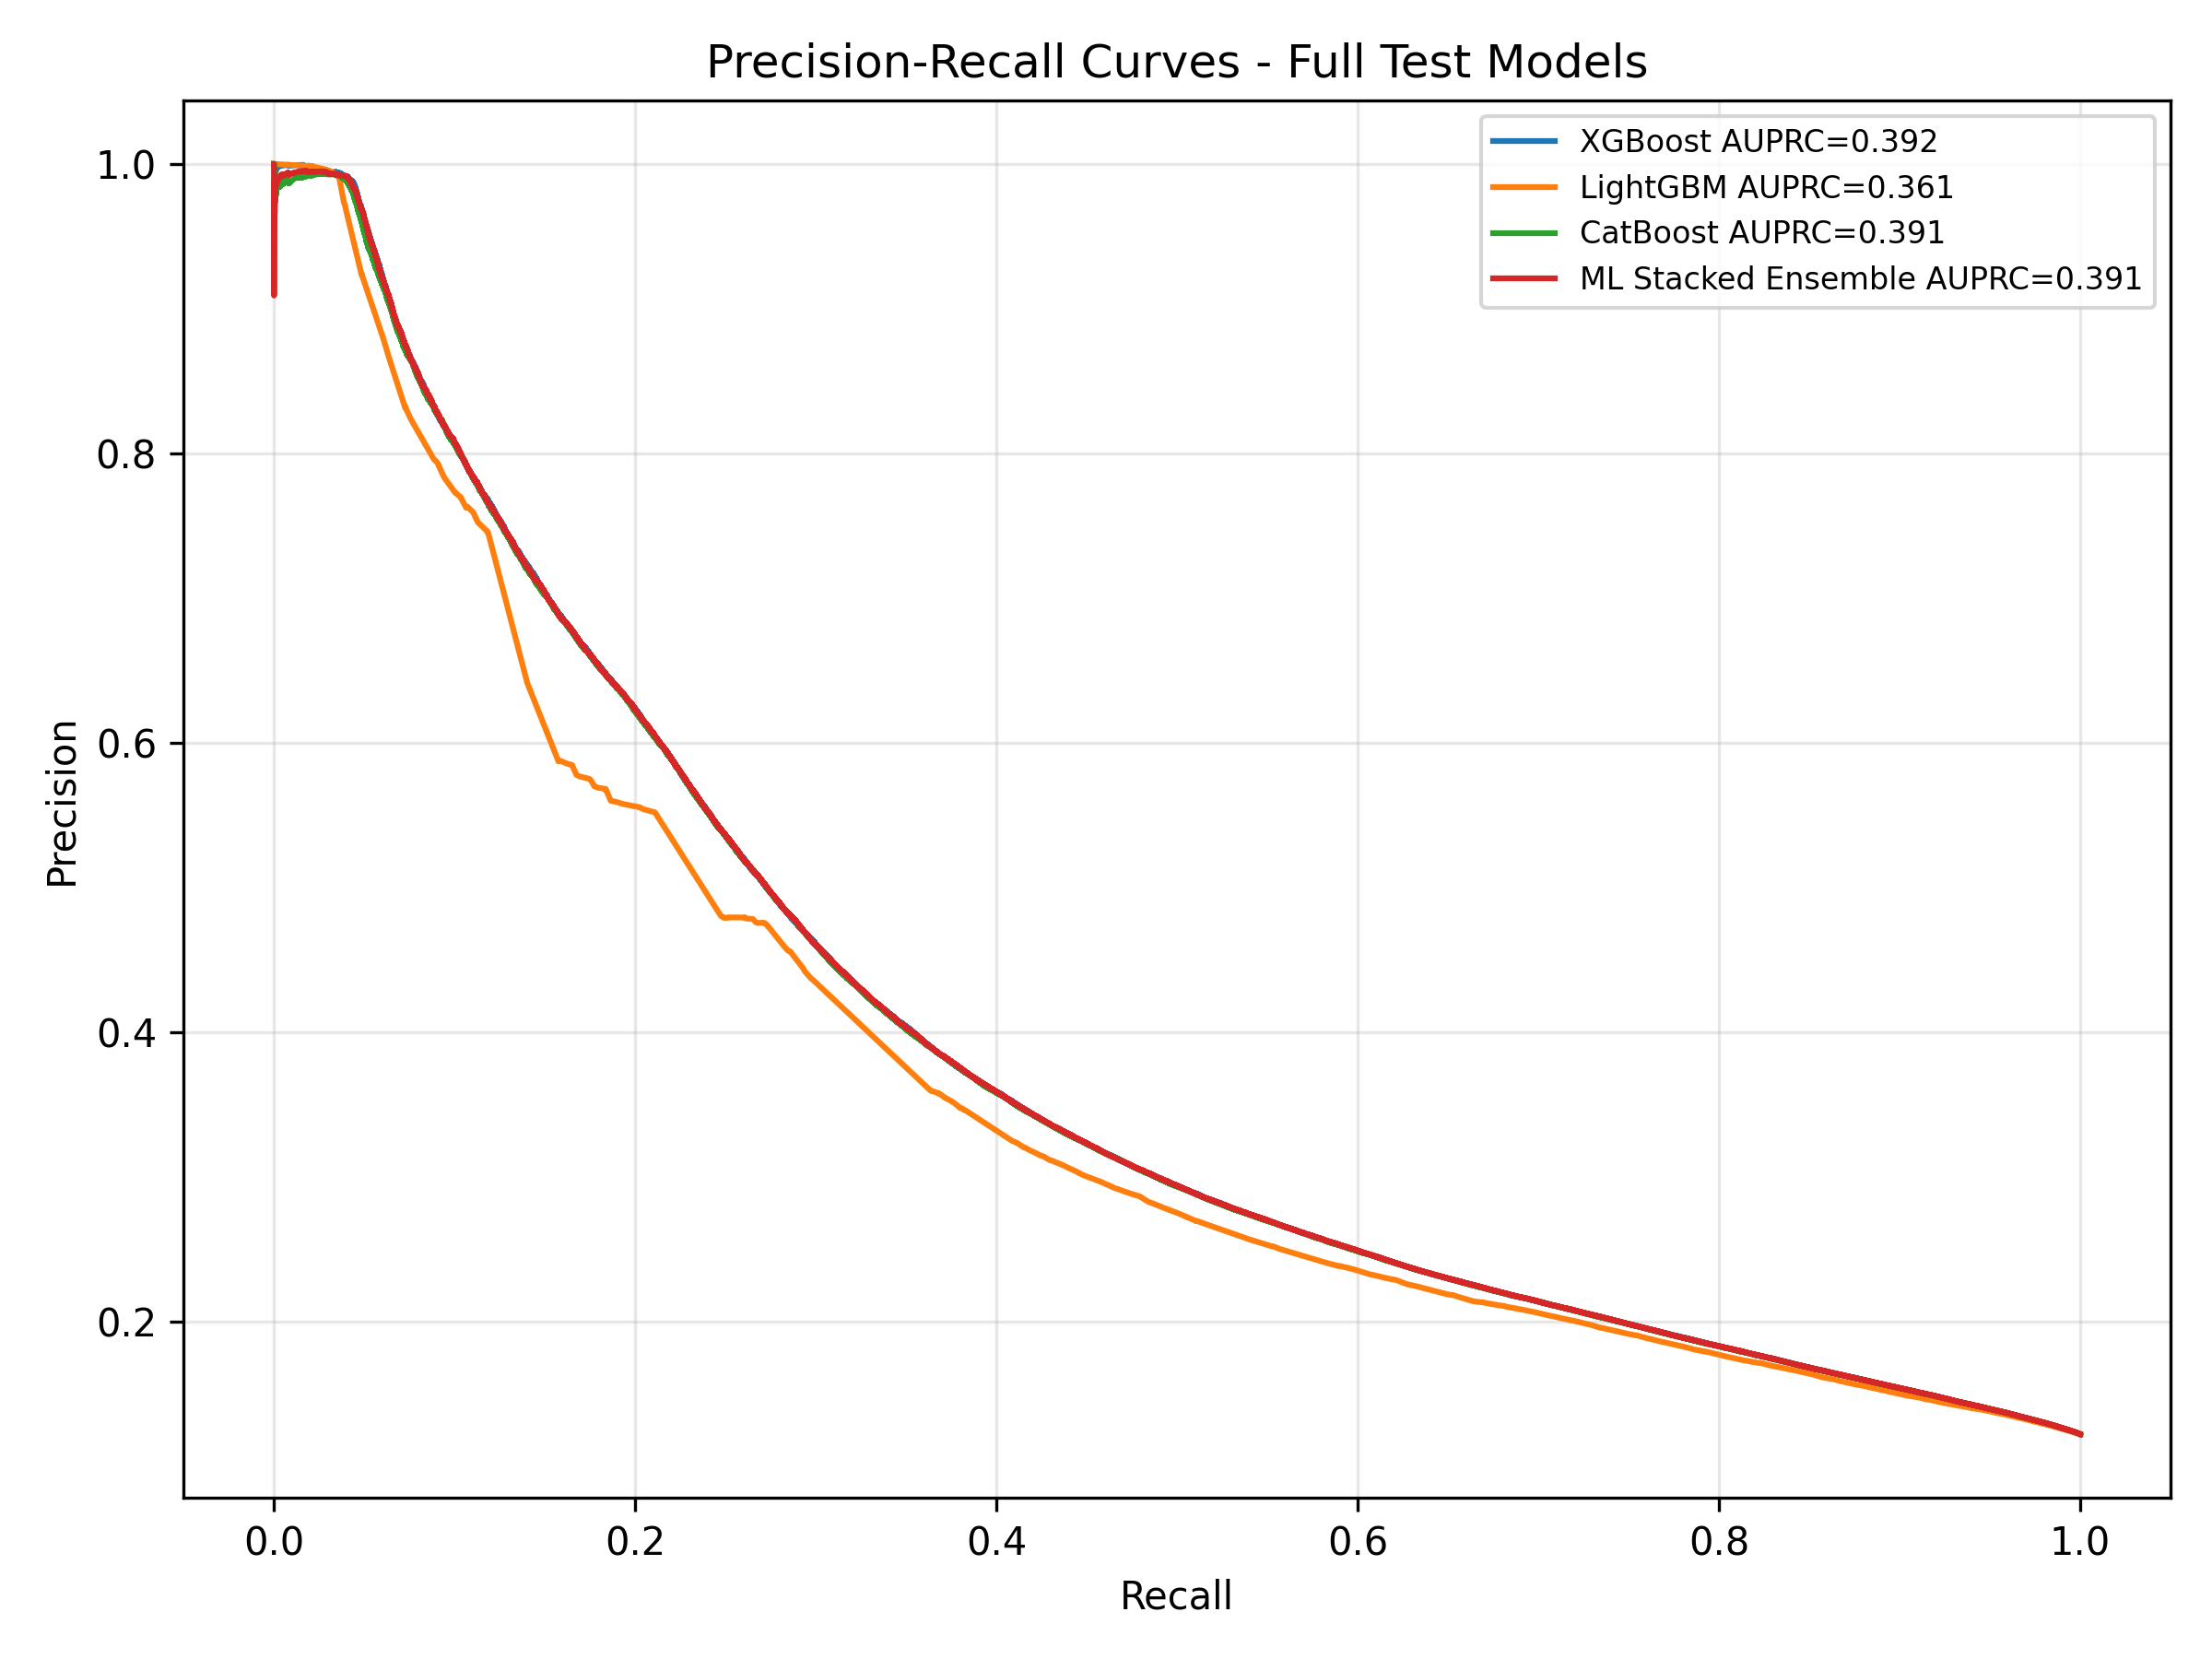

### Calibration Curves - Full Test Models

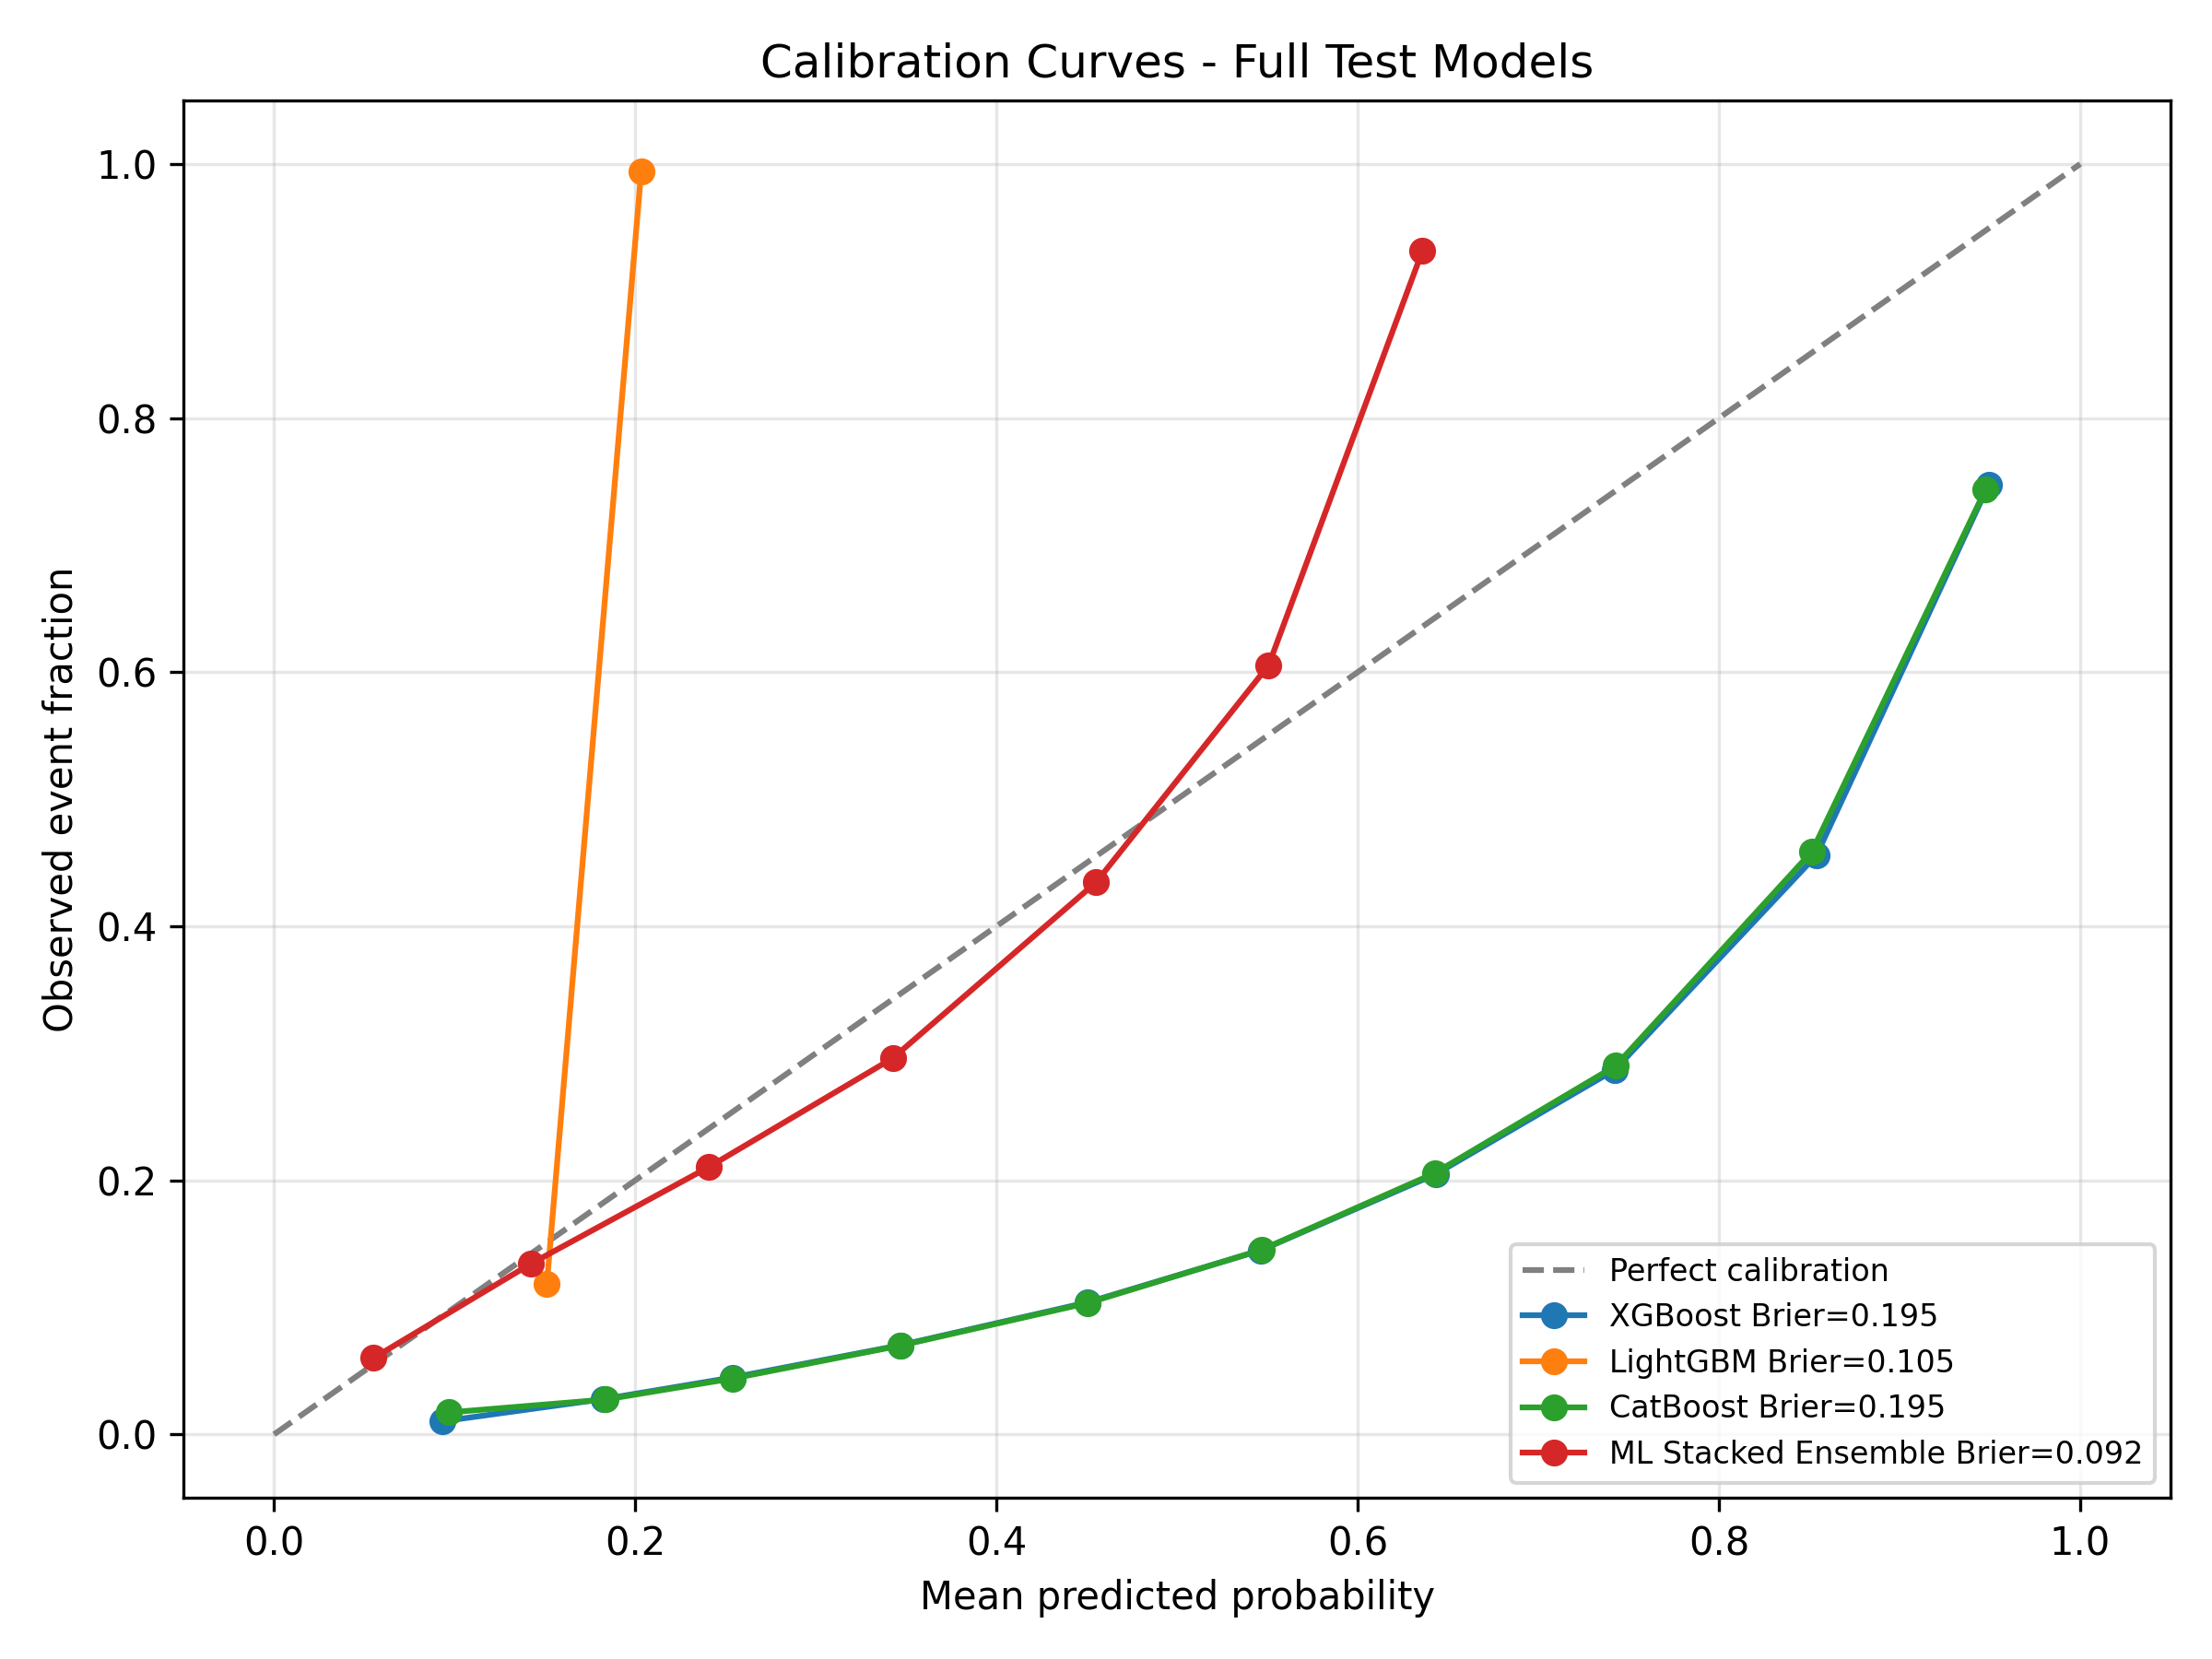

### CNN ROC Curves - CNN Test Subset

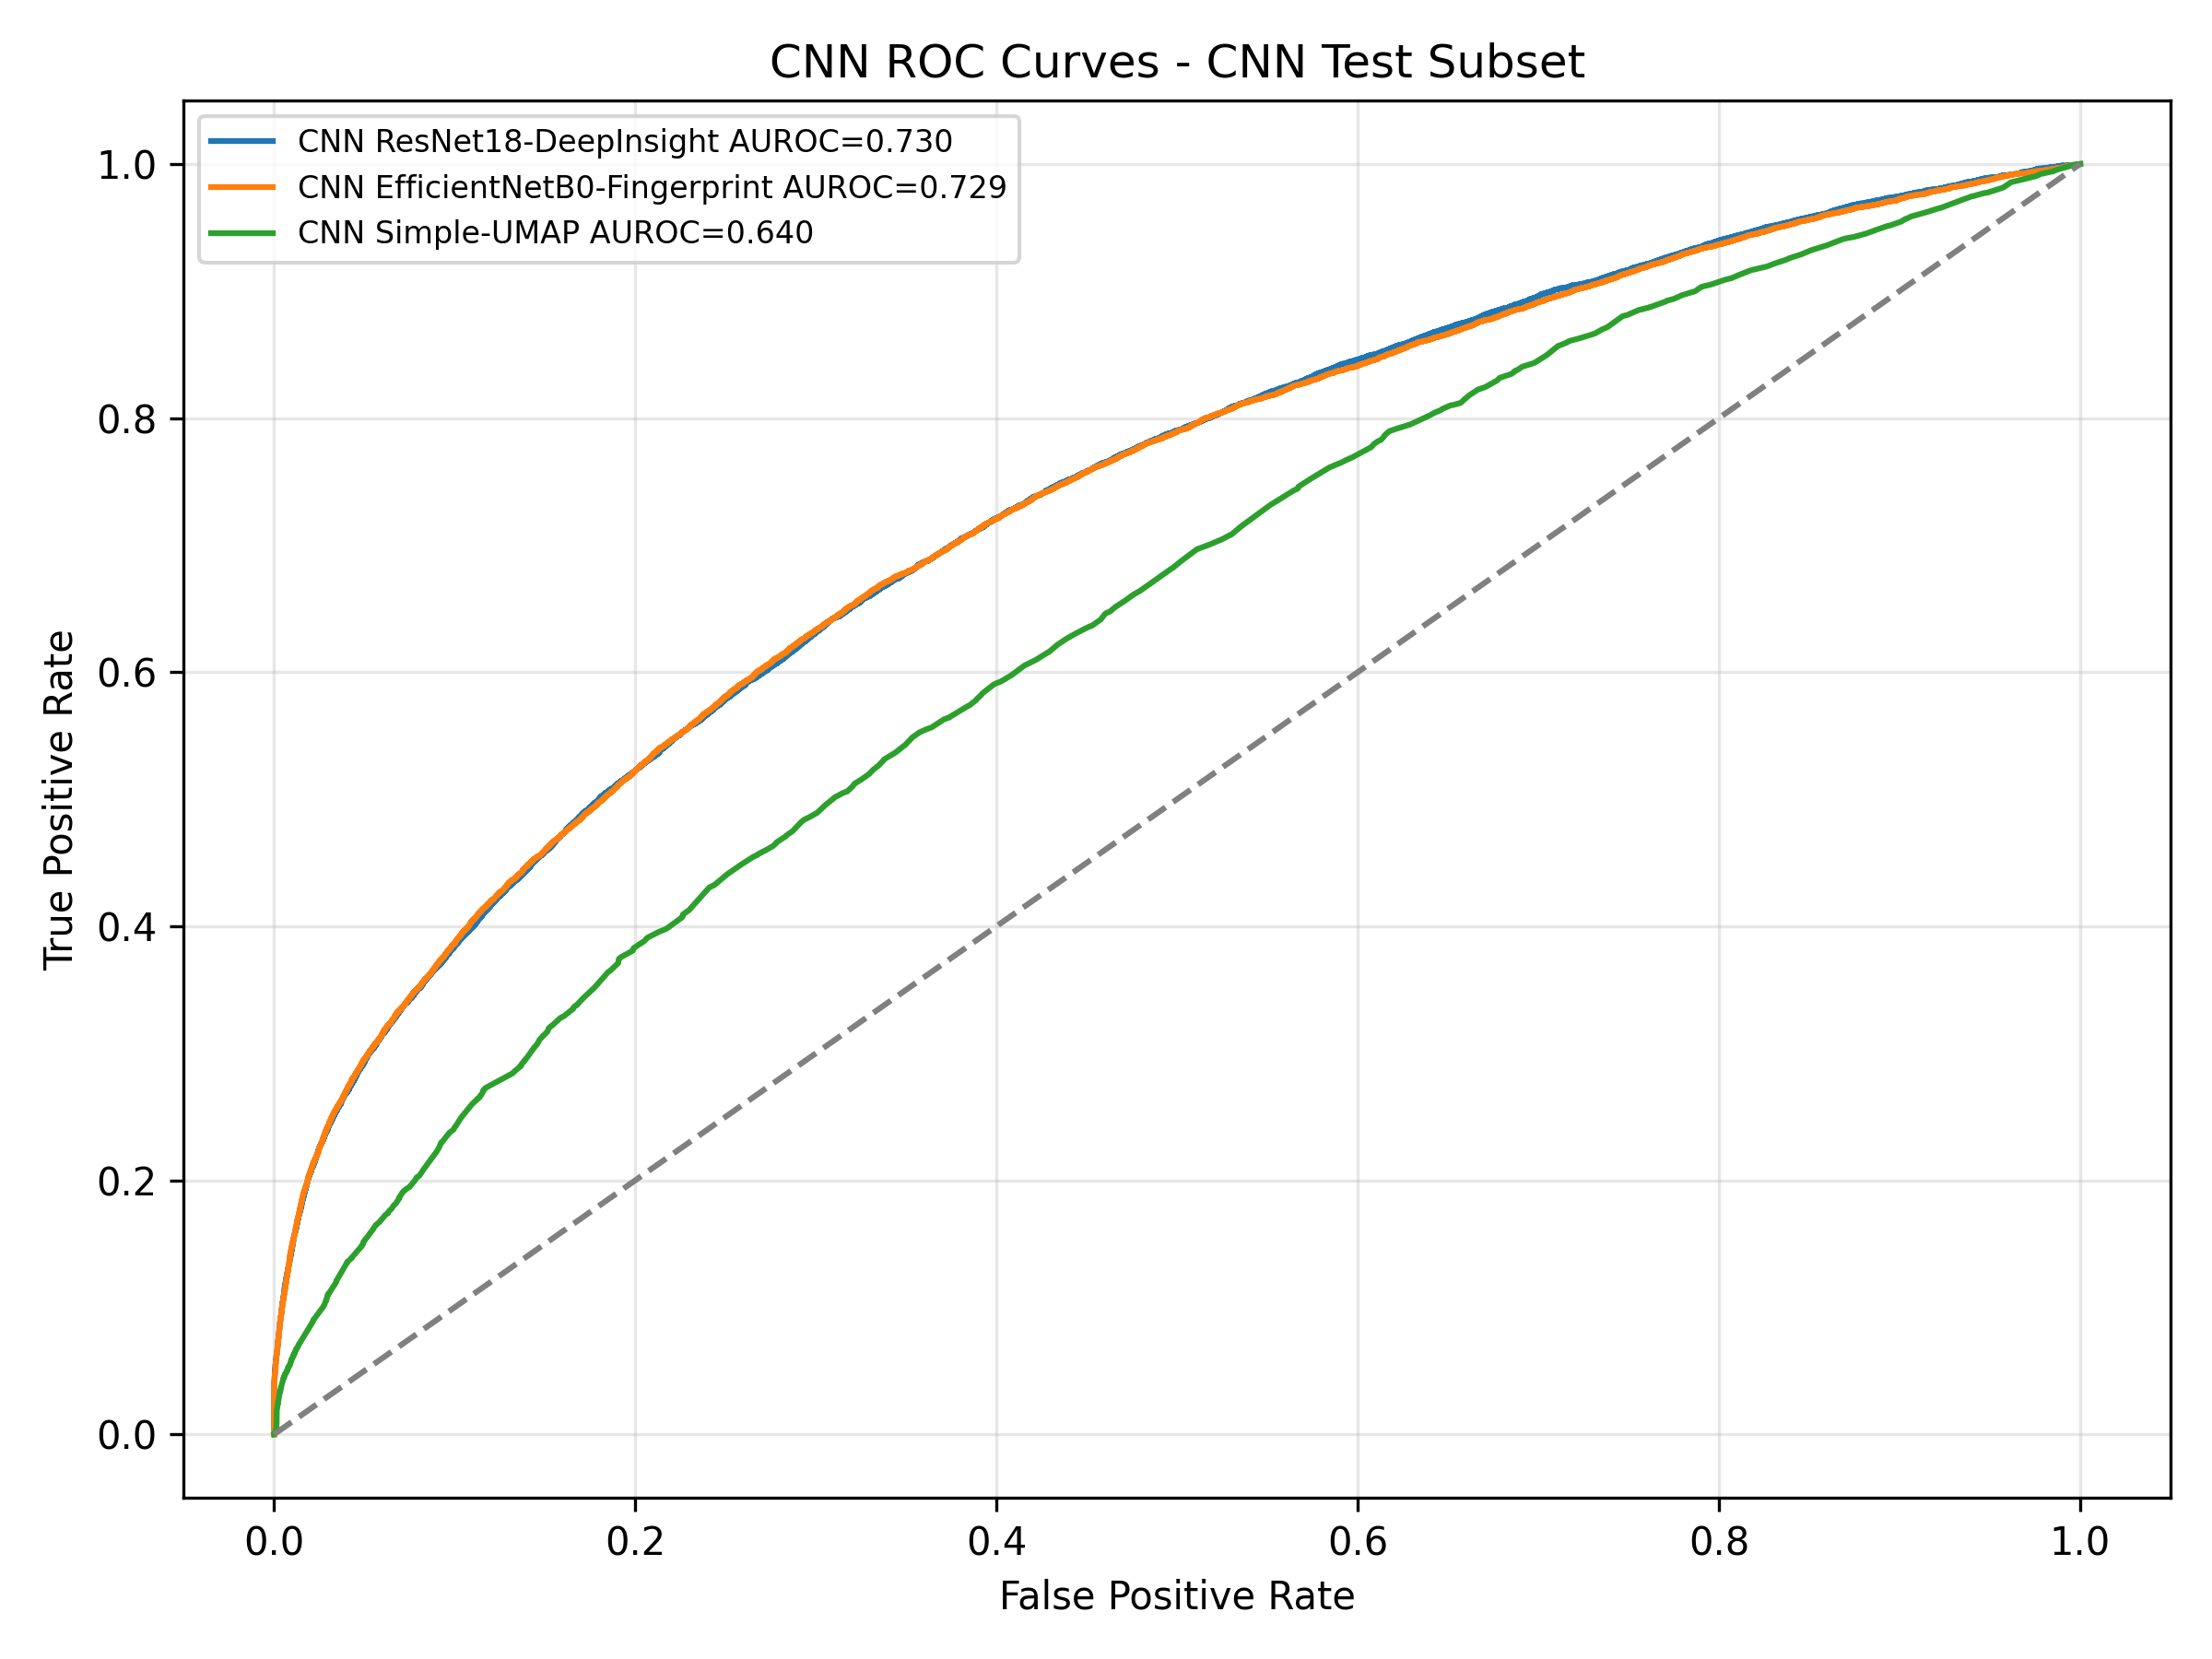

### CNN Precision-Recall Curves - CNN Test Subset

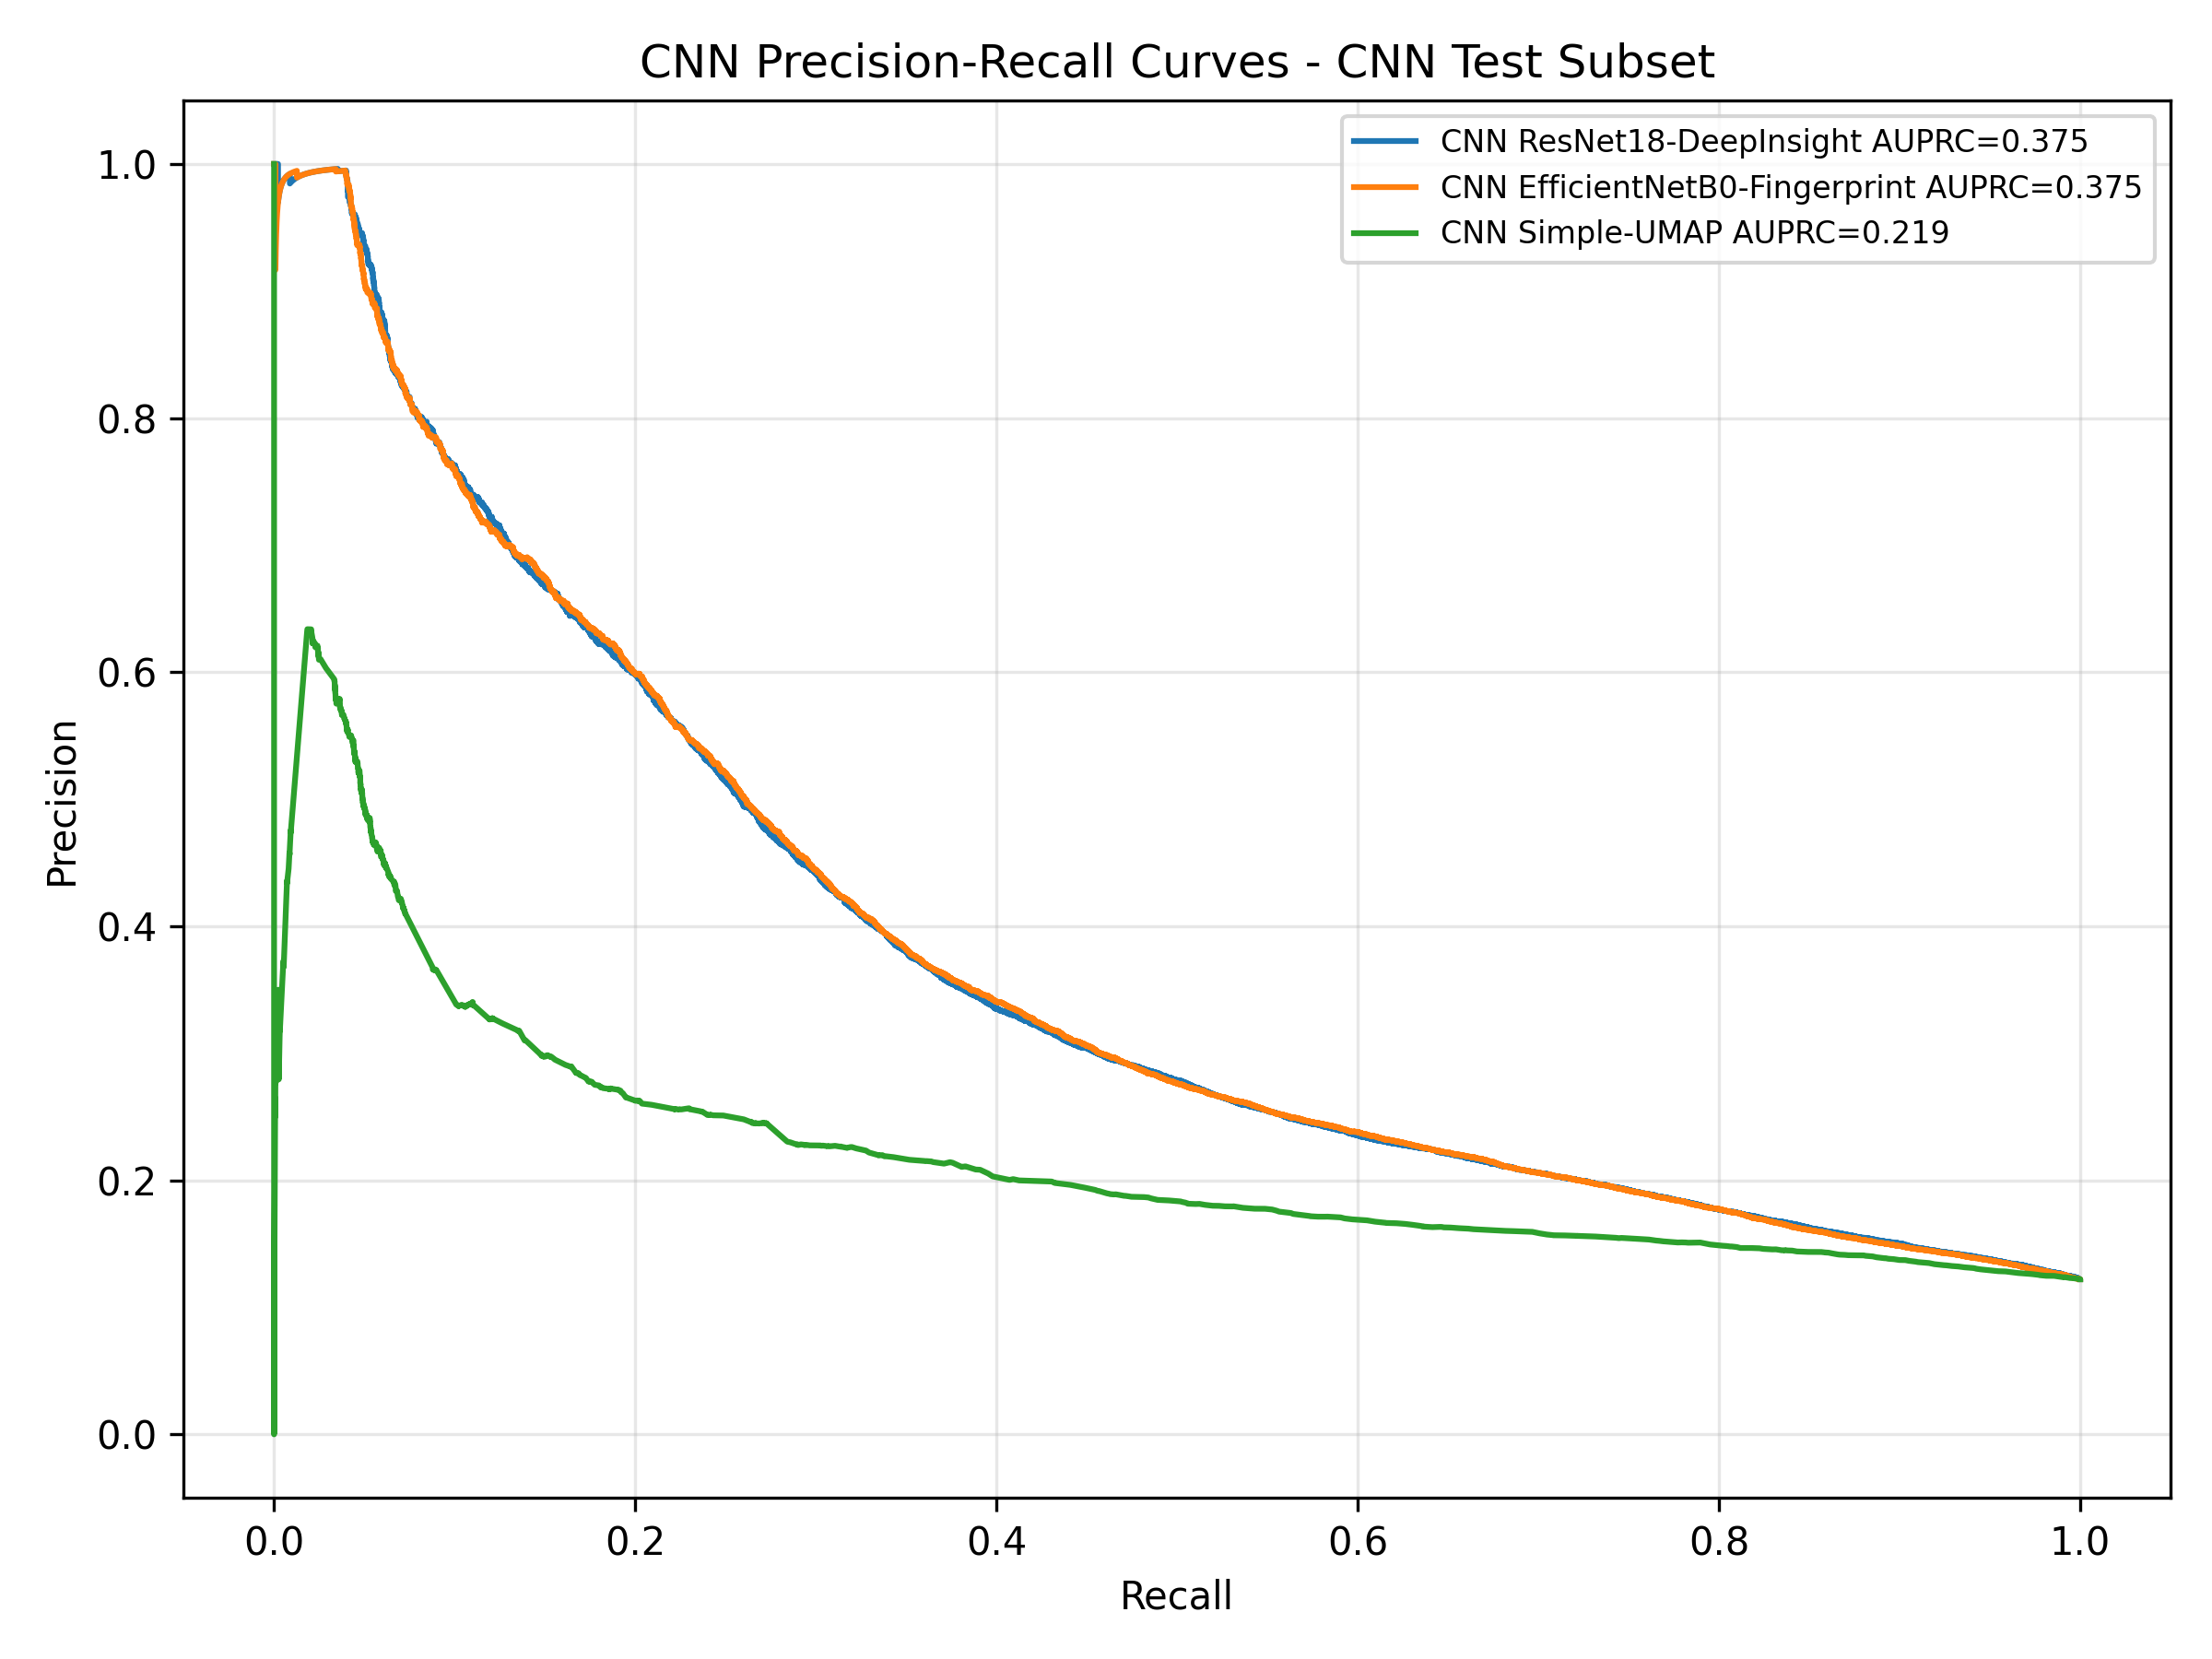

### XGBoost Feature Importance (Top 25)

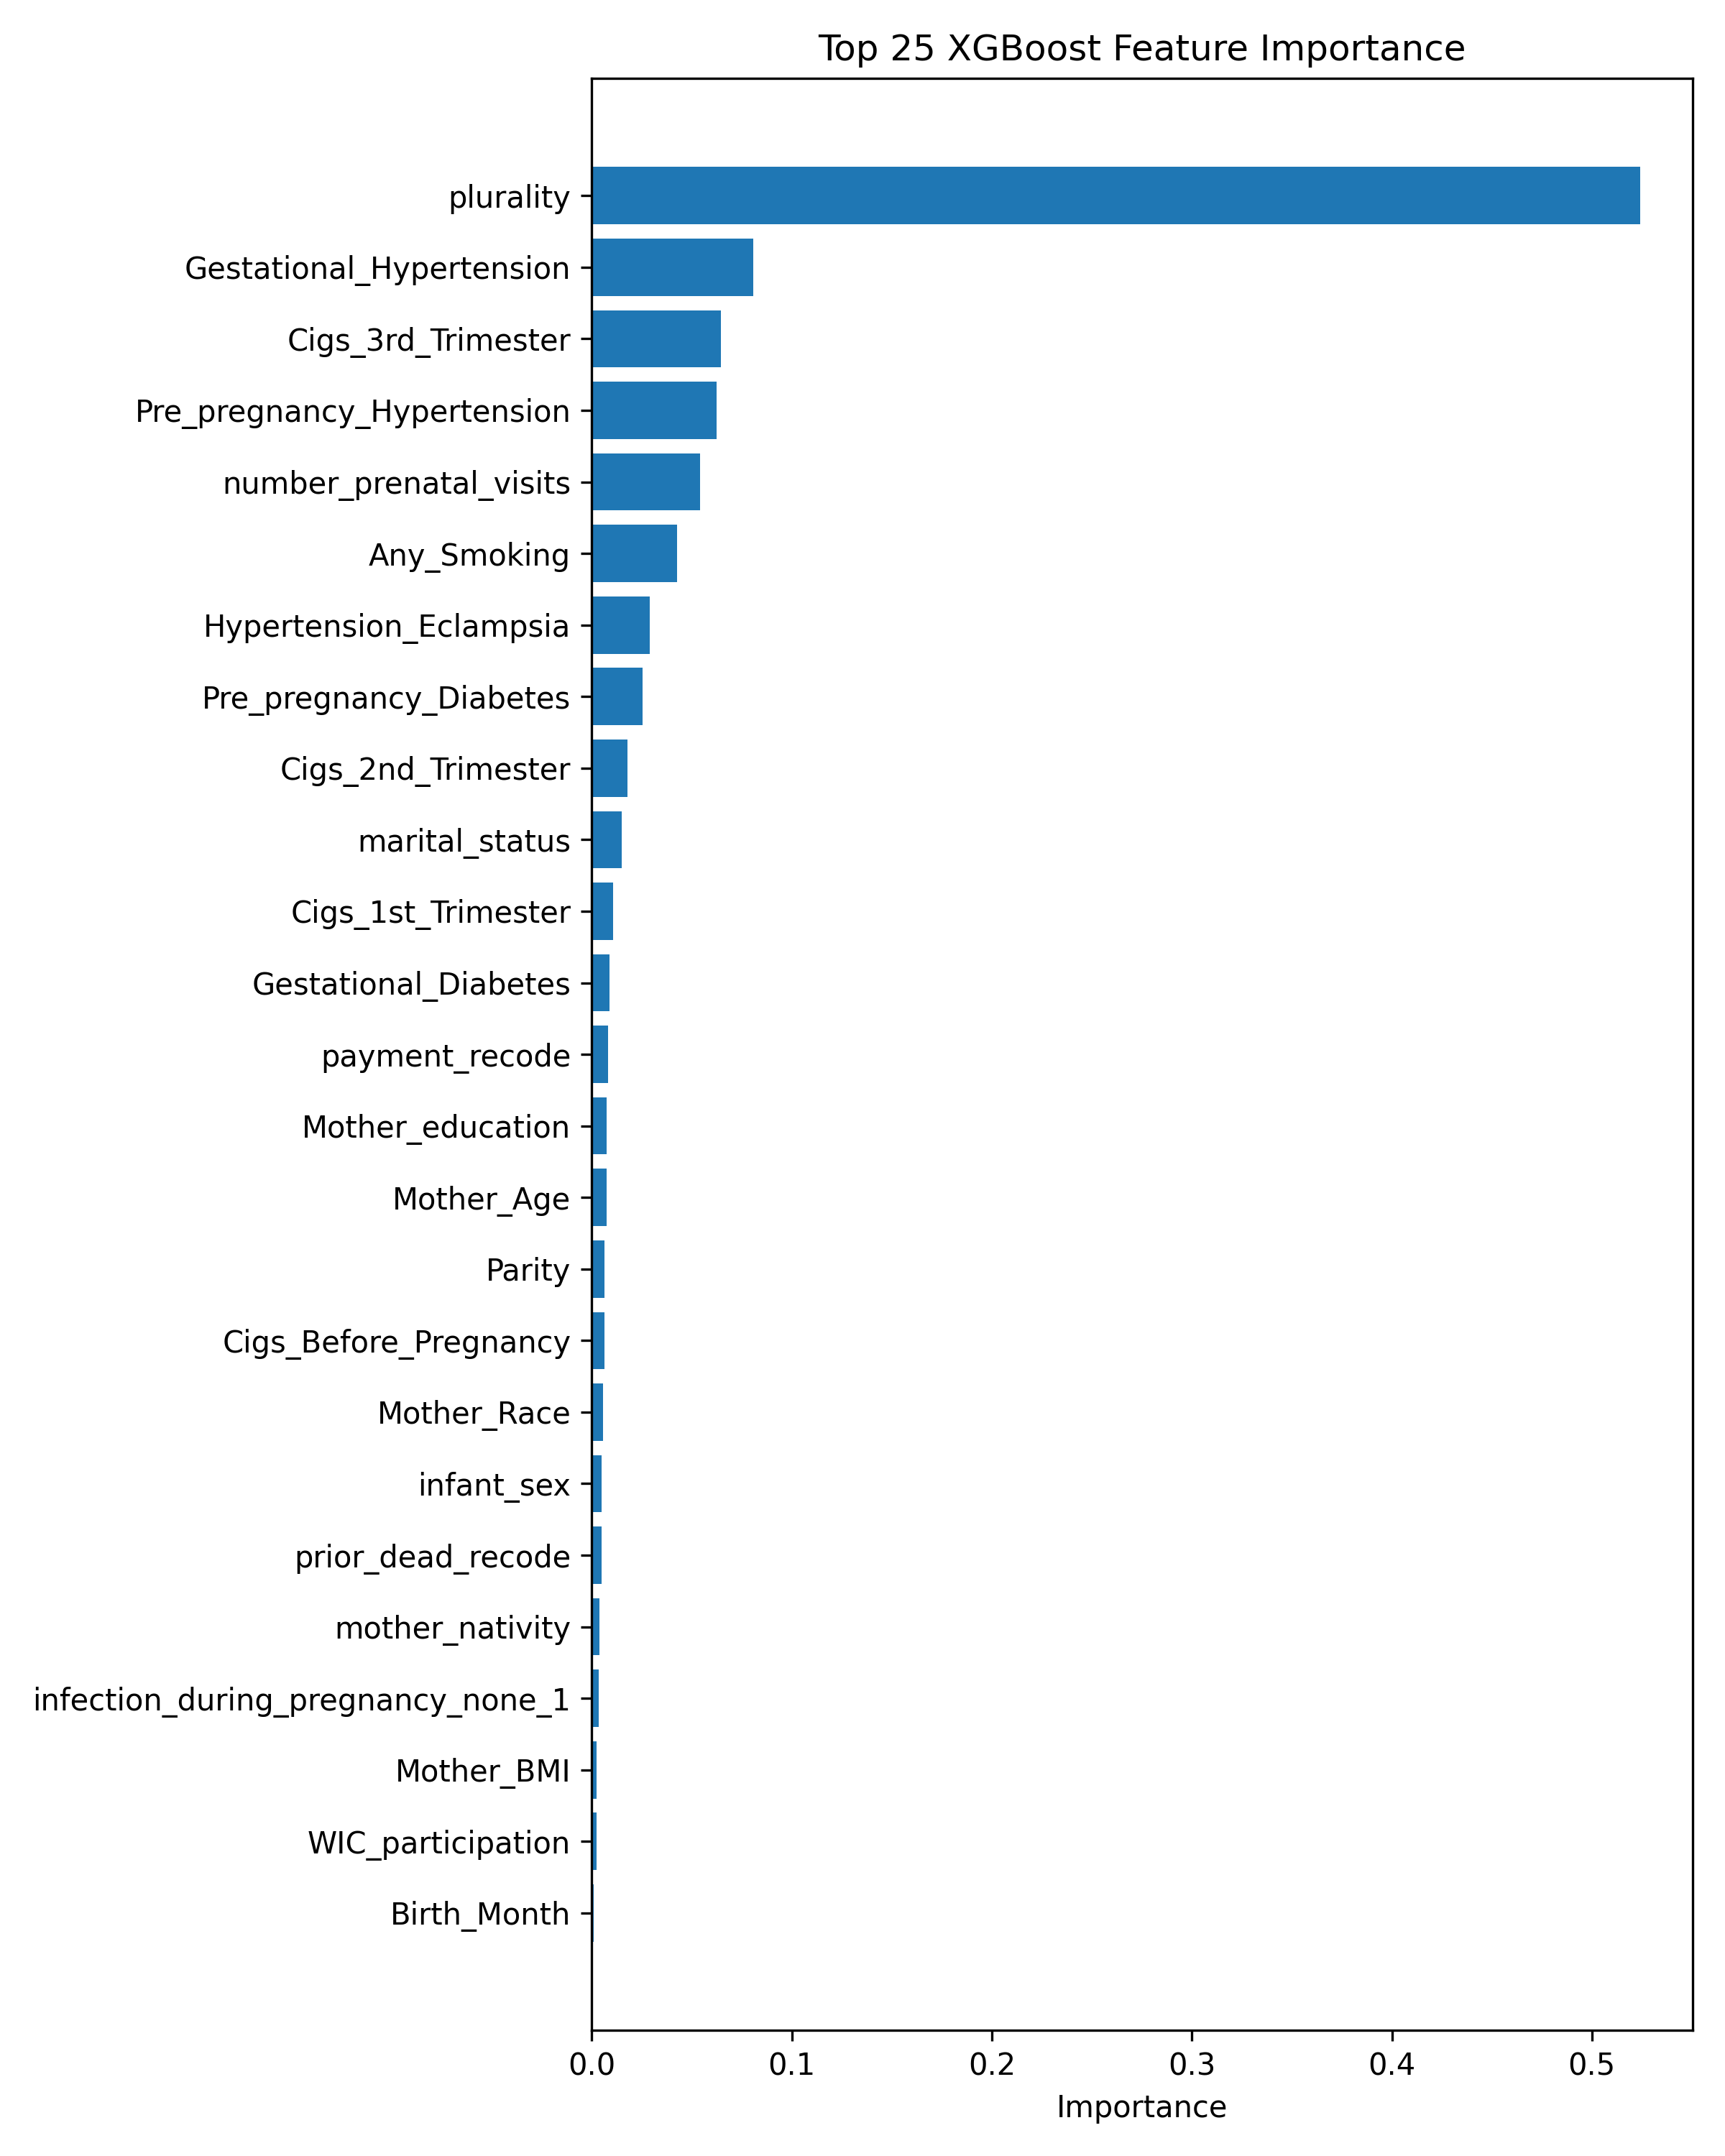

### SHAP Summary Plot

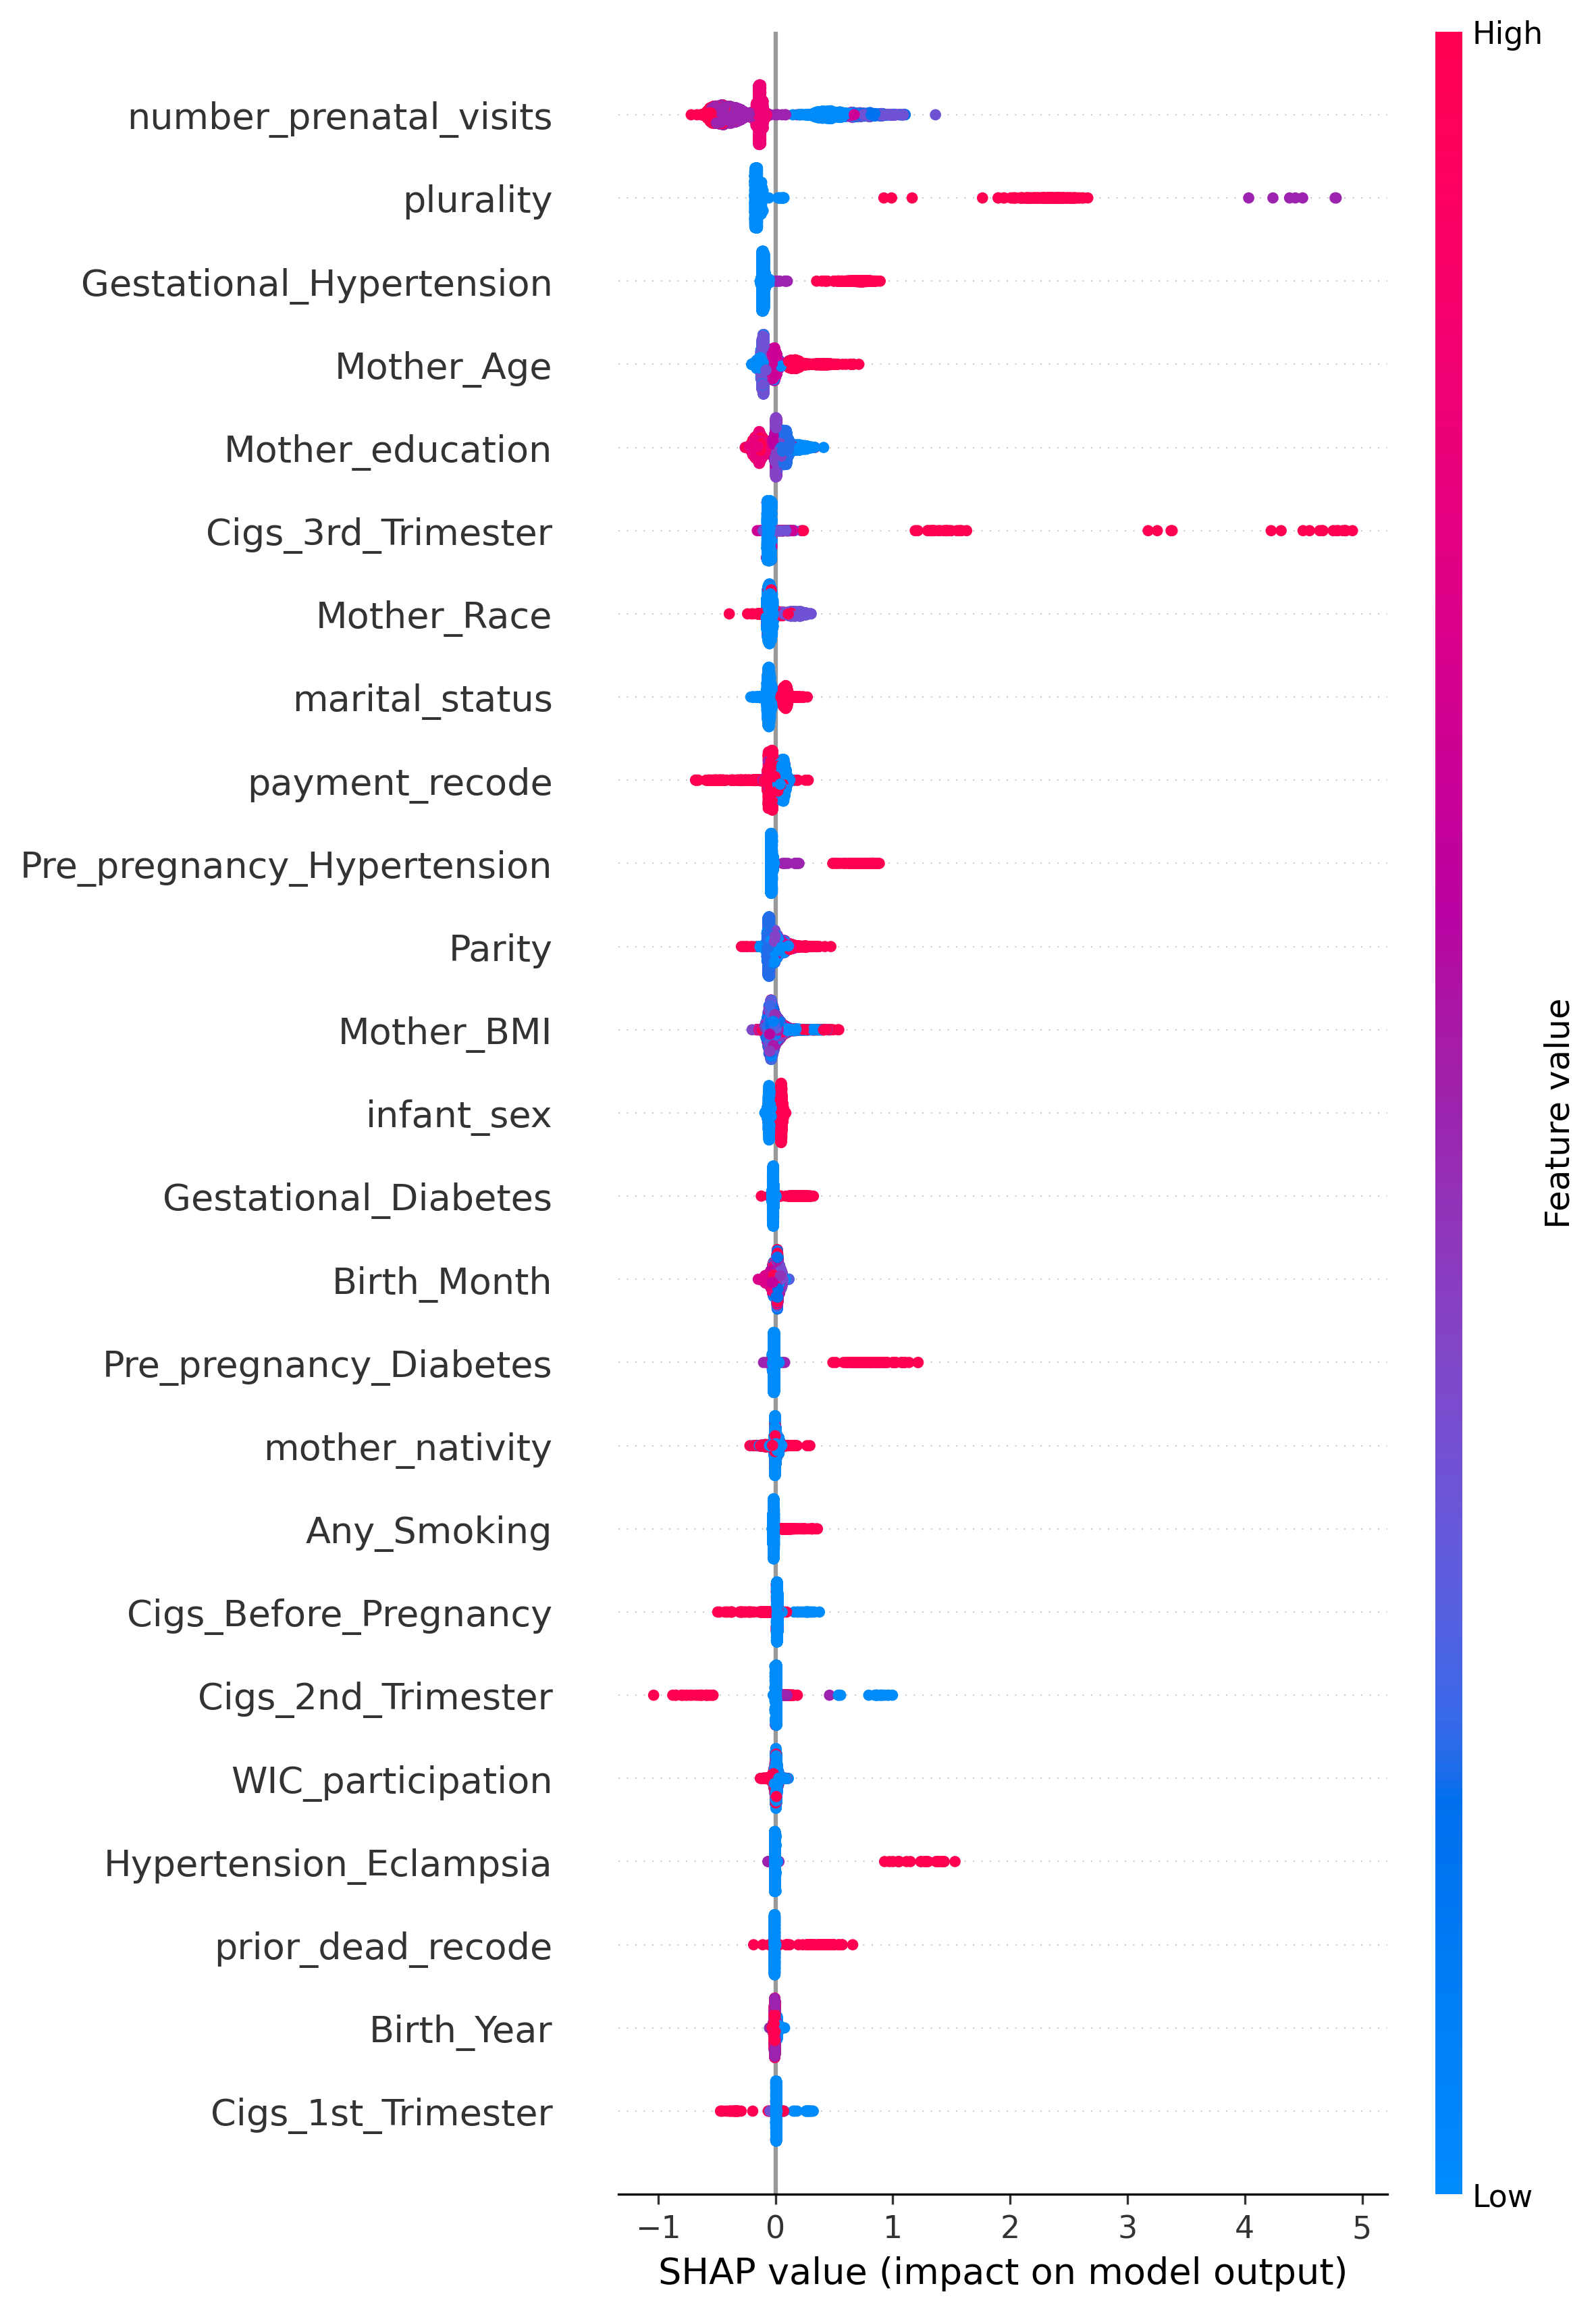

### Decision Curve Analysis

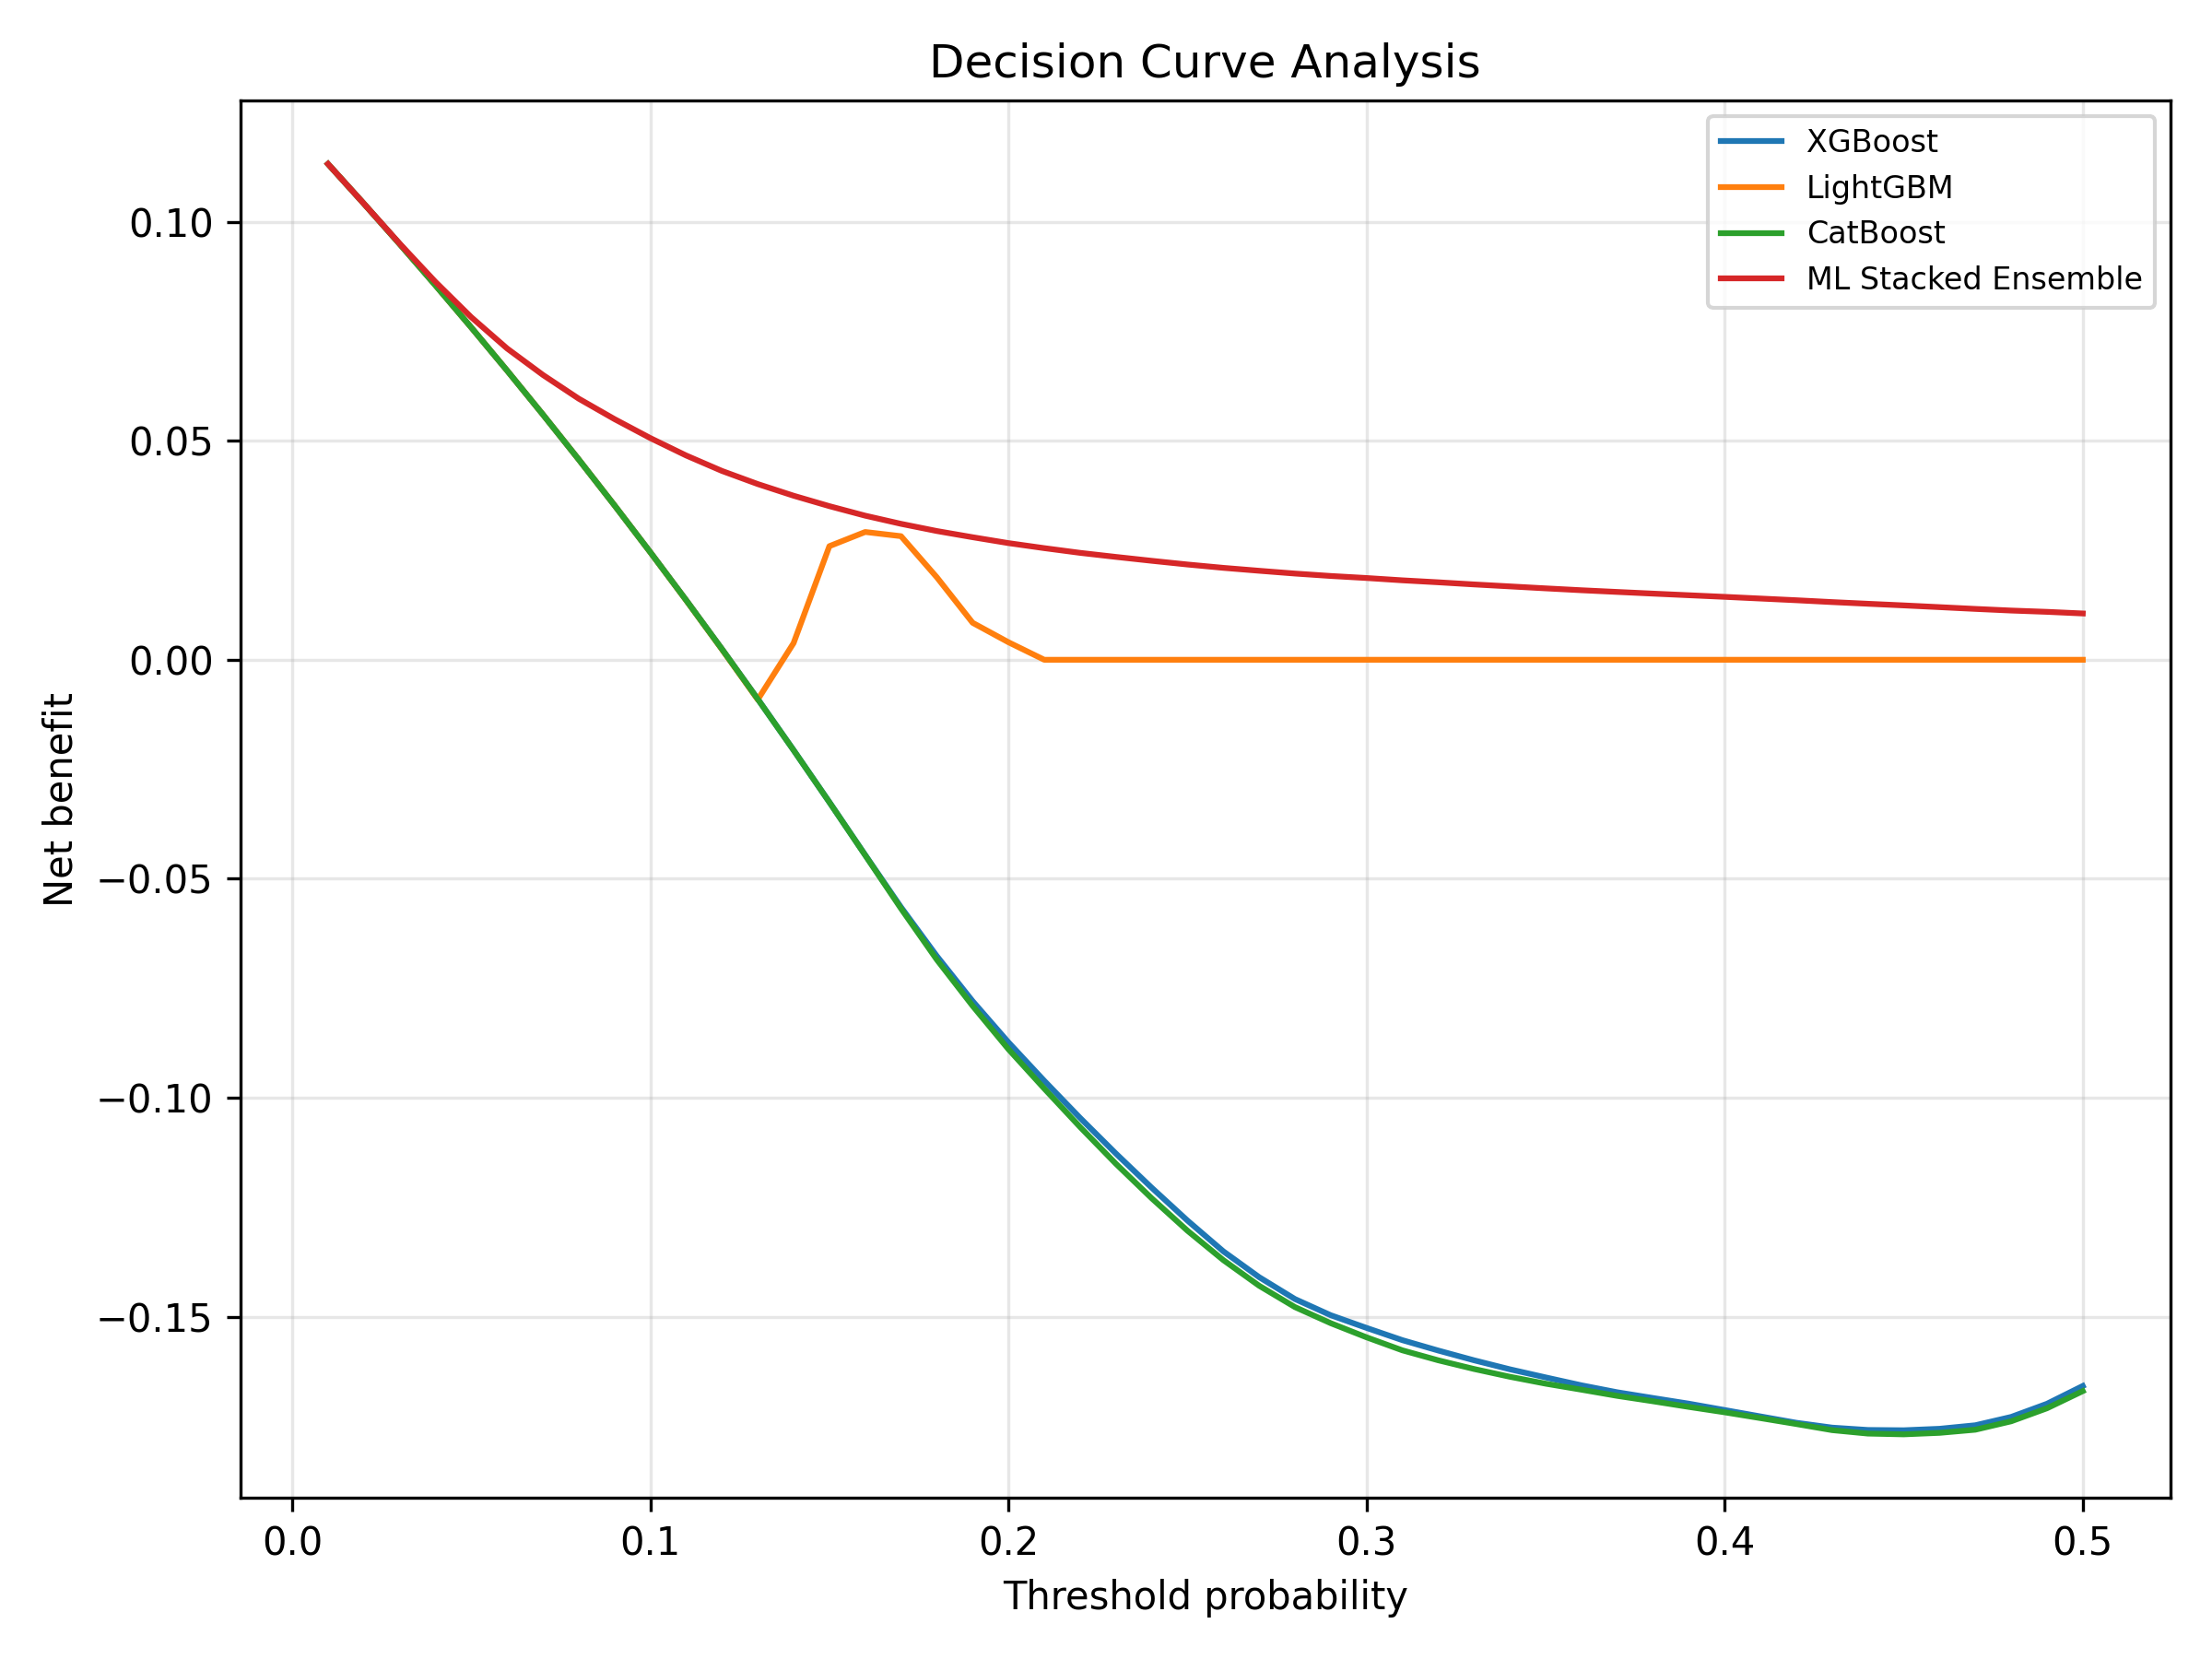

### CNN Validation AUROC History

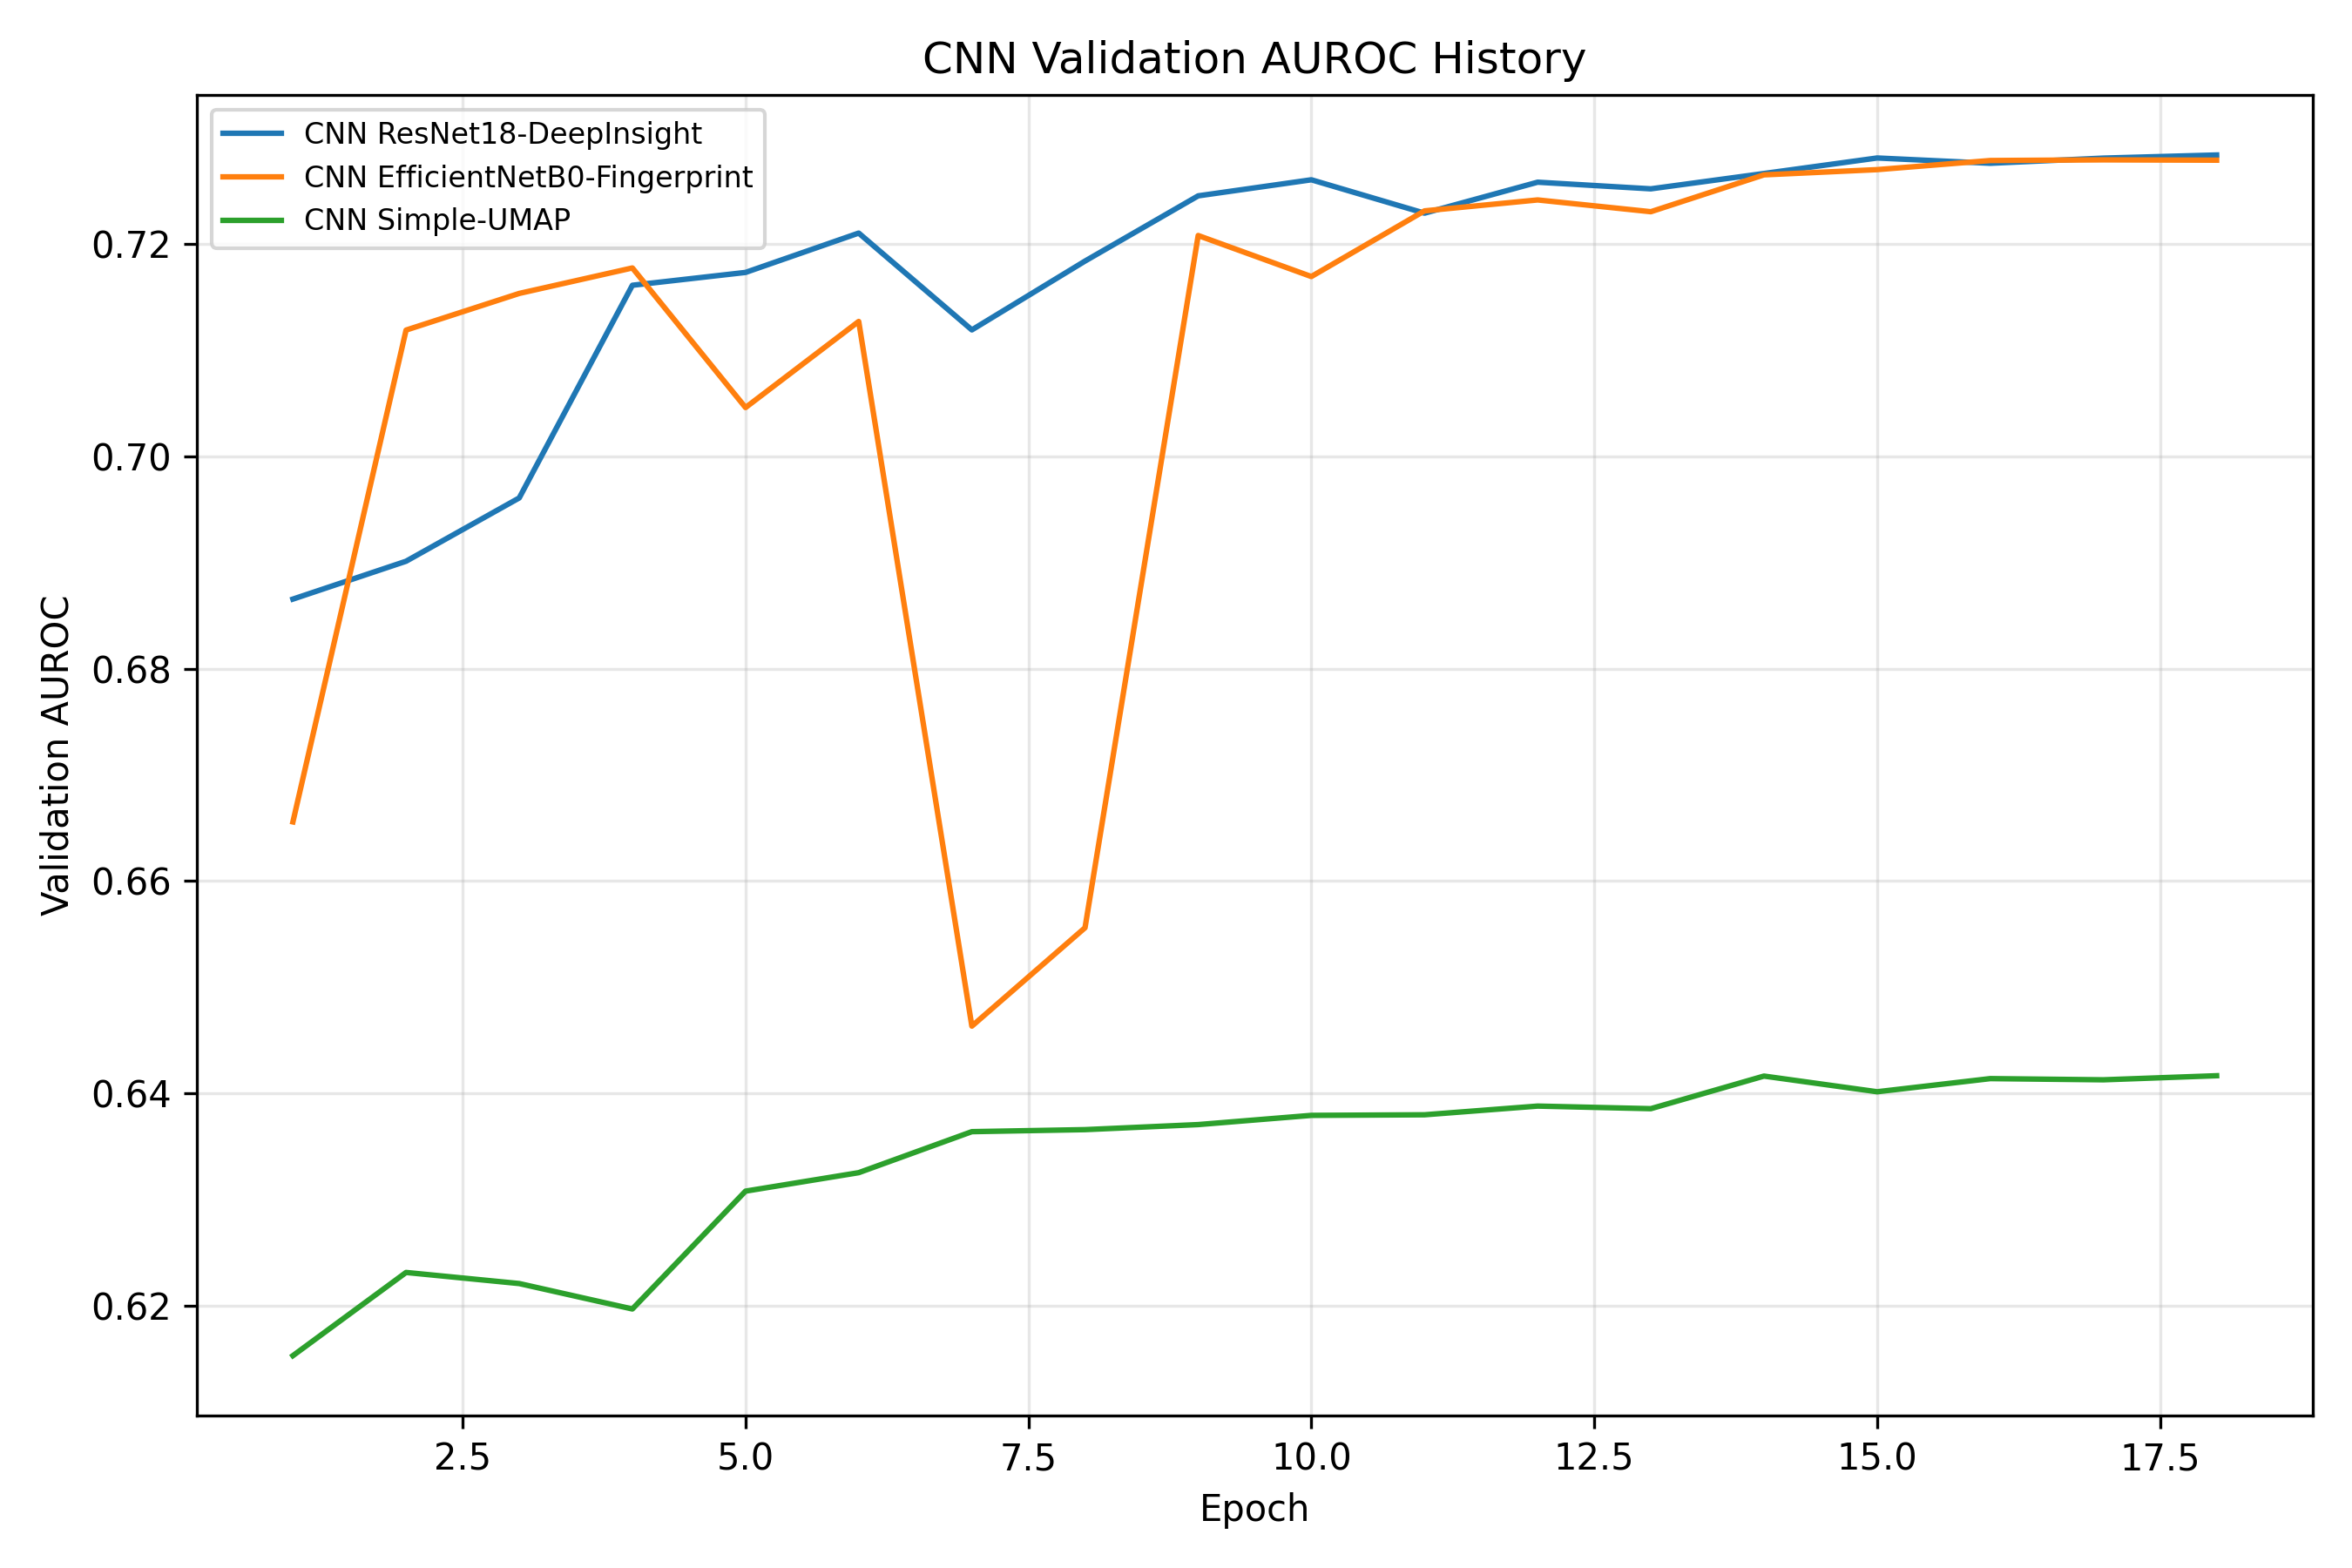

### cnn_efficientnetb0_fingerprint_loss.png

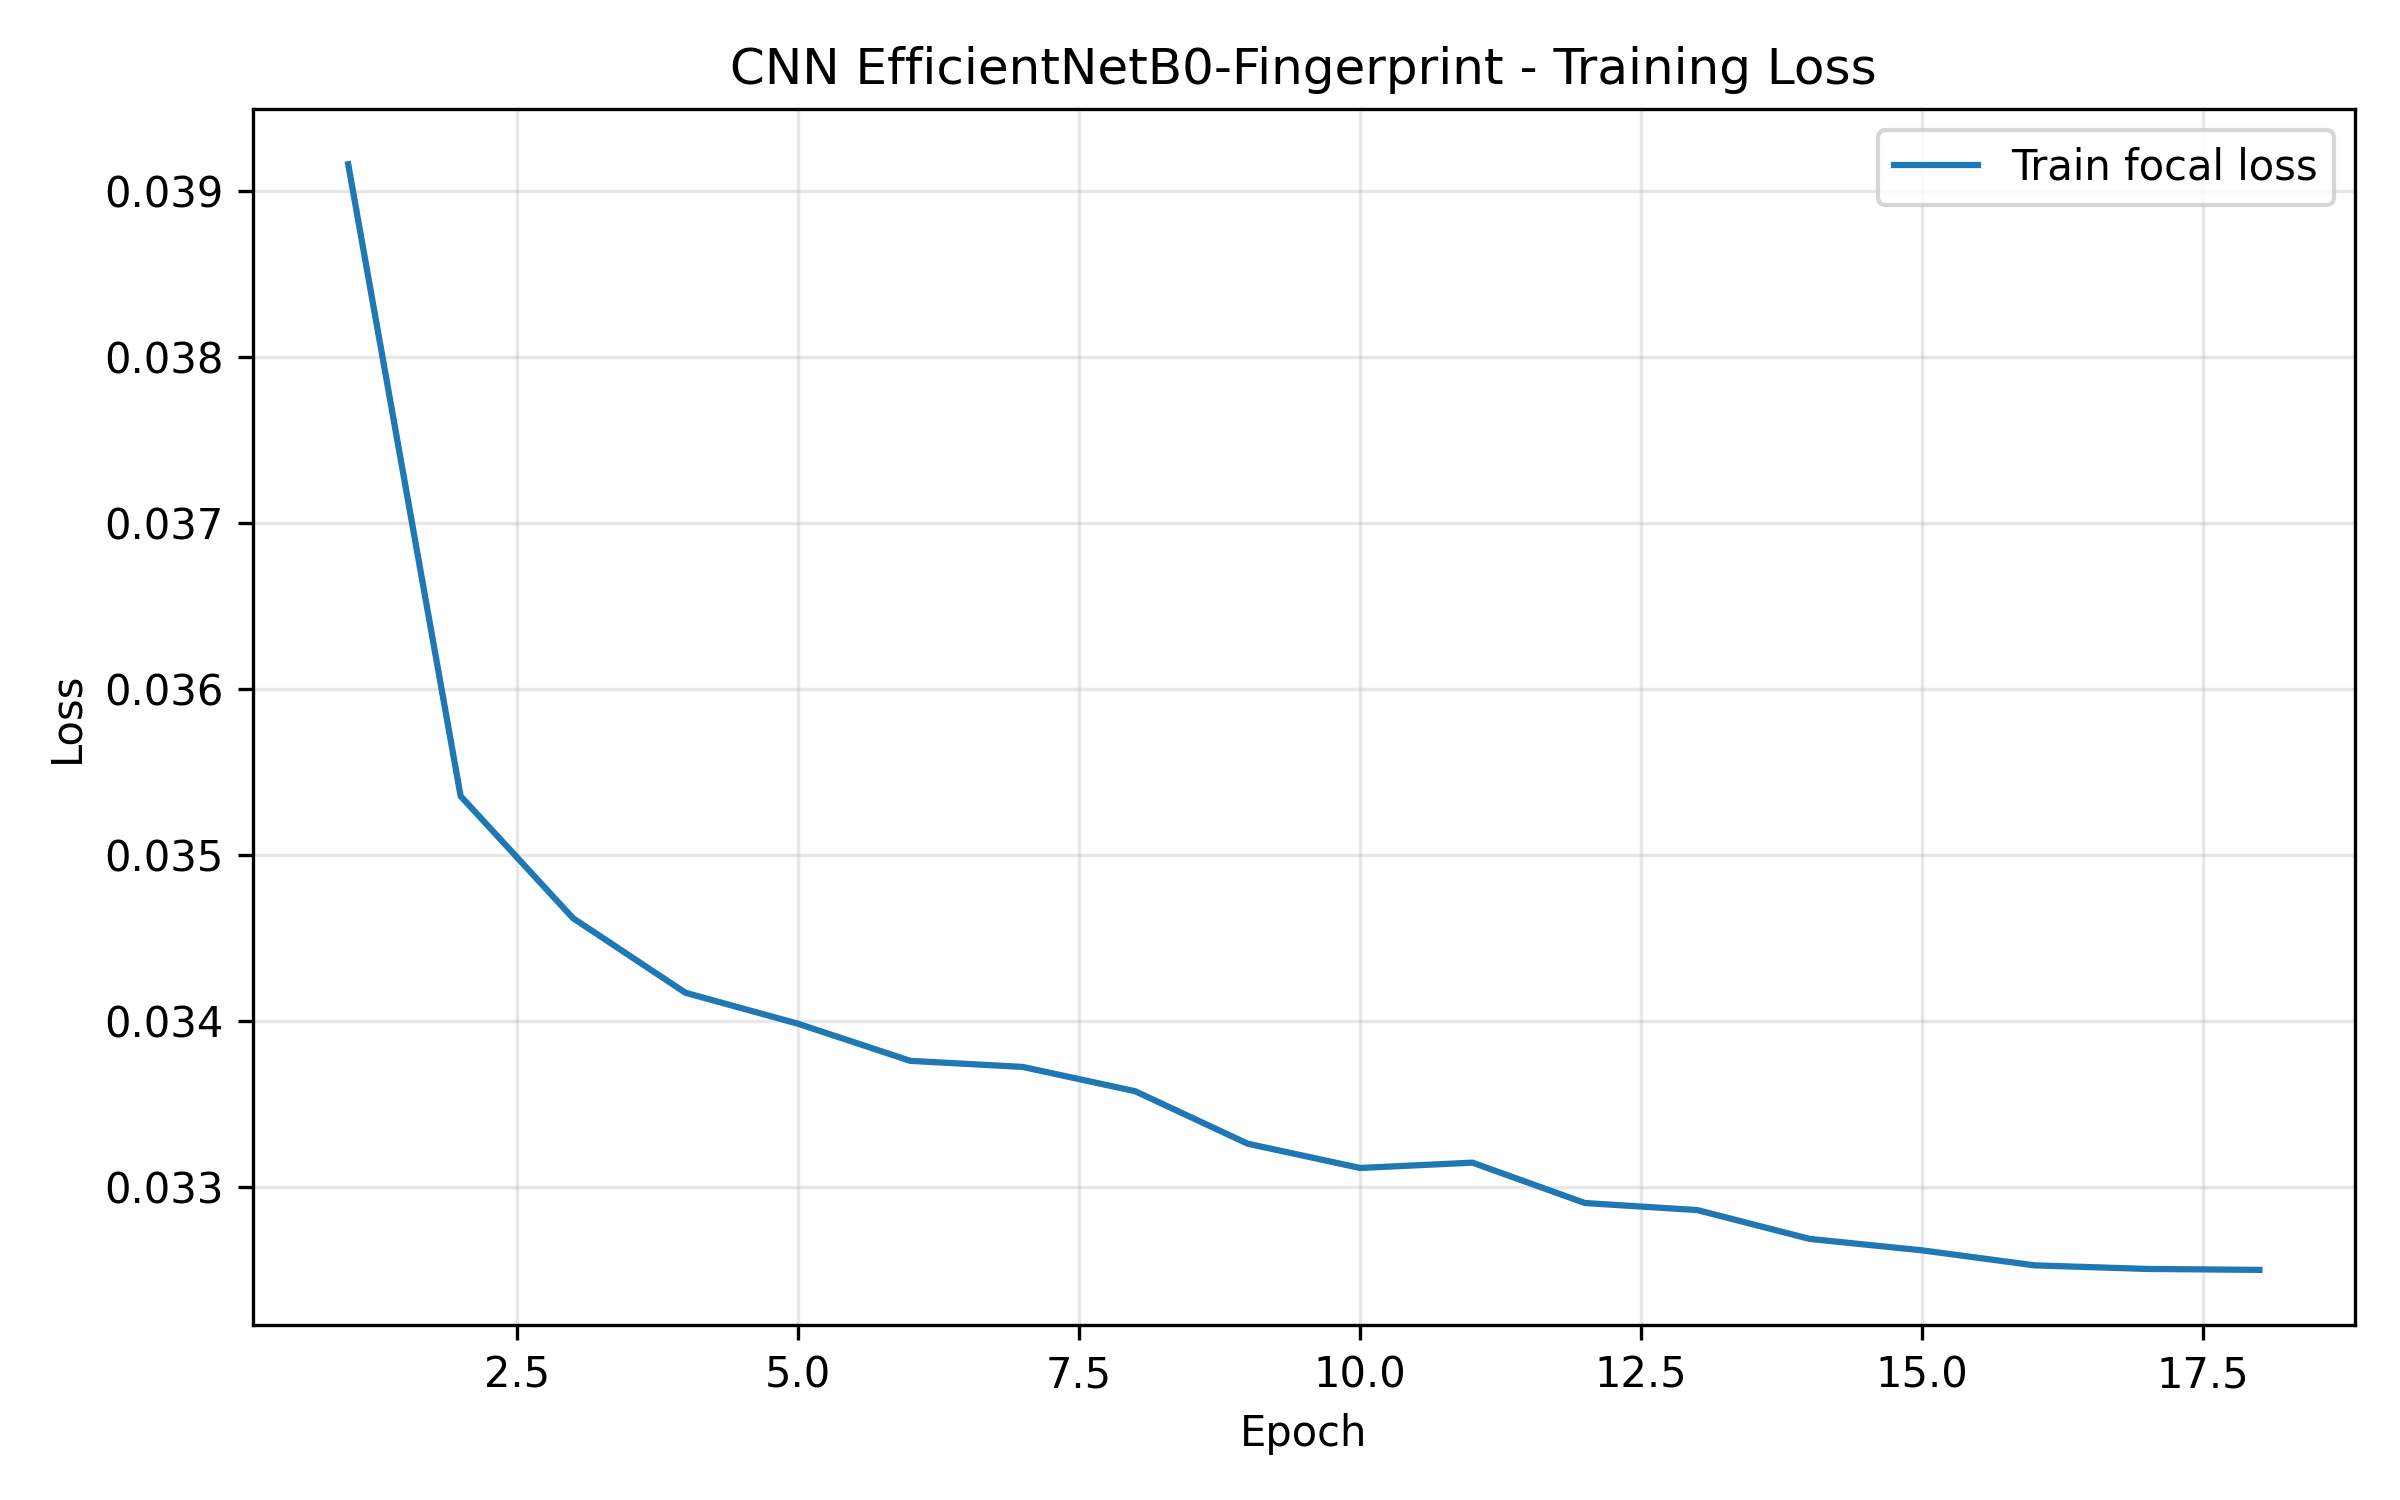

### cnn_resnet18_deepinsight_loss.png

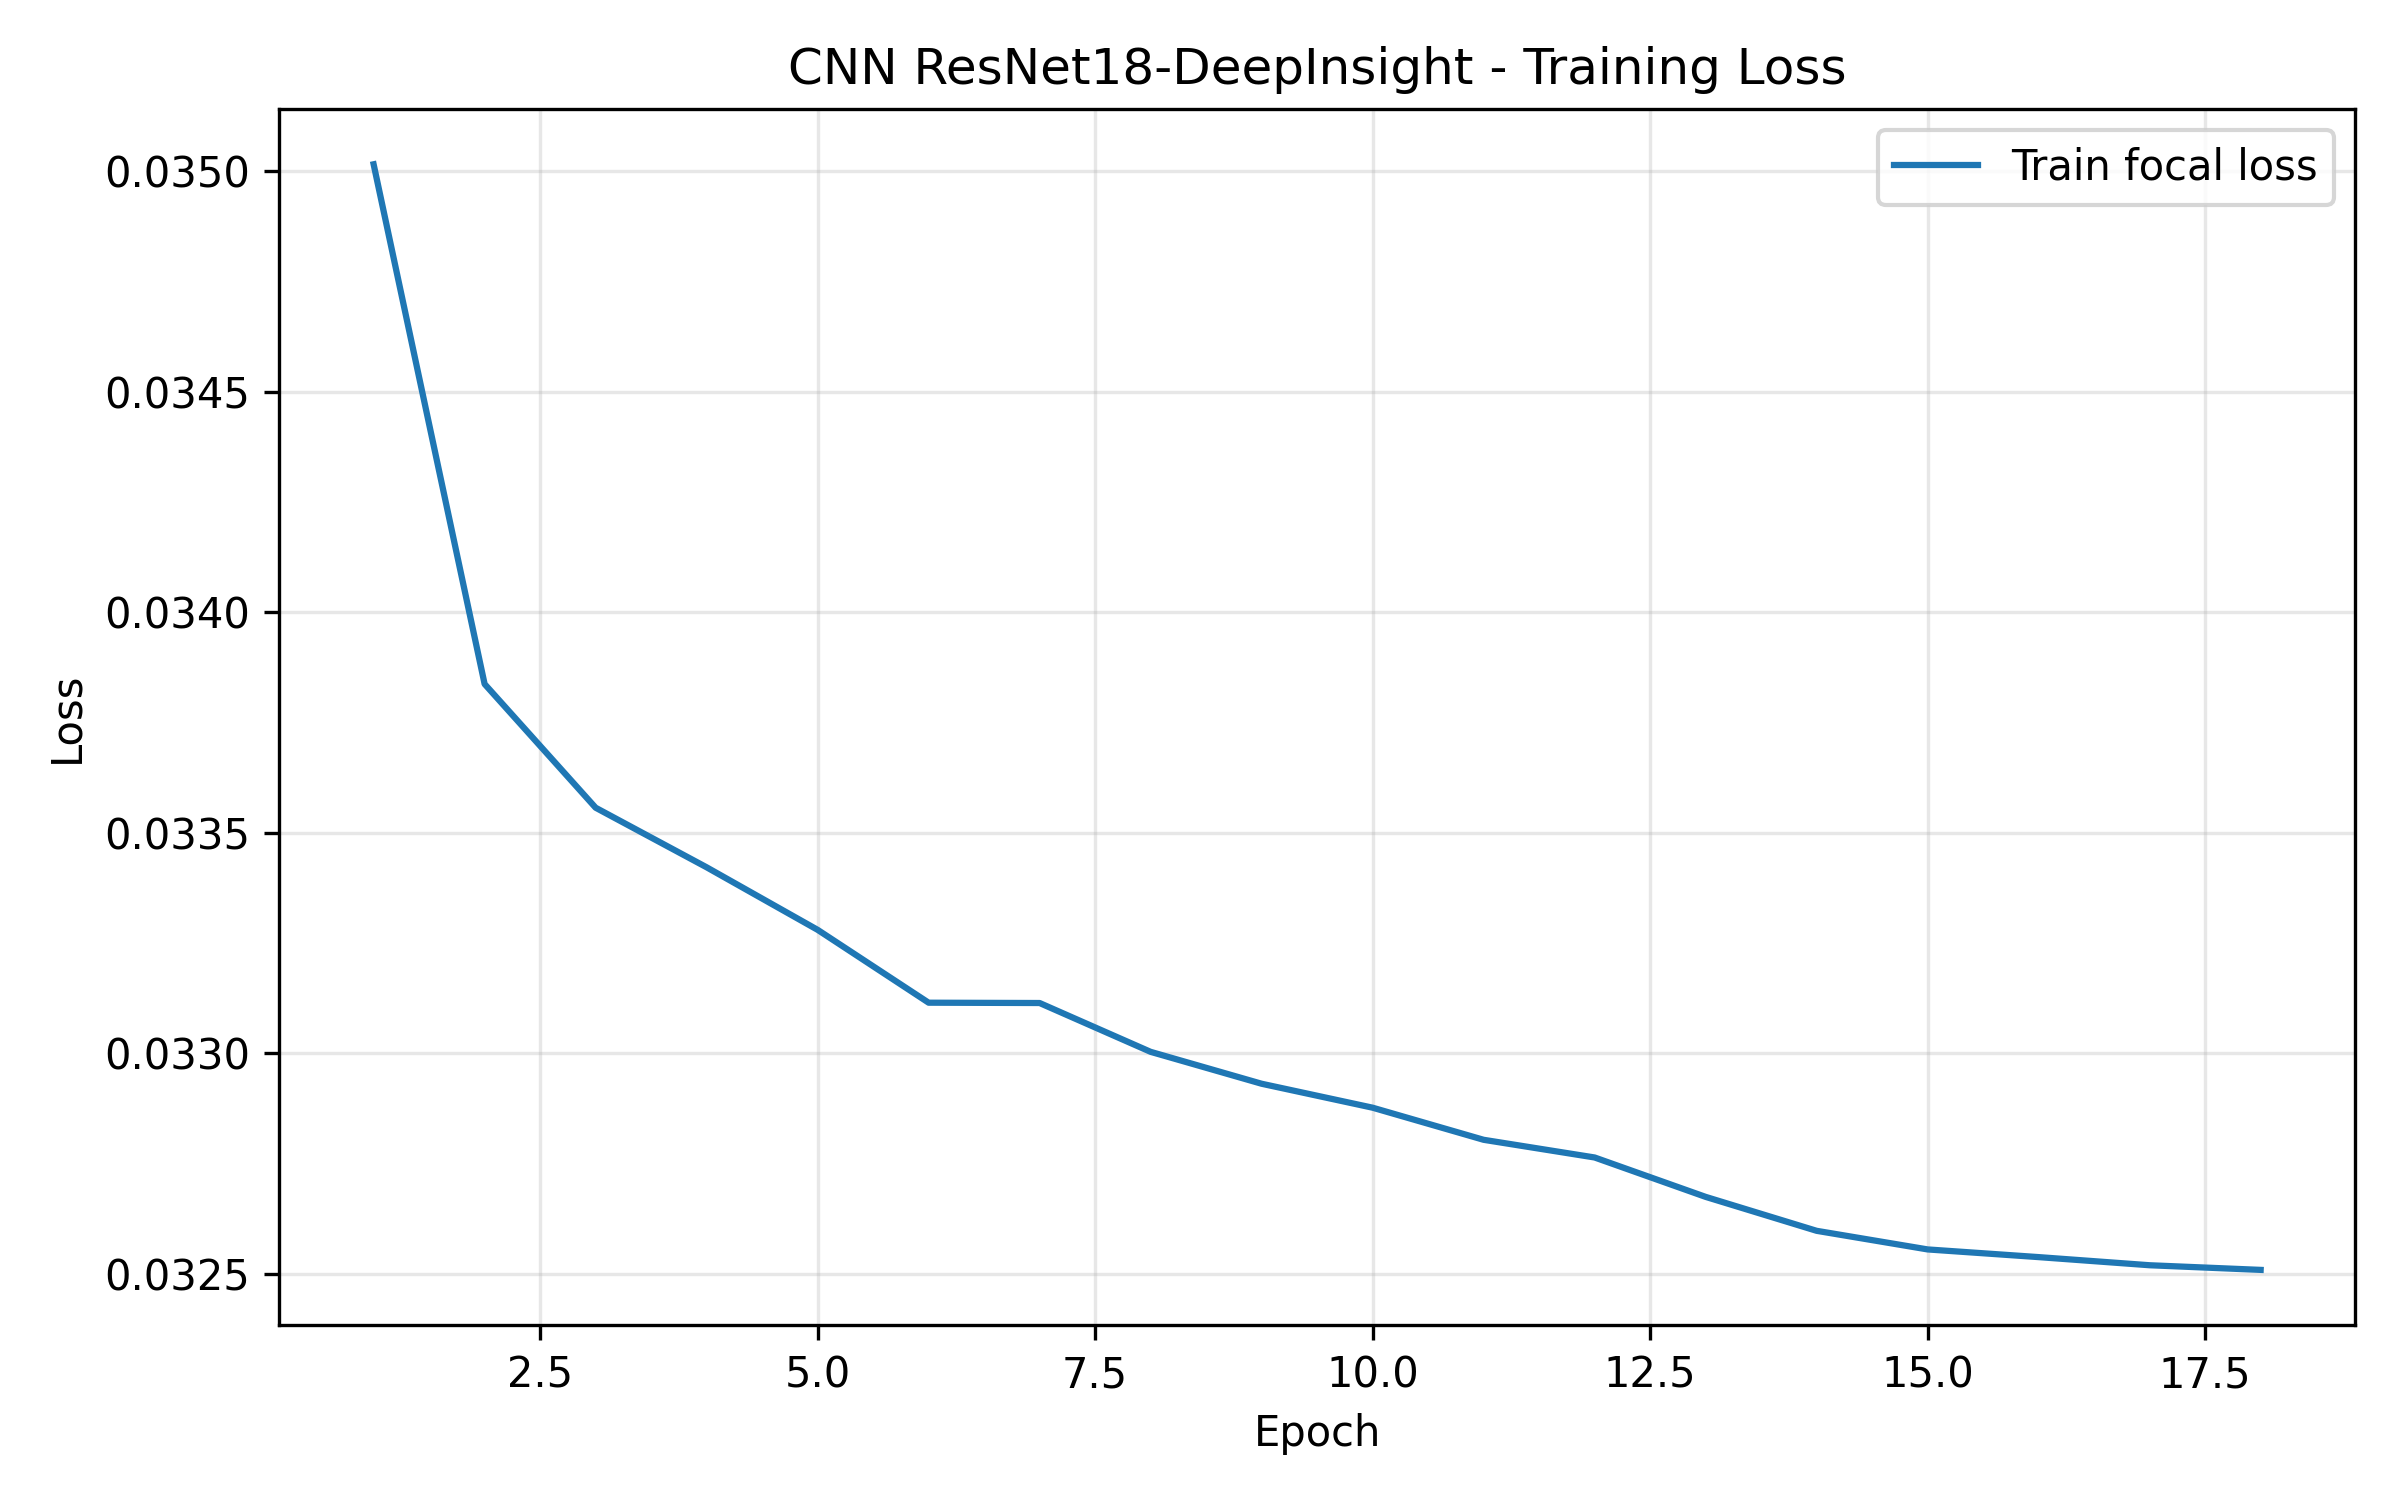

### cnn_simple_umap_loss.png

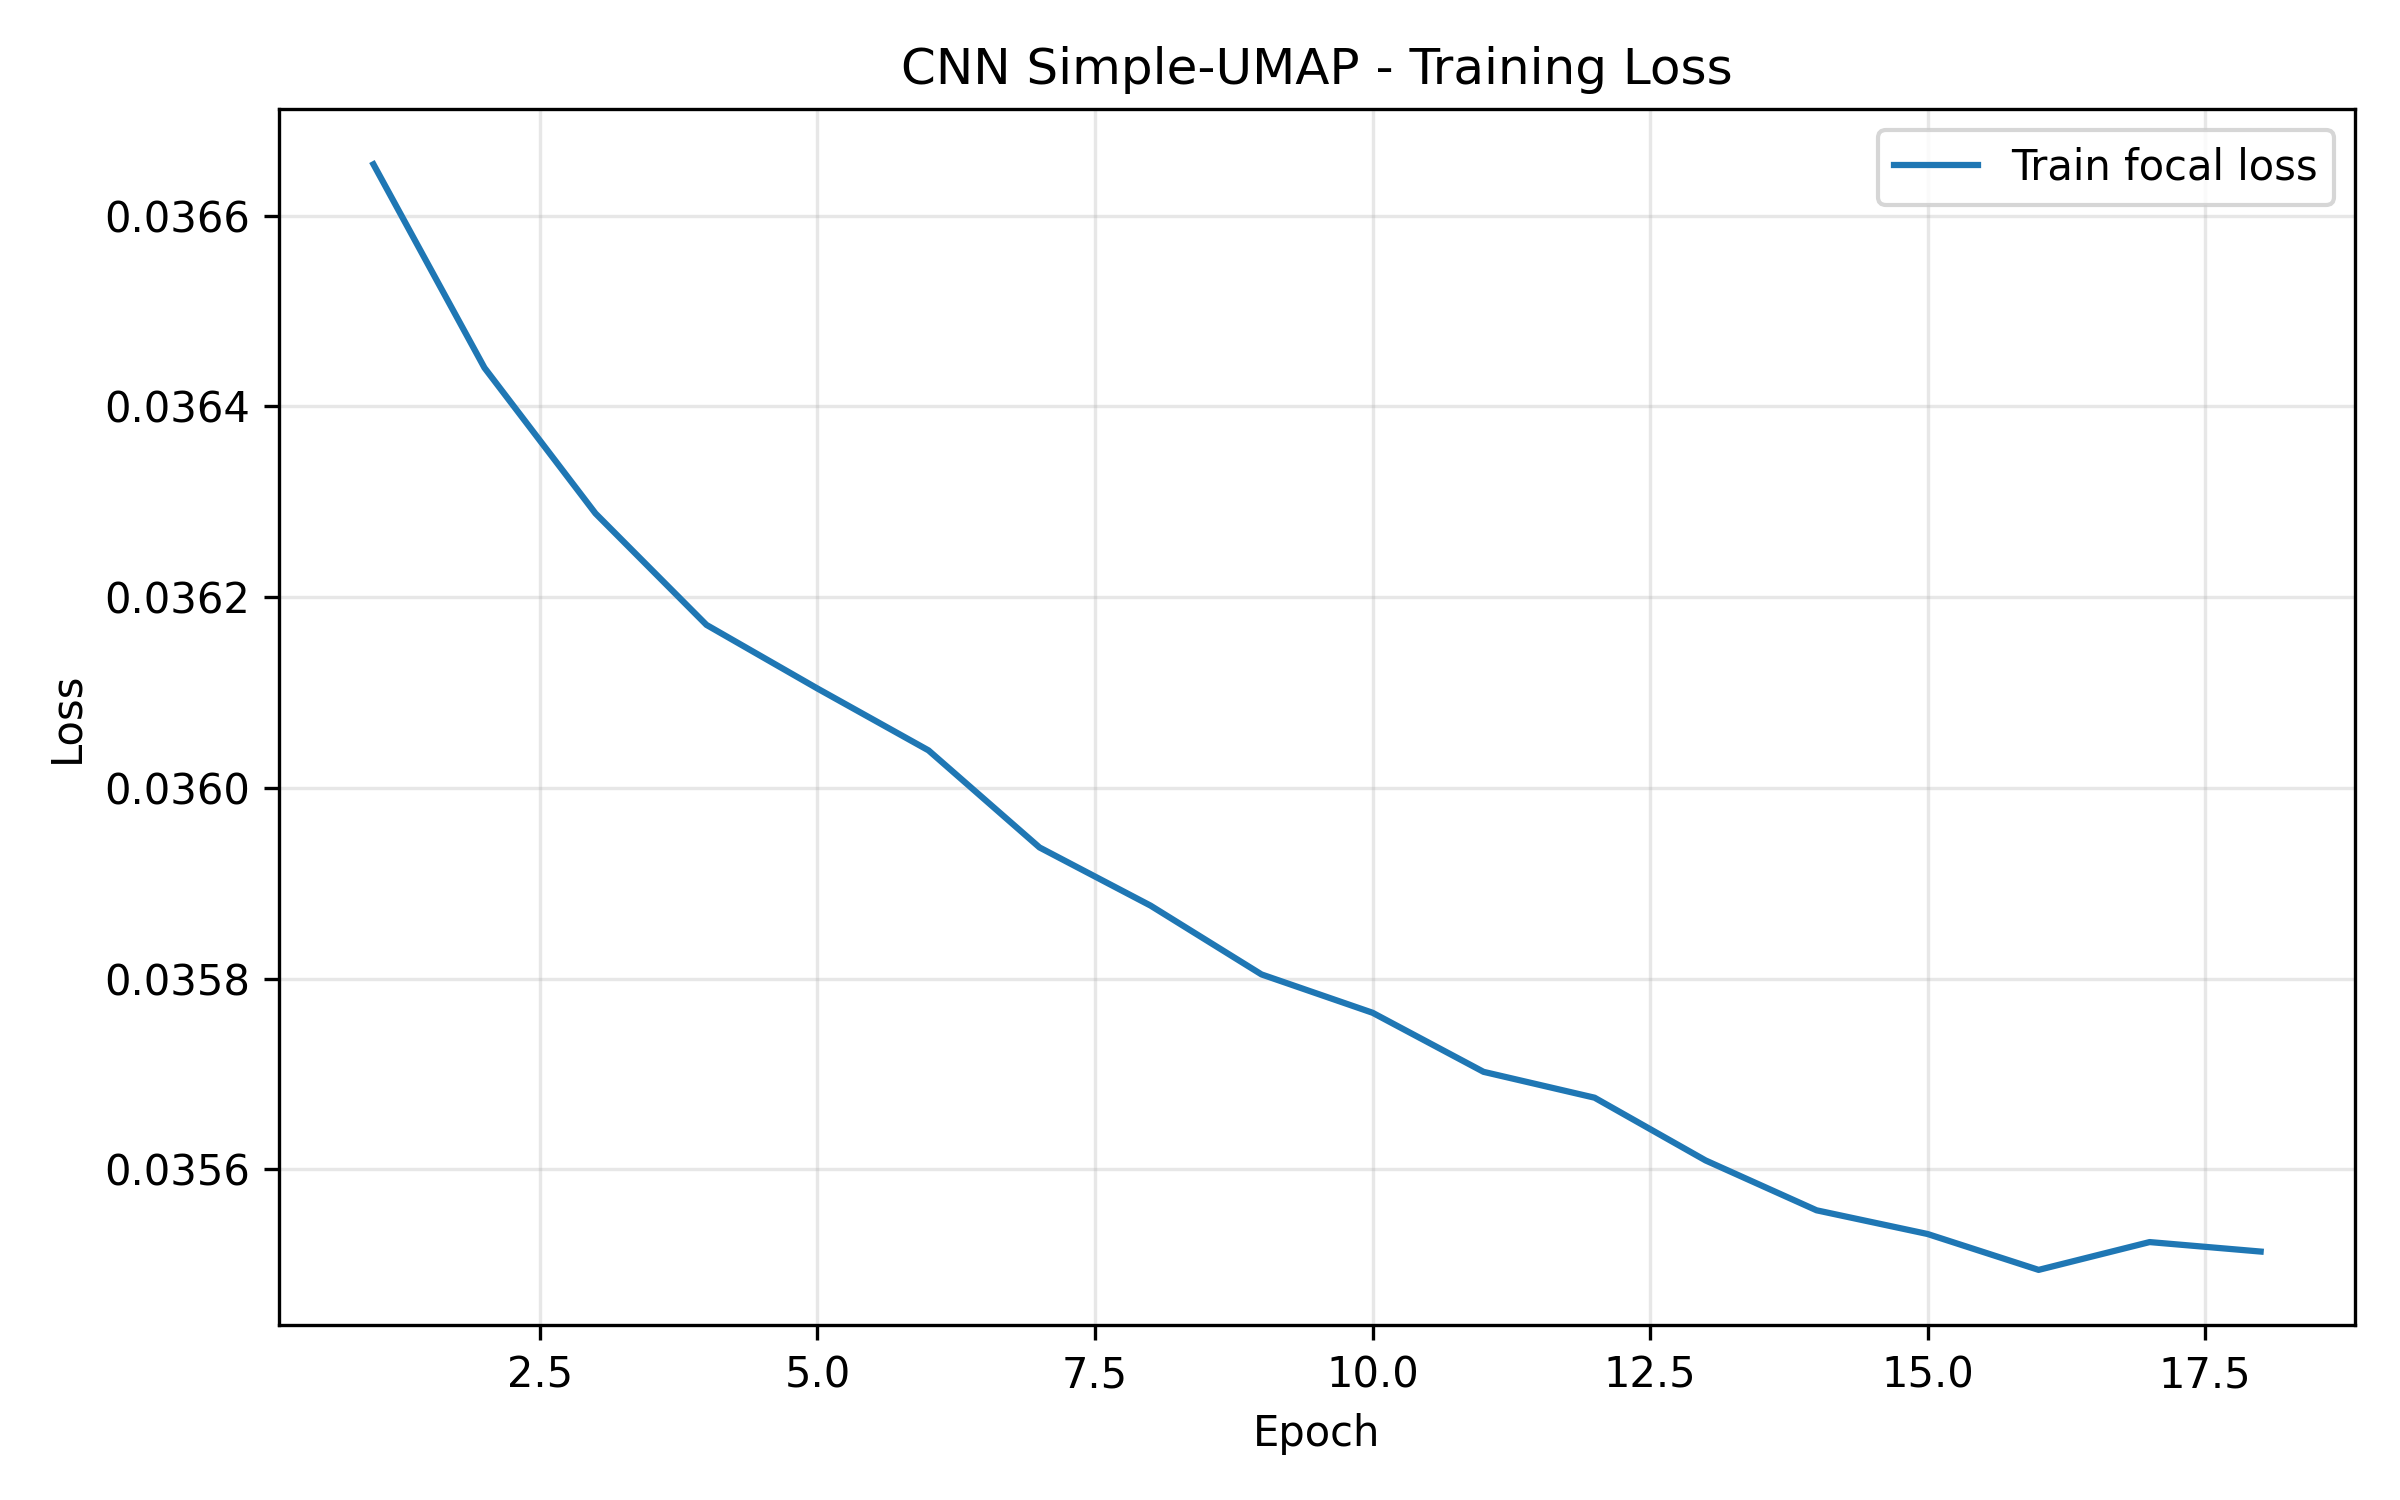

### cnn_efficientnetb0_fingerprint_val_auc.png

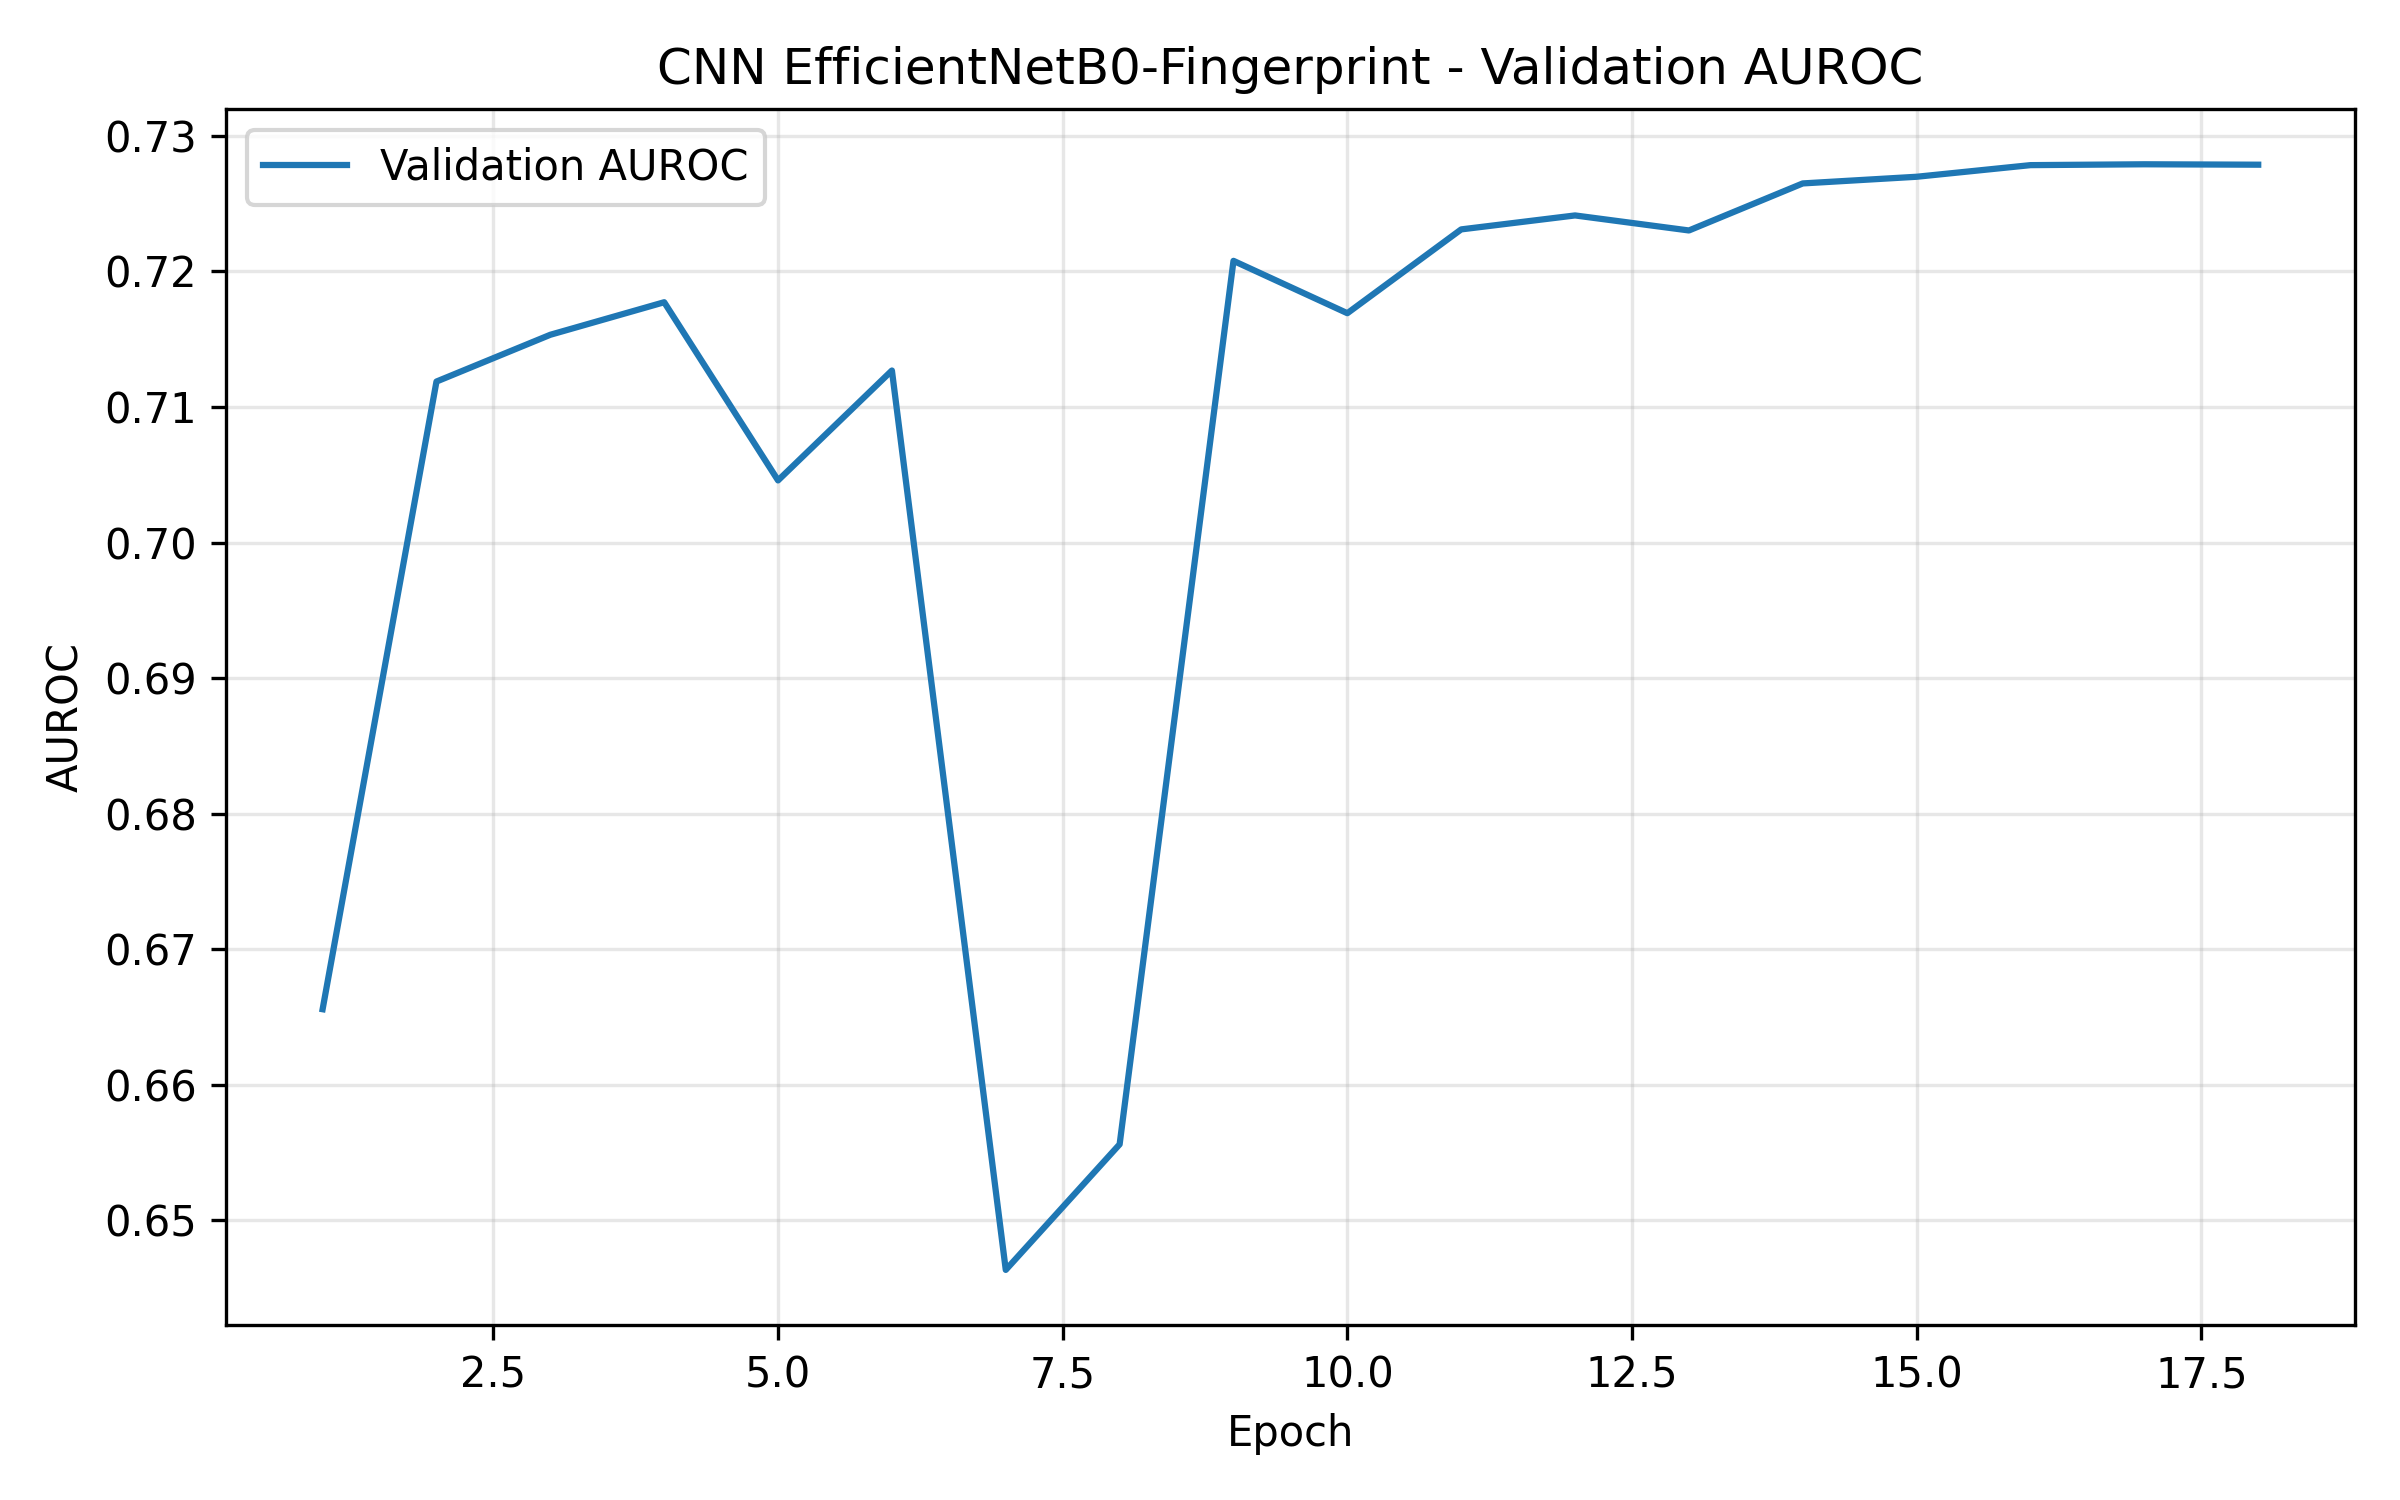

### cnn_resnet18_deepinsight_val_auc.png

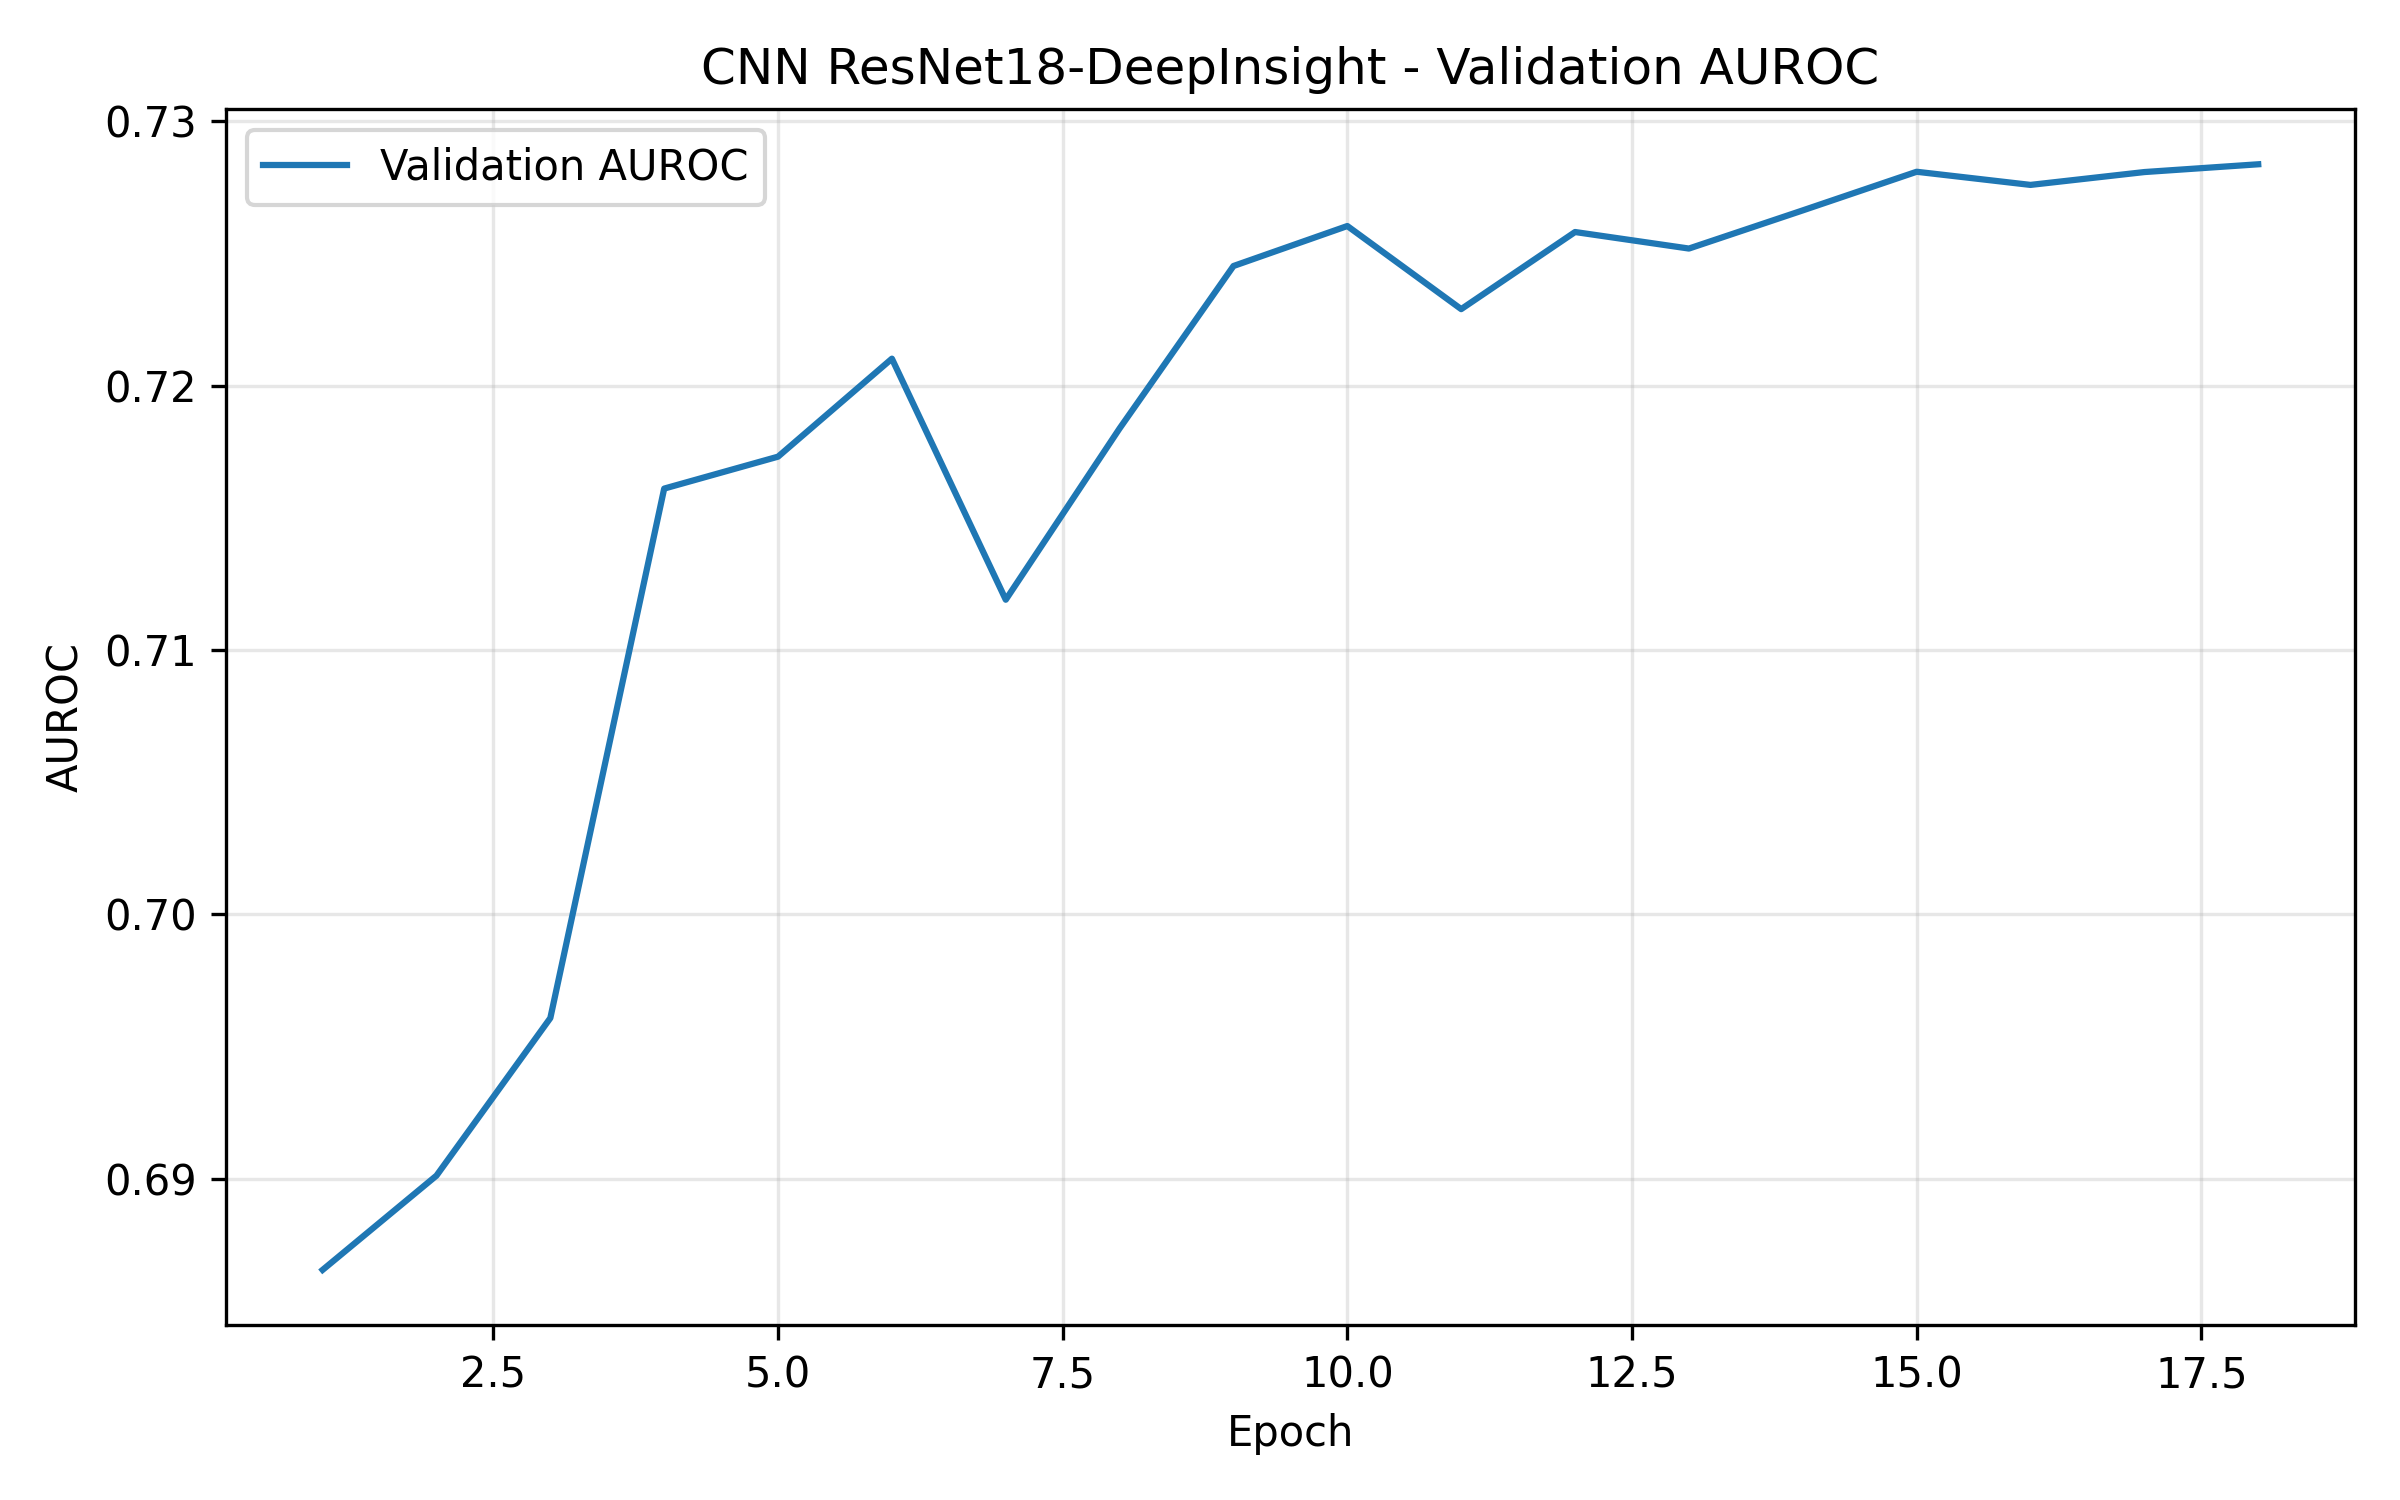

### cnn_simple_umap_val_auc.png

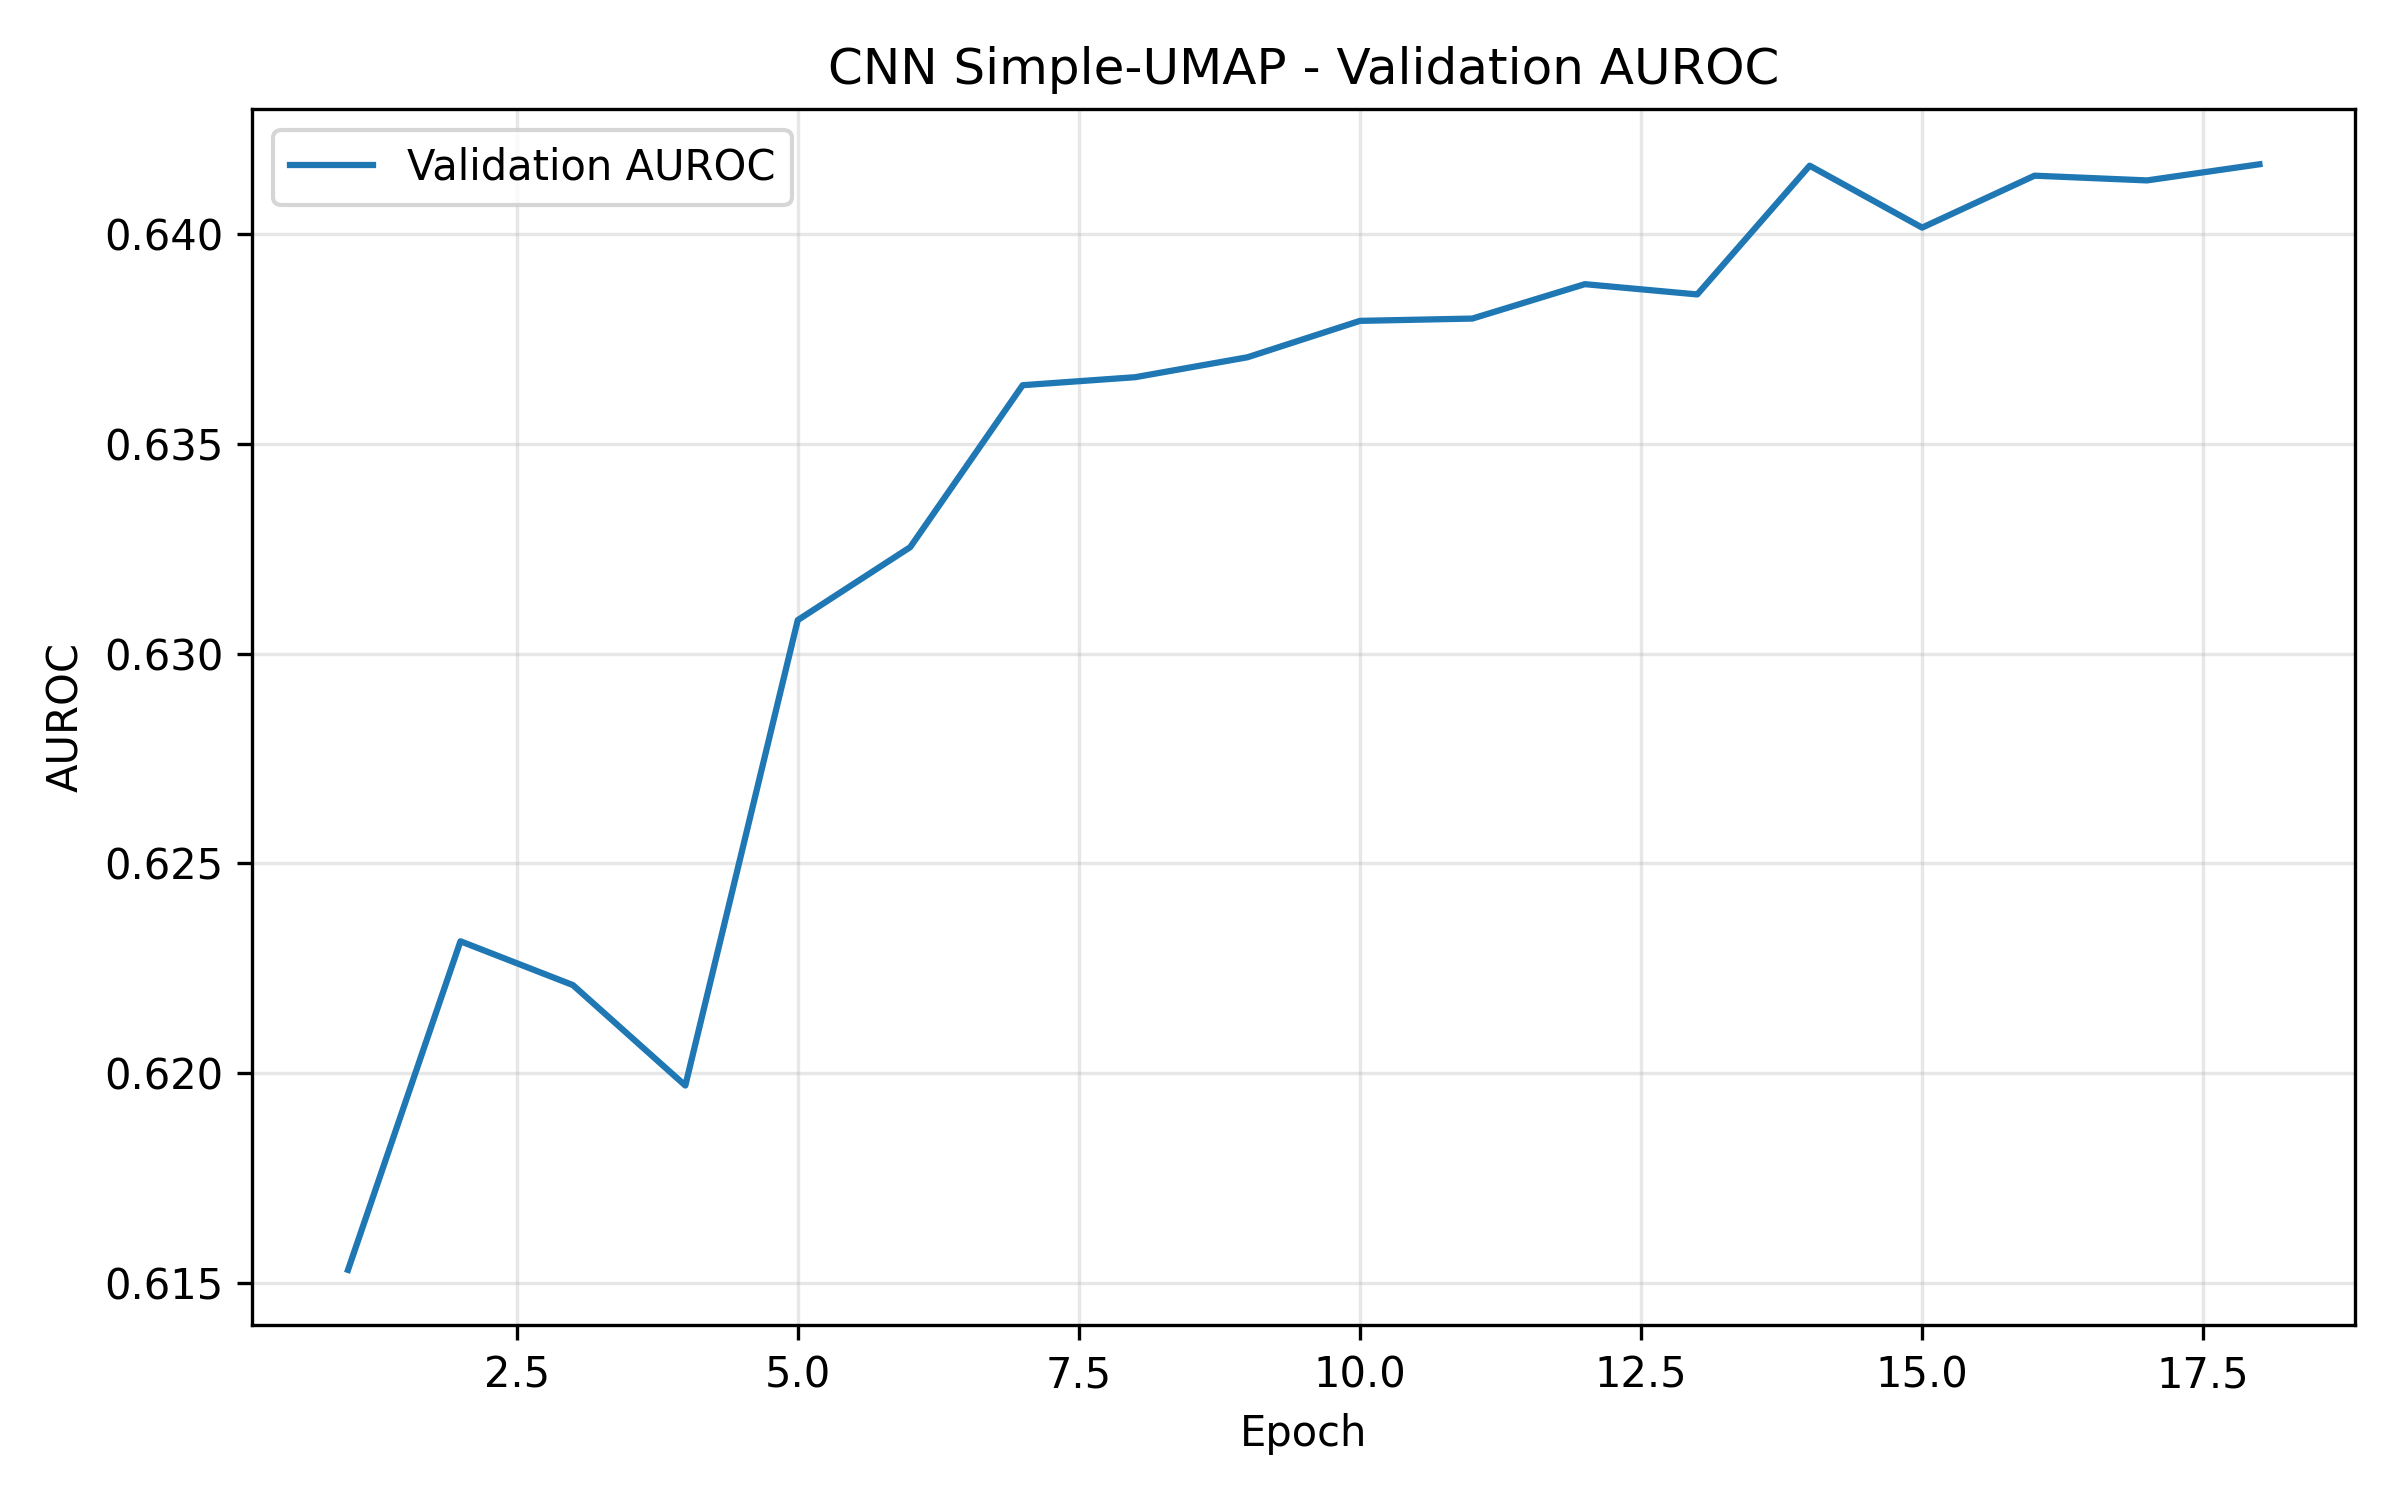

### Forest Plot — AUROC with 95% CI

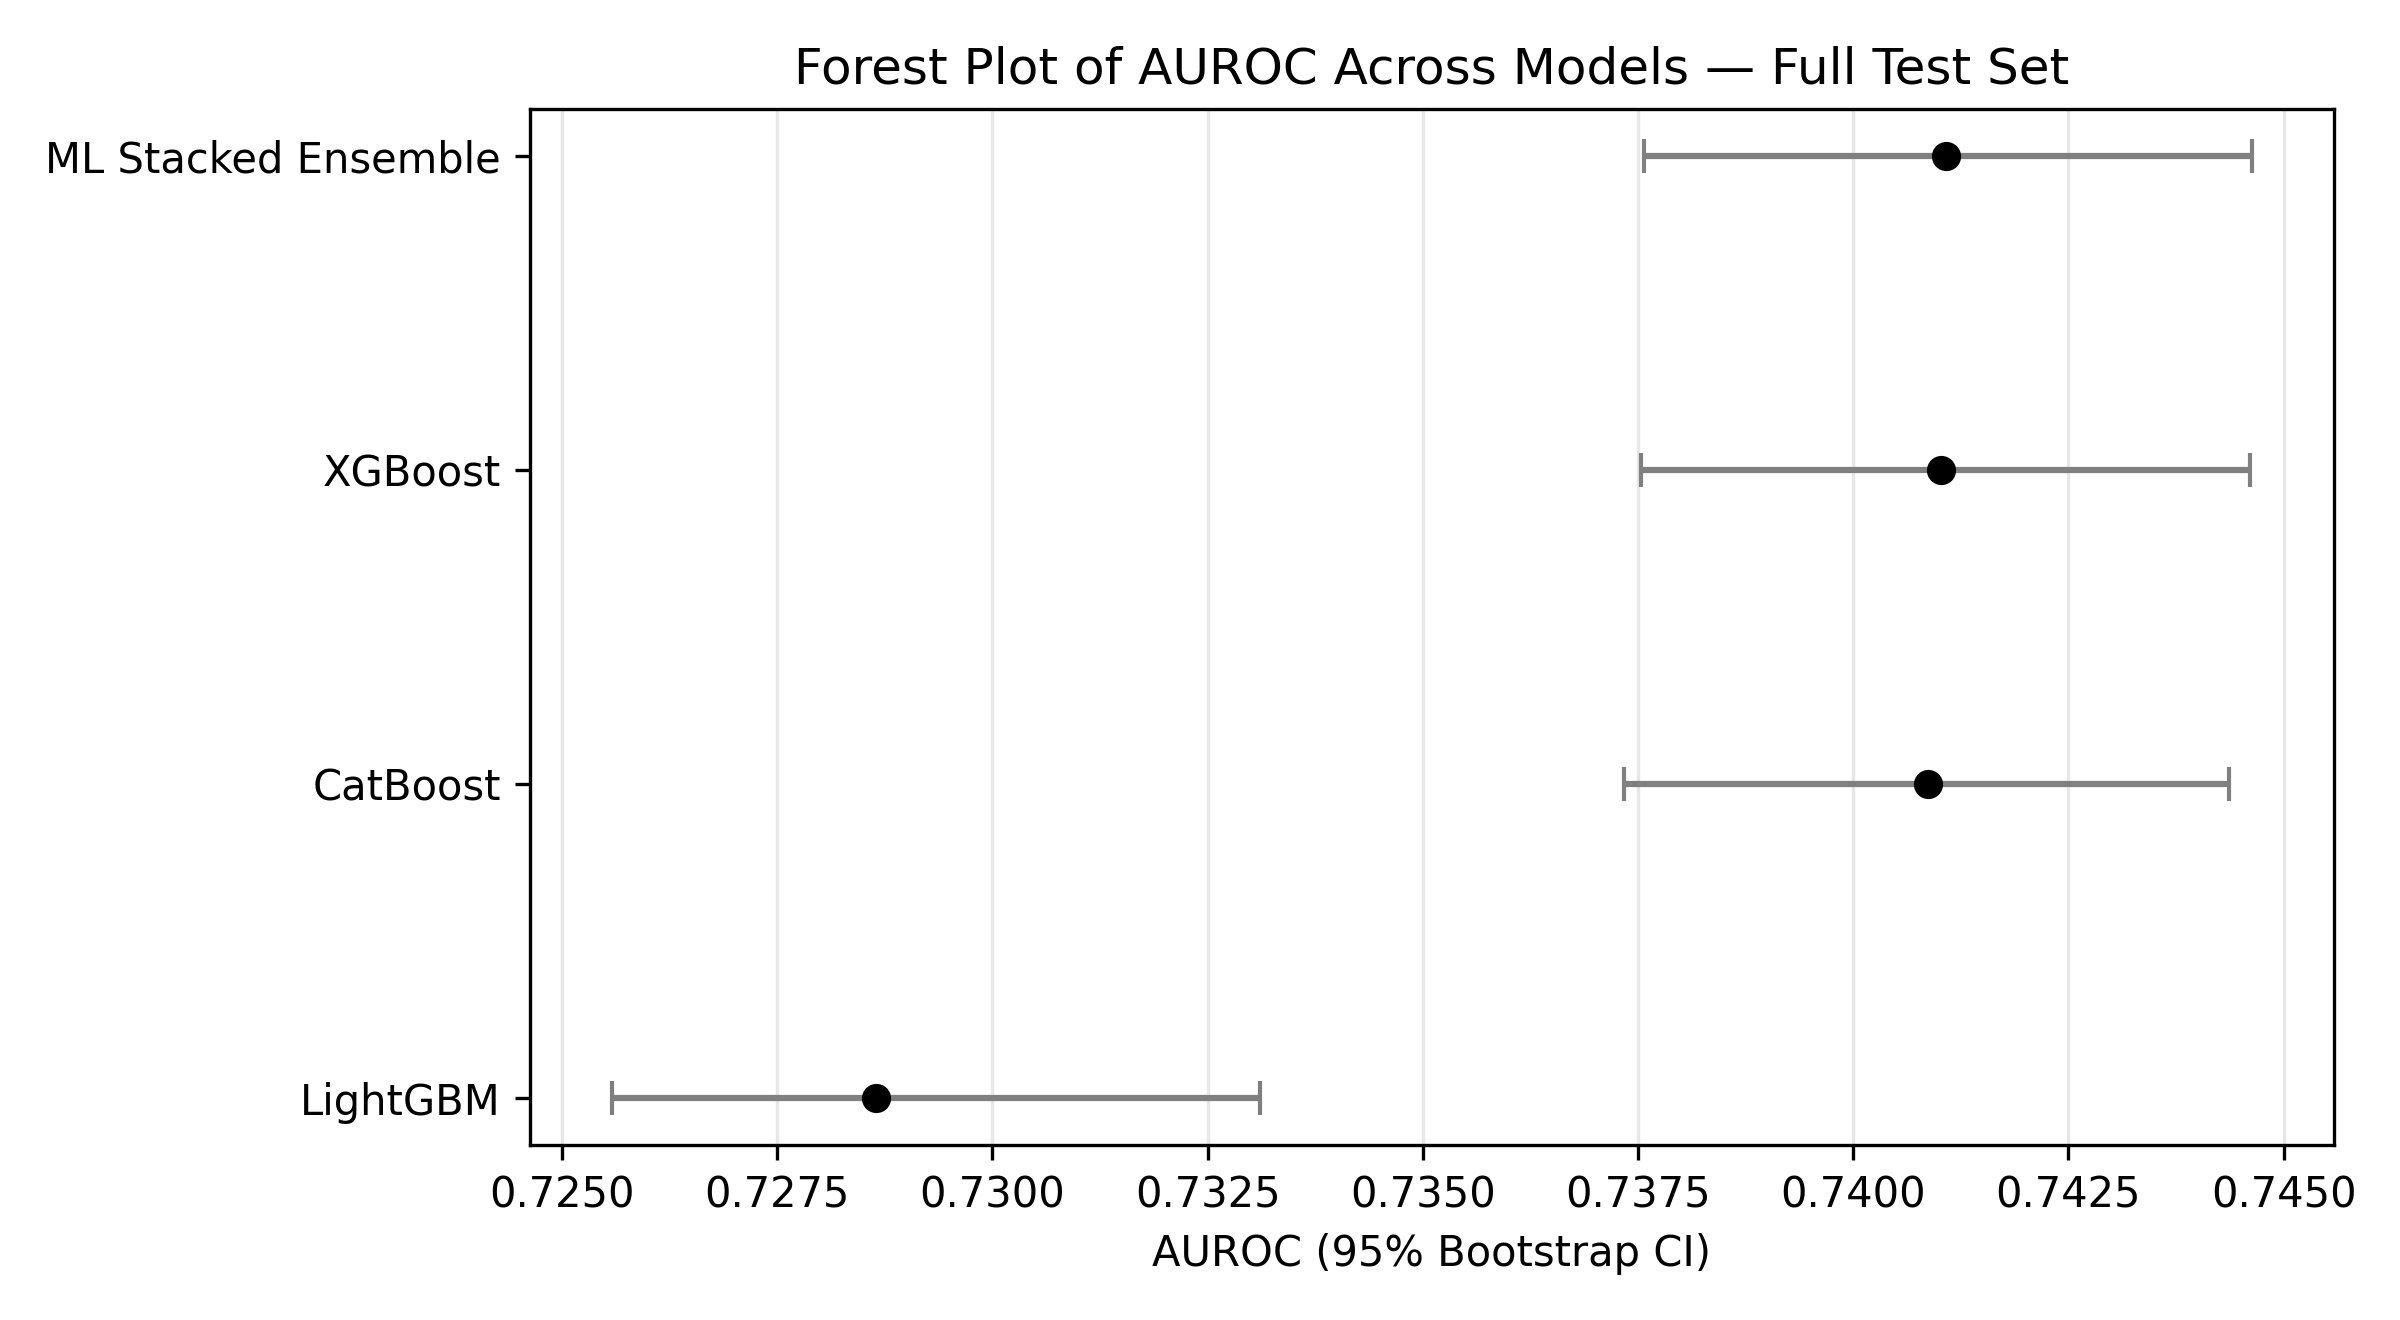

### Confusion Matrices — Full Test Set

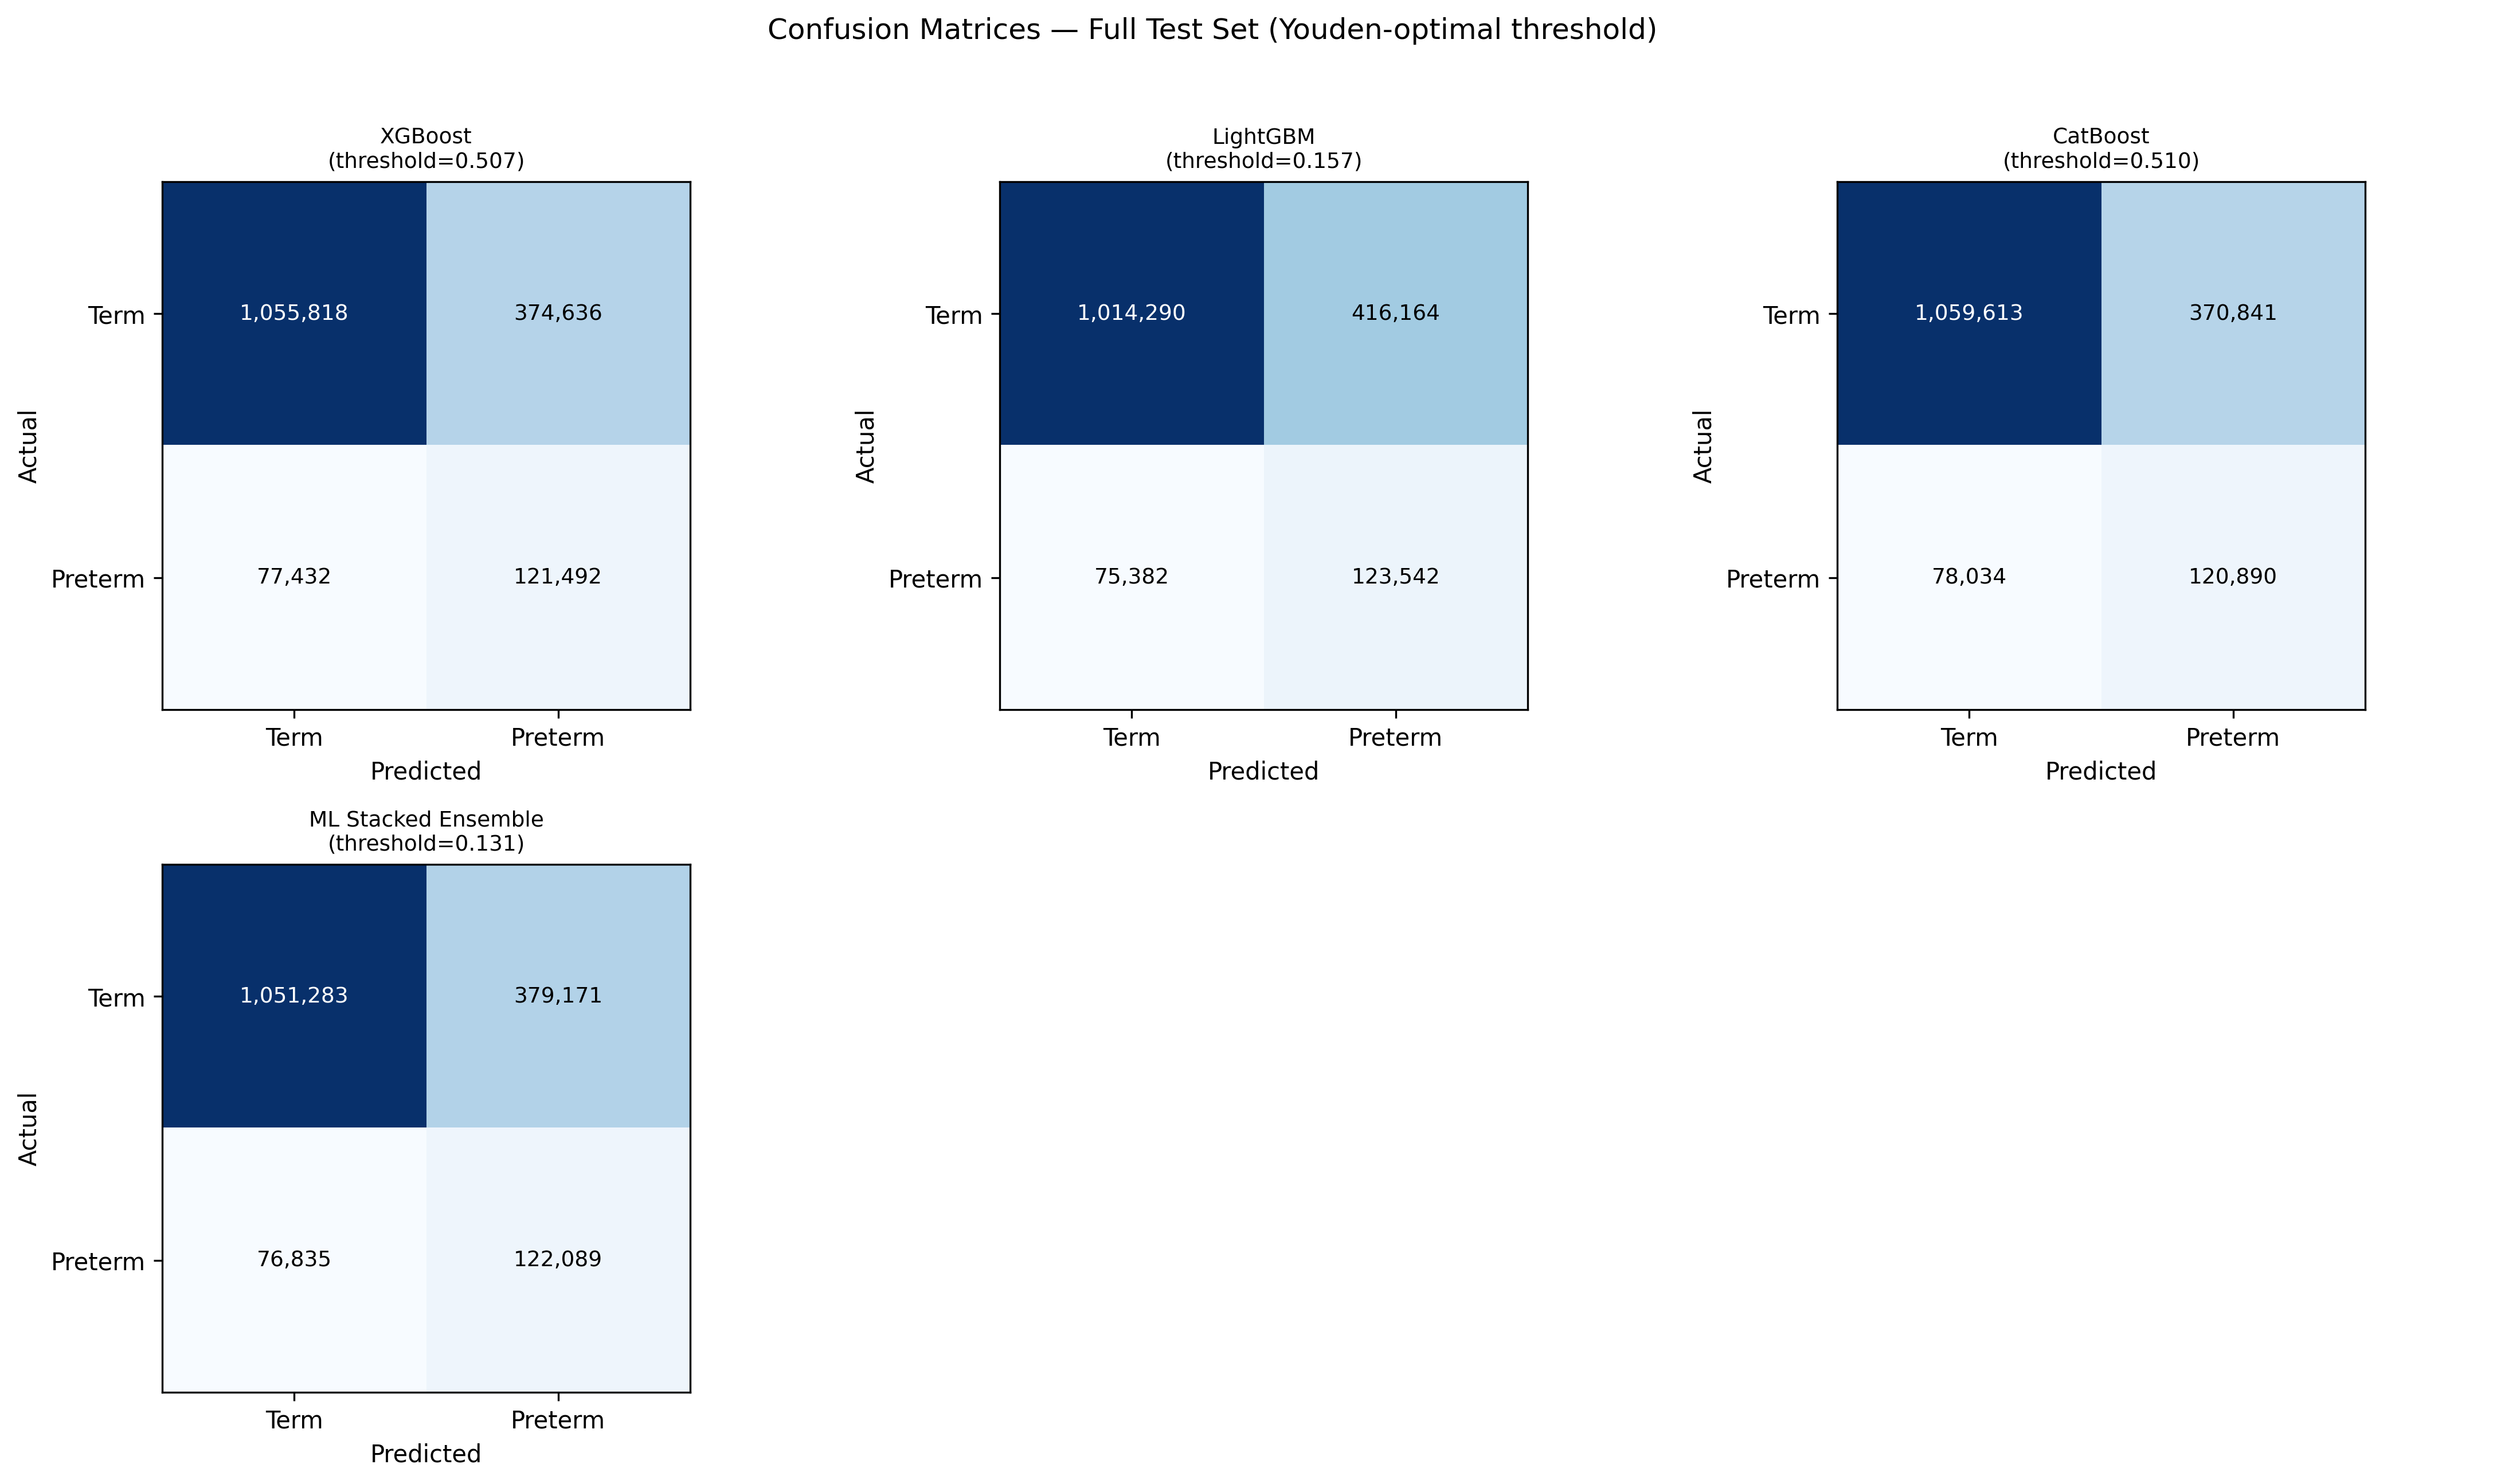

### Sensitivity / Specificity vs Threshold

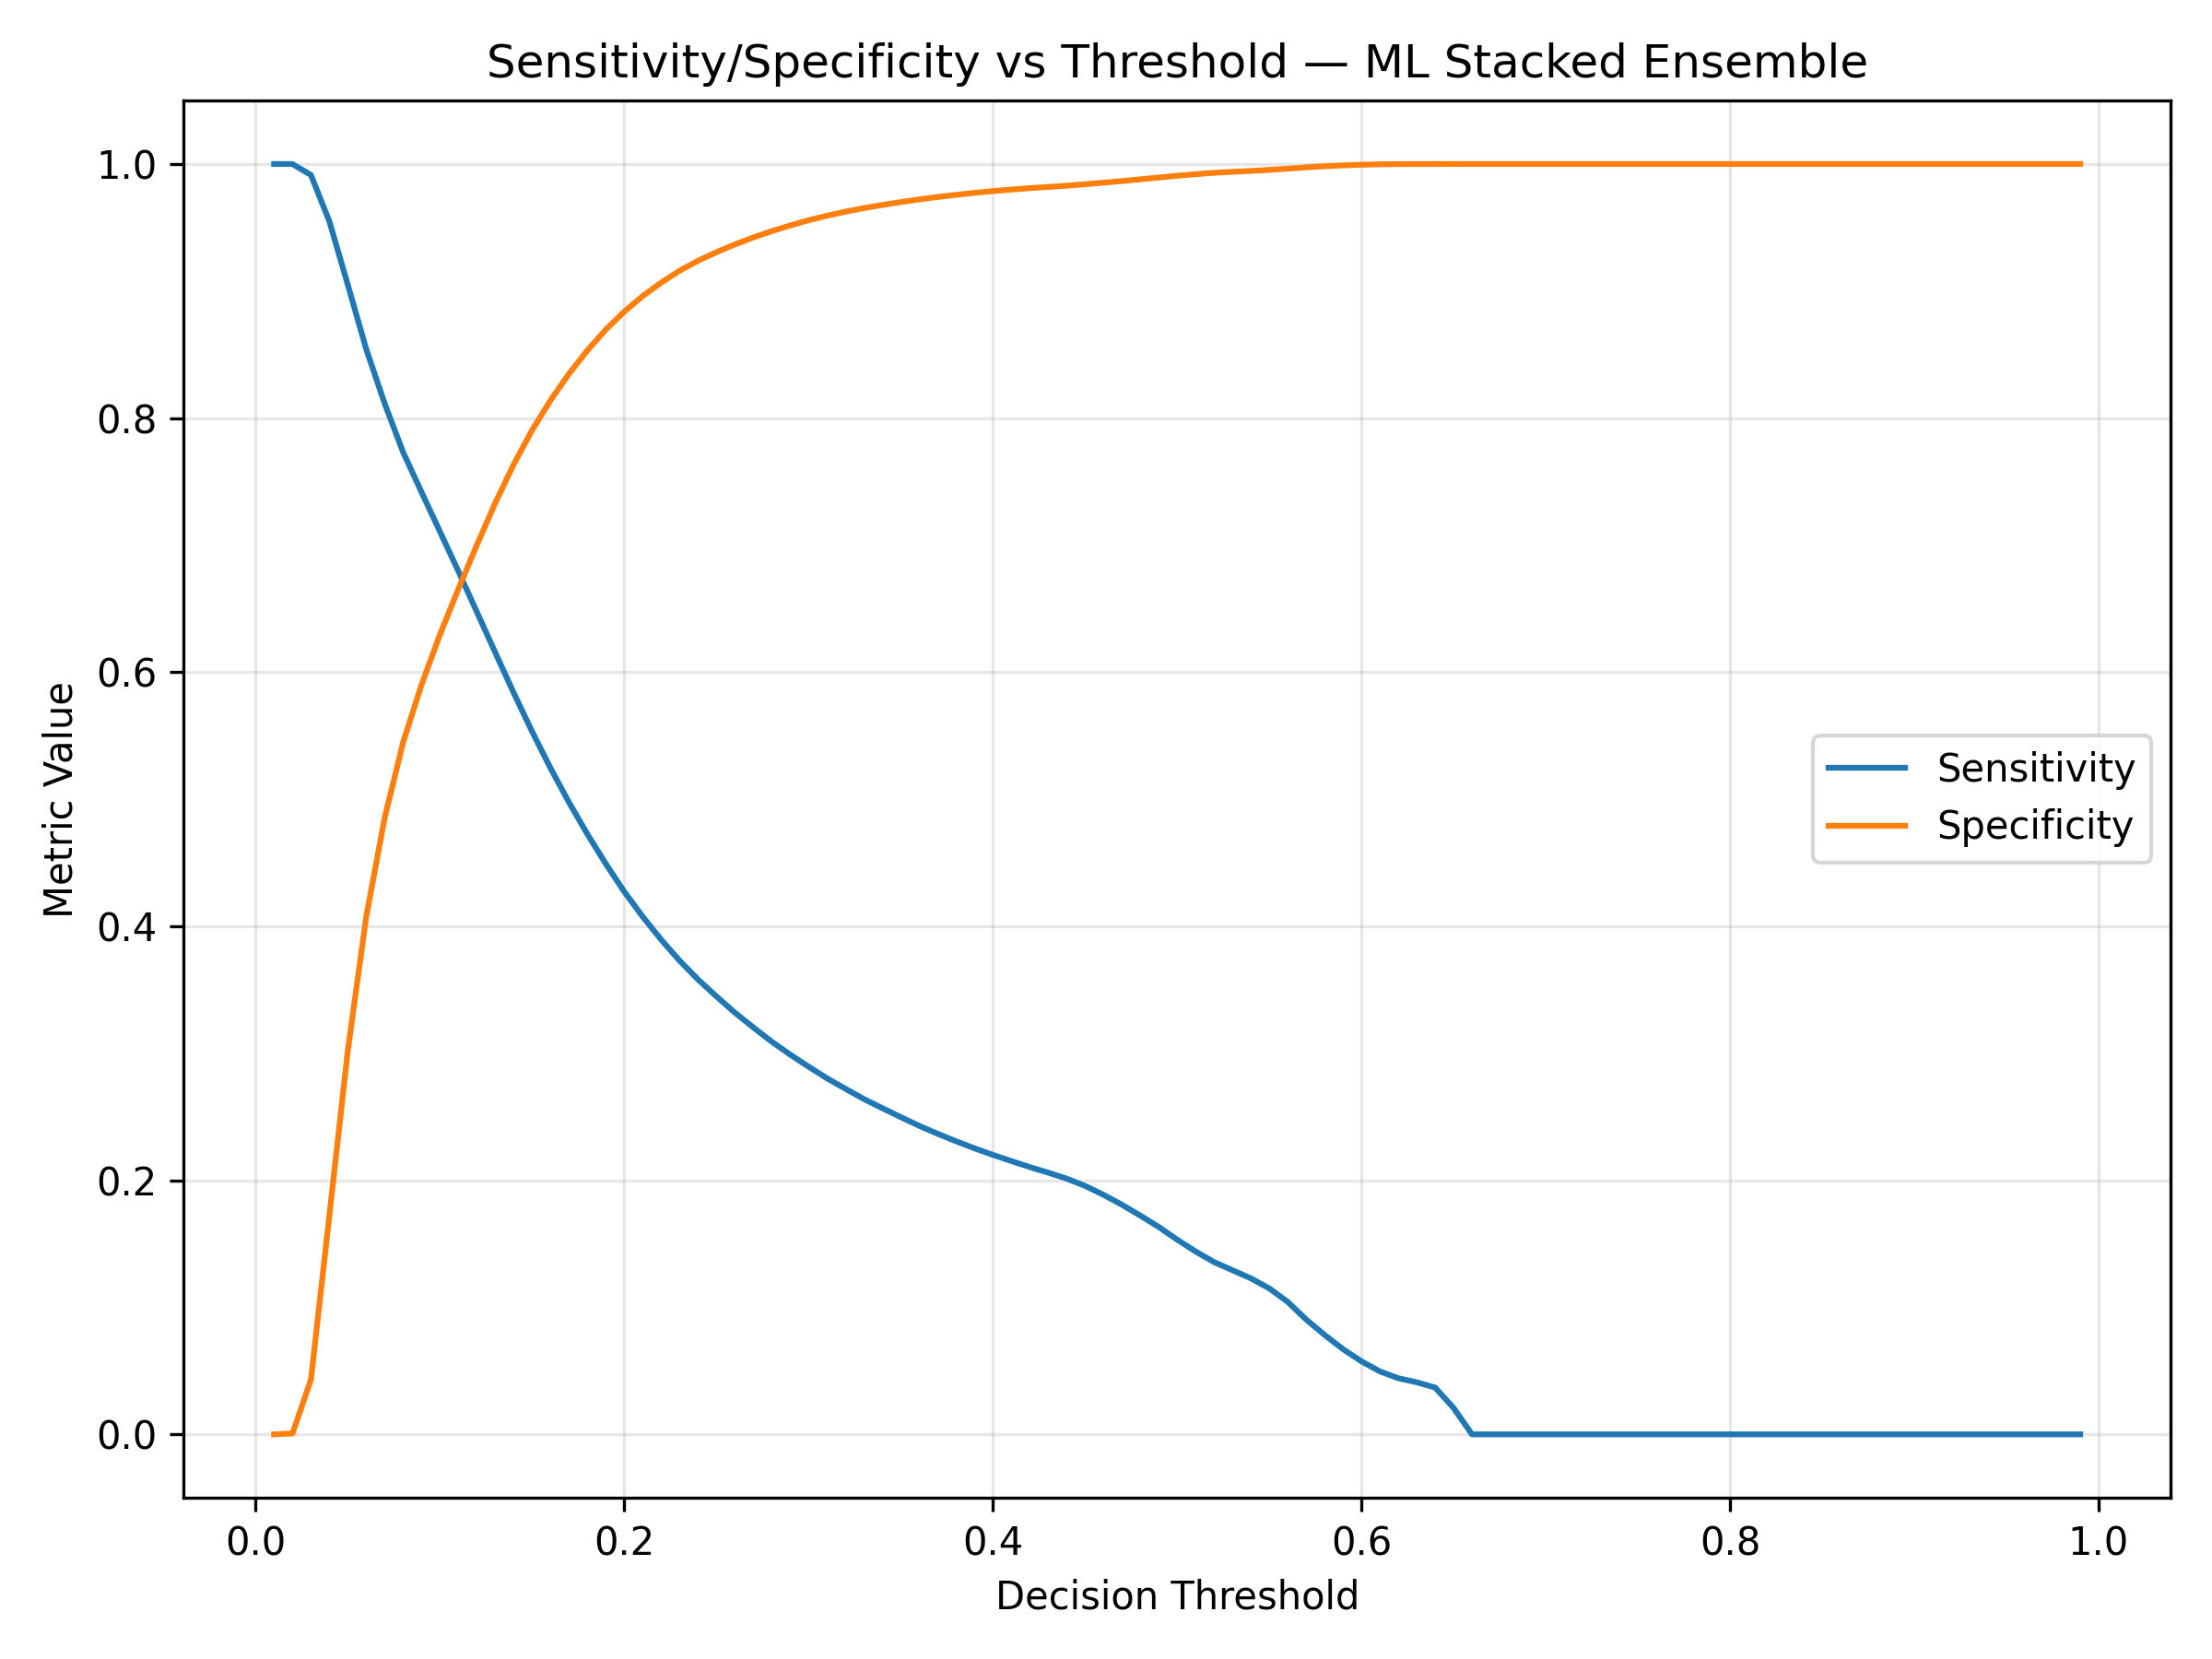

### Predicted Probability Distribution by Class

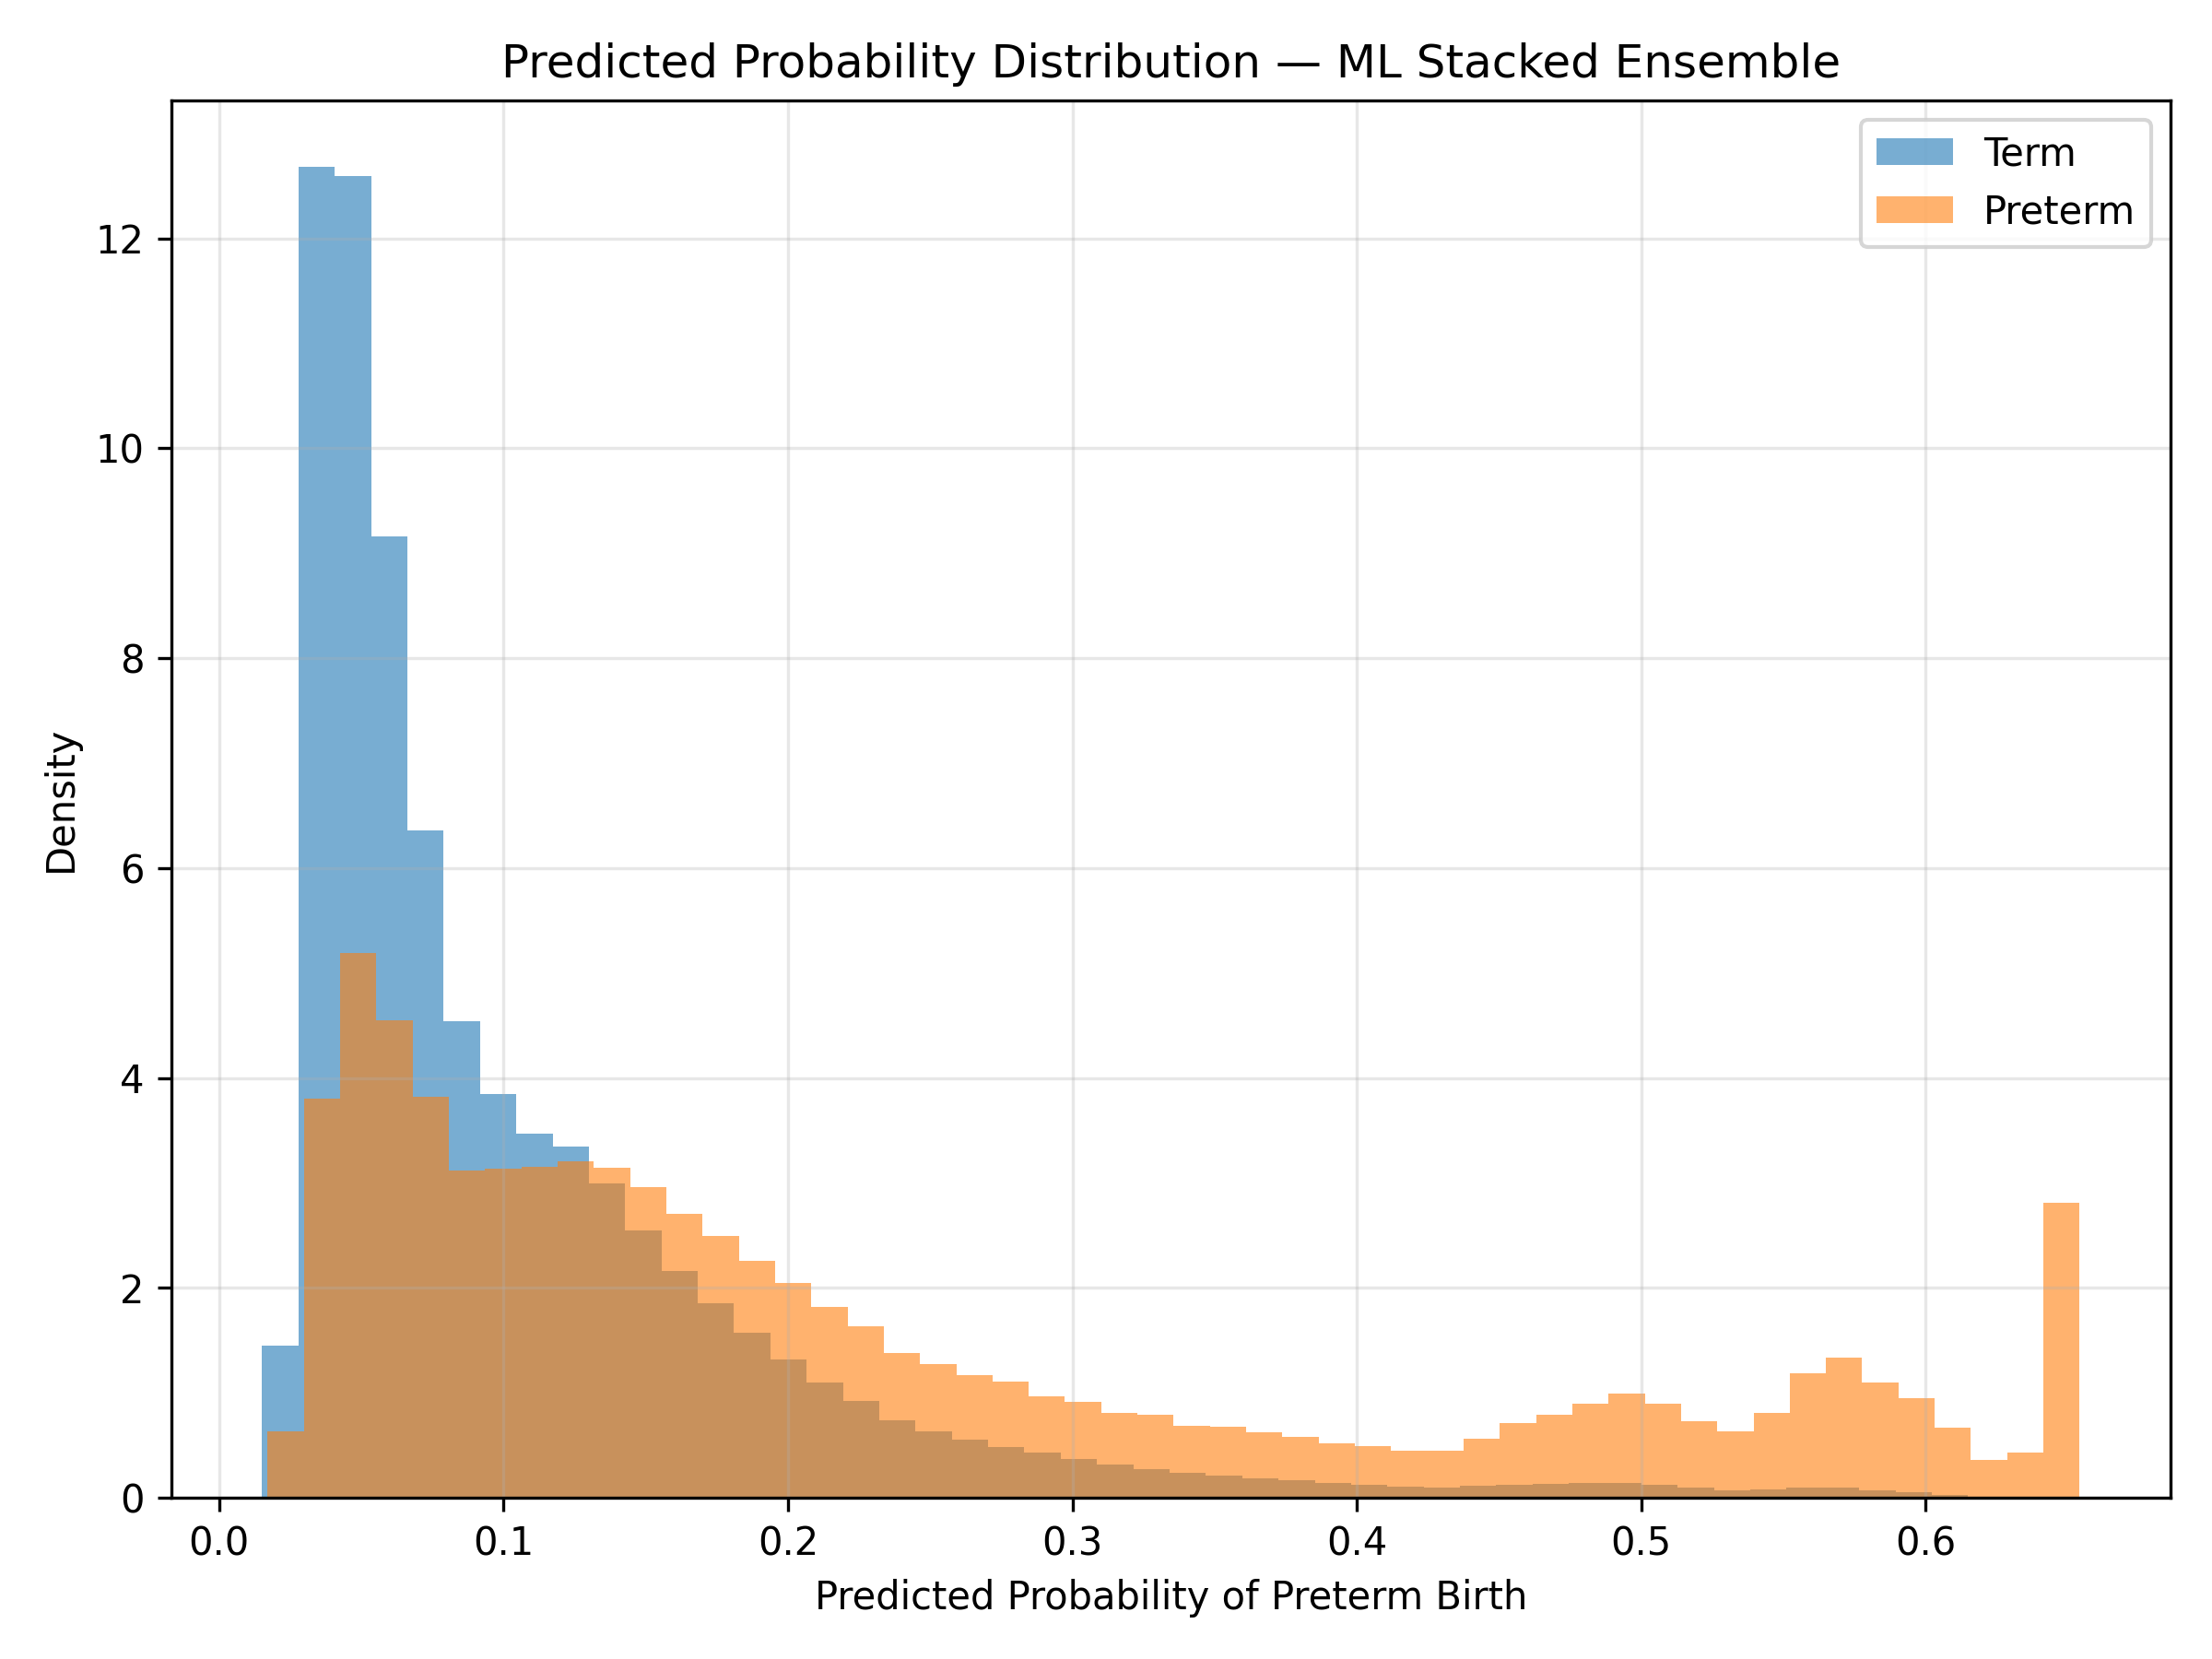

### Mean |SHAP value| — Top 20 Features

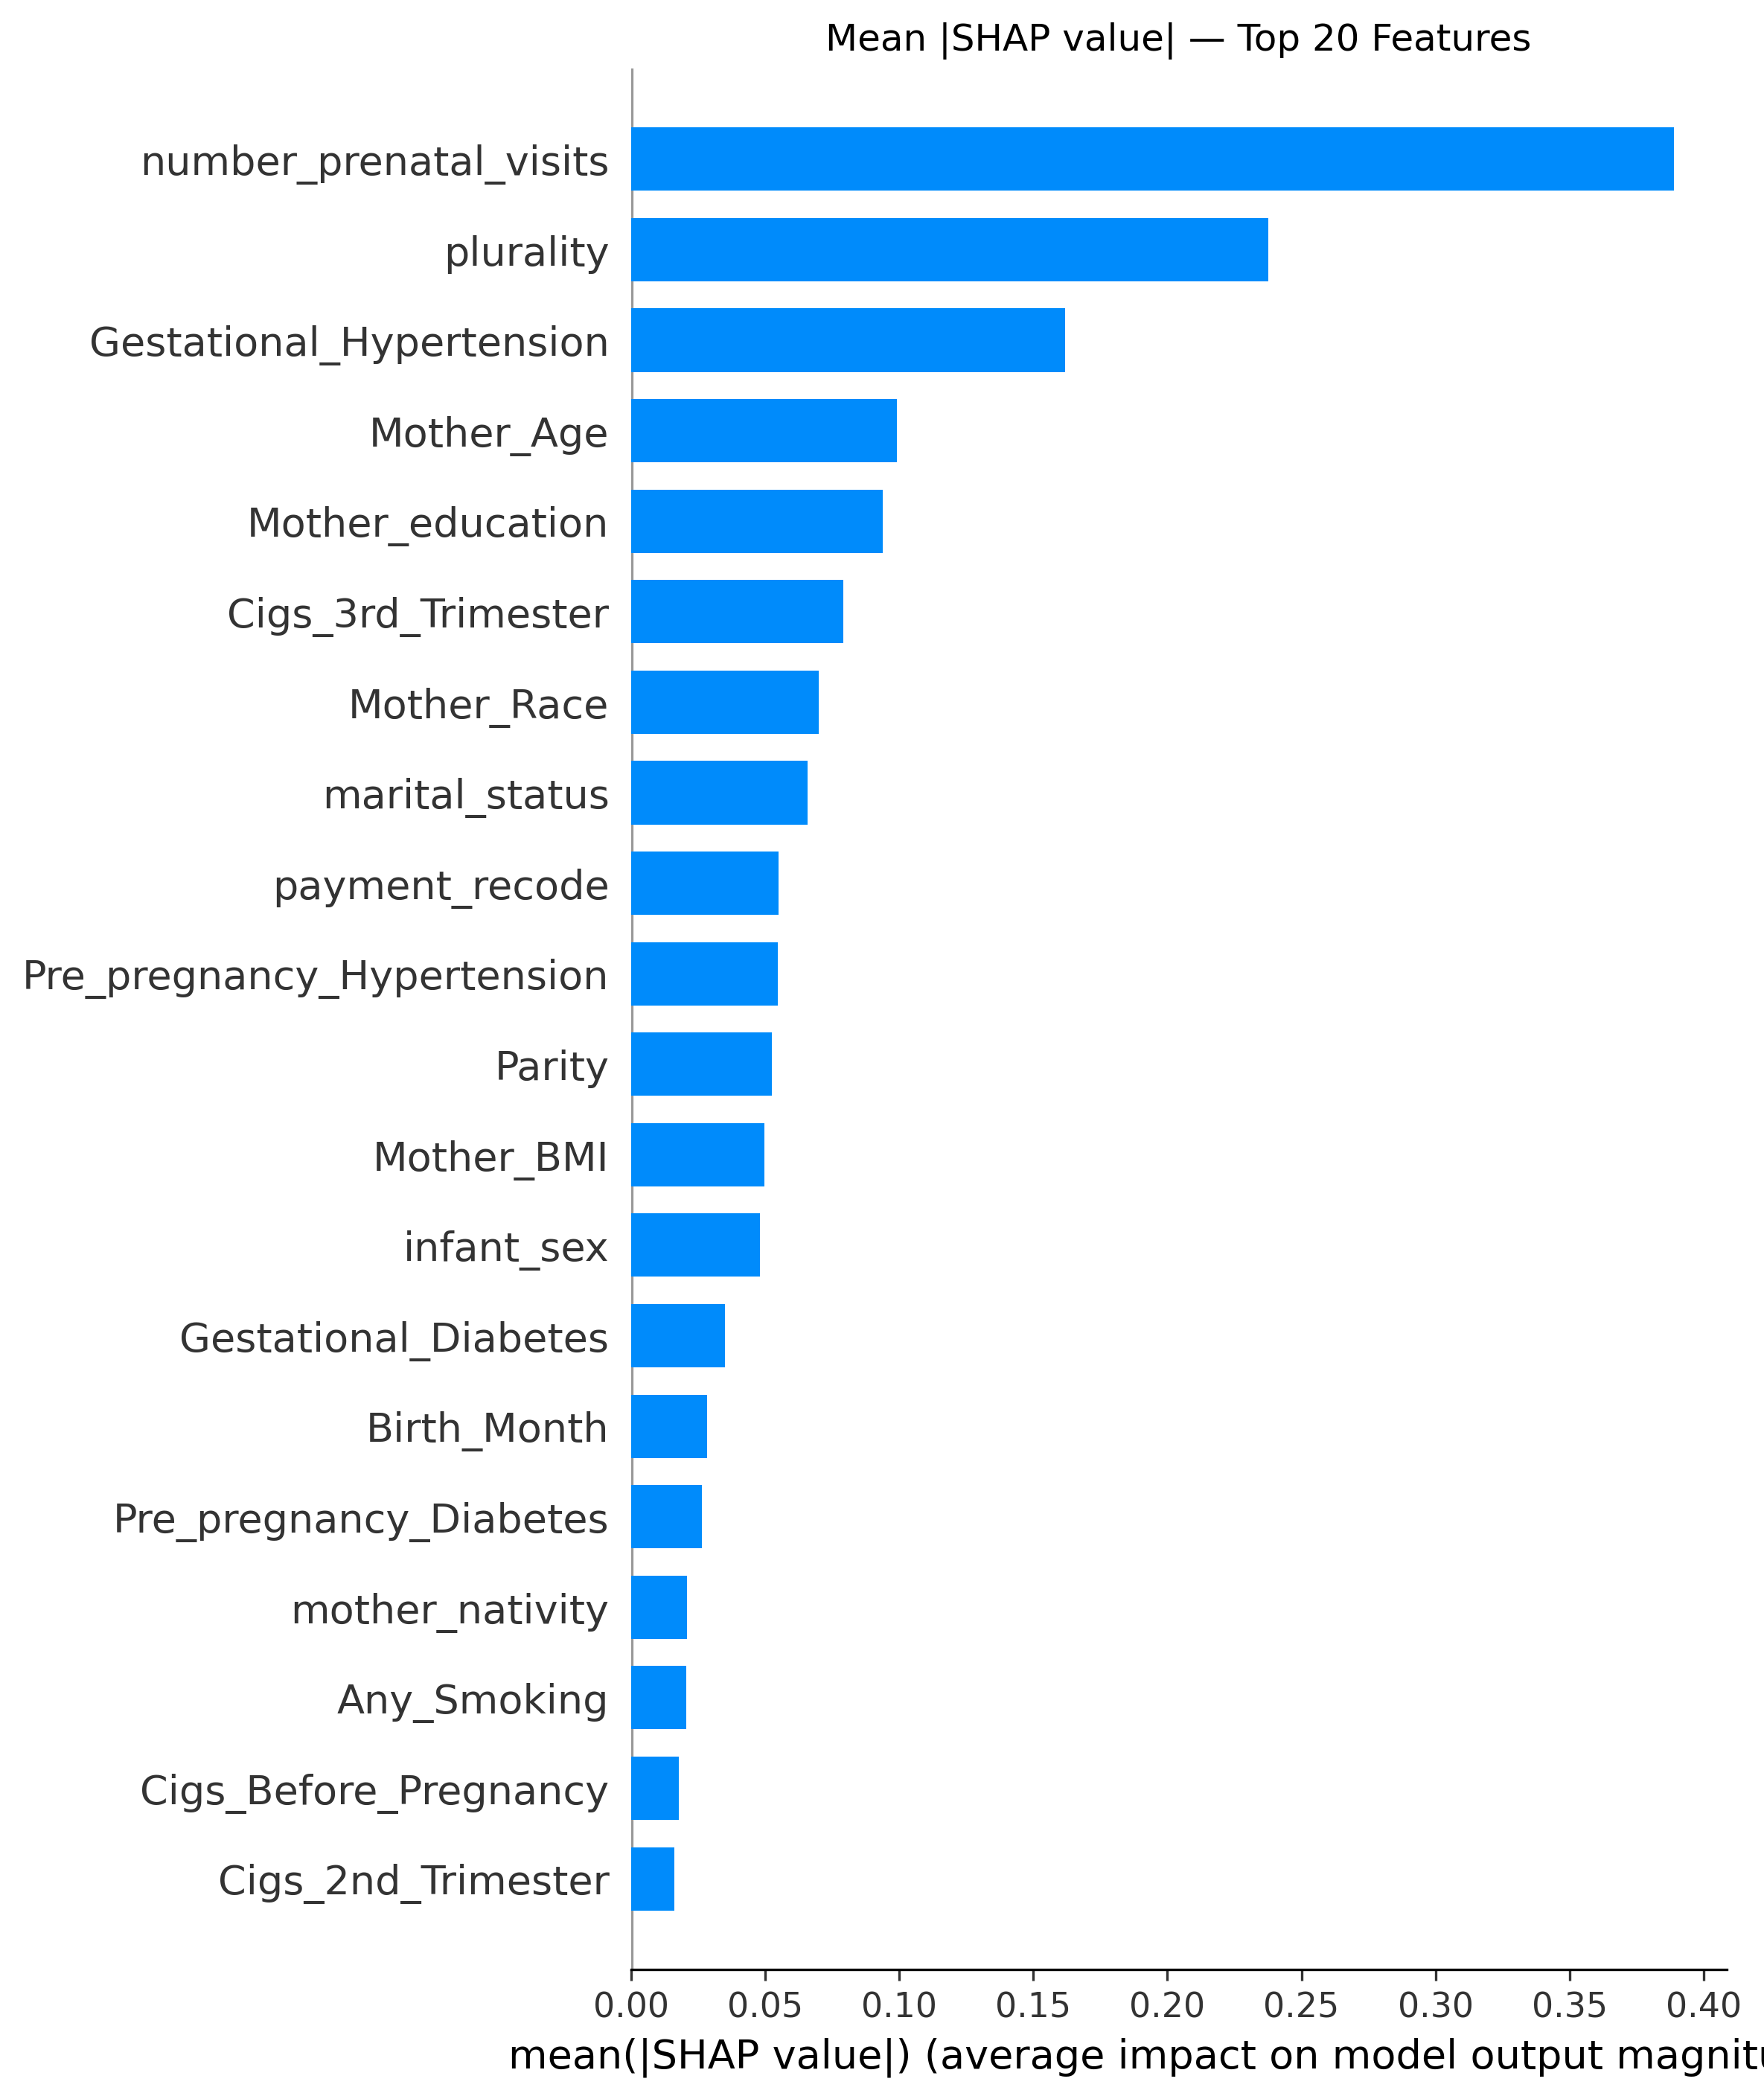

### Feature Correlation Heatmap — Top 20

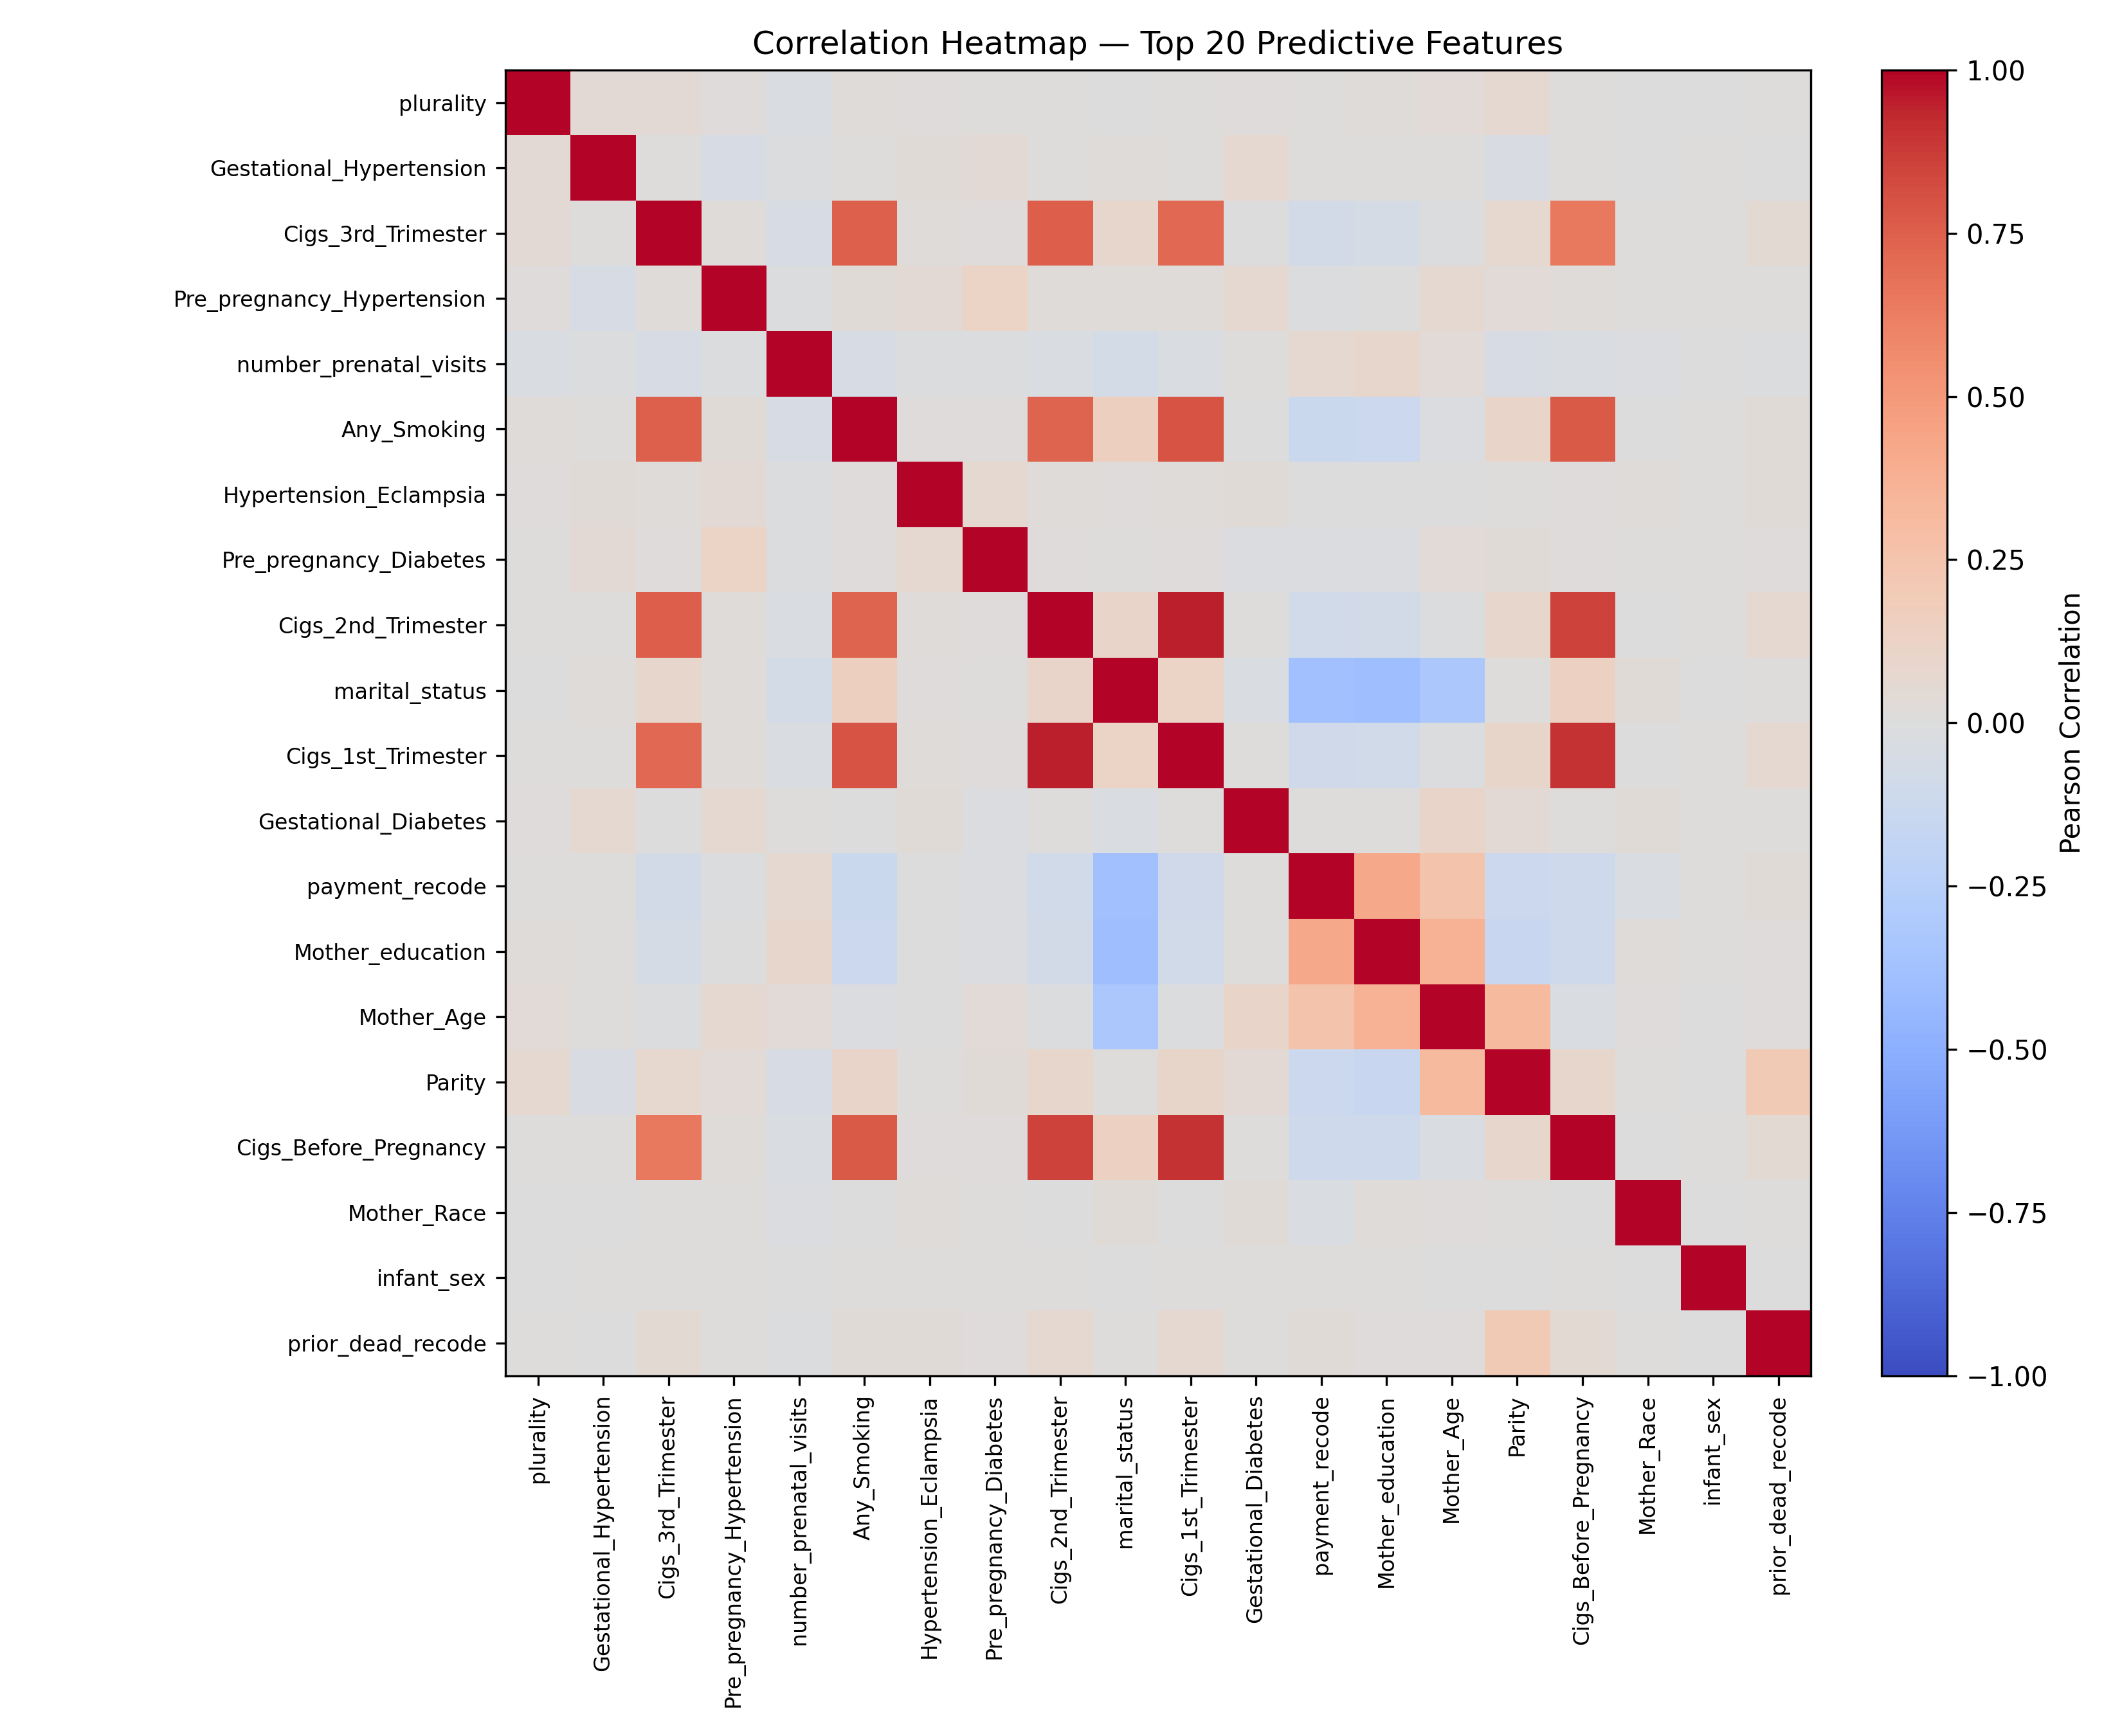

### Radar Chart — Multi-Metric Model Comparison

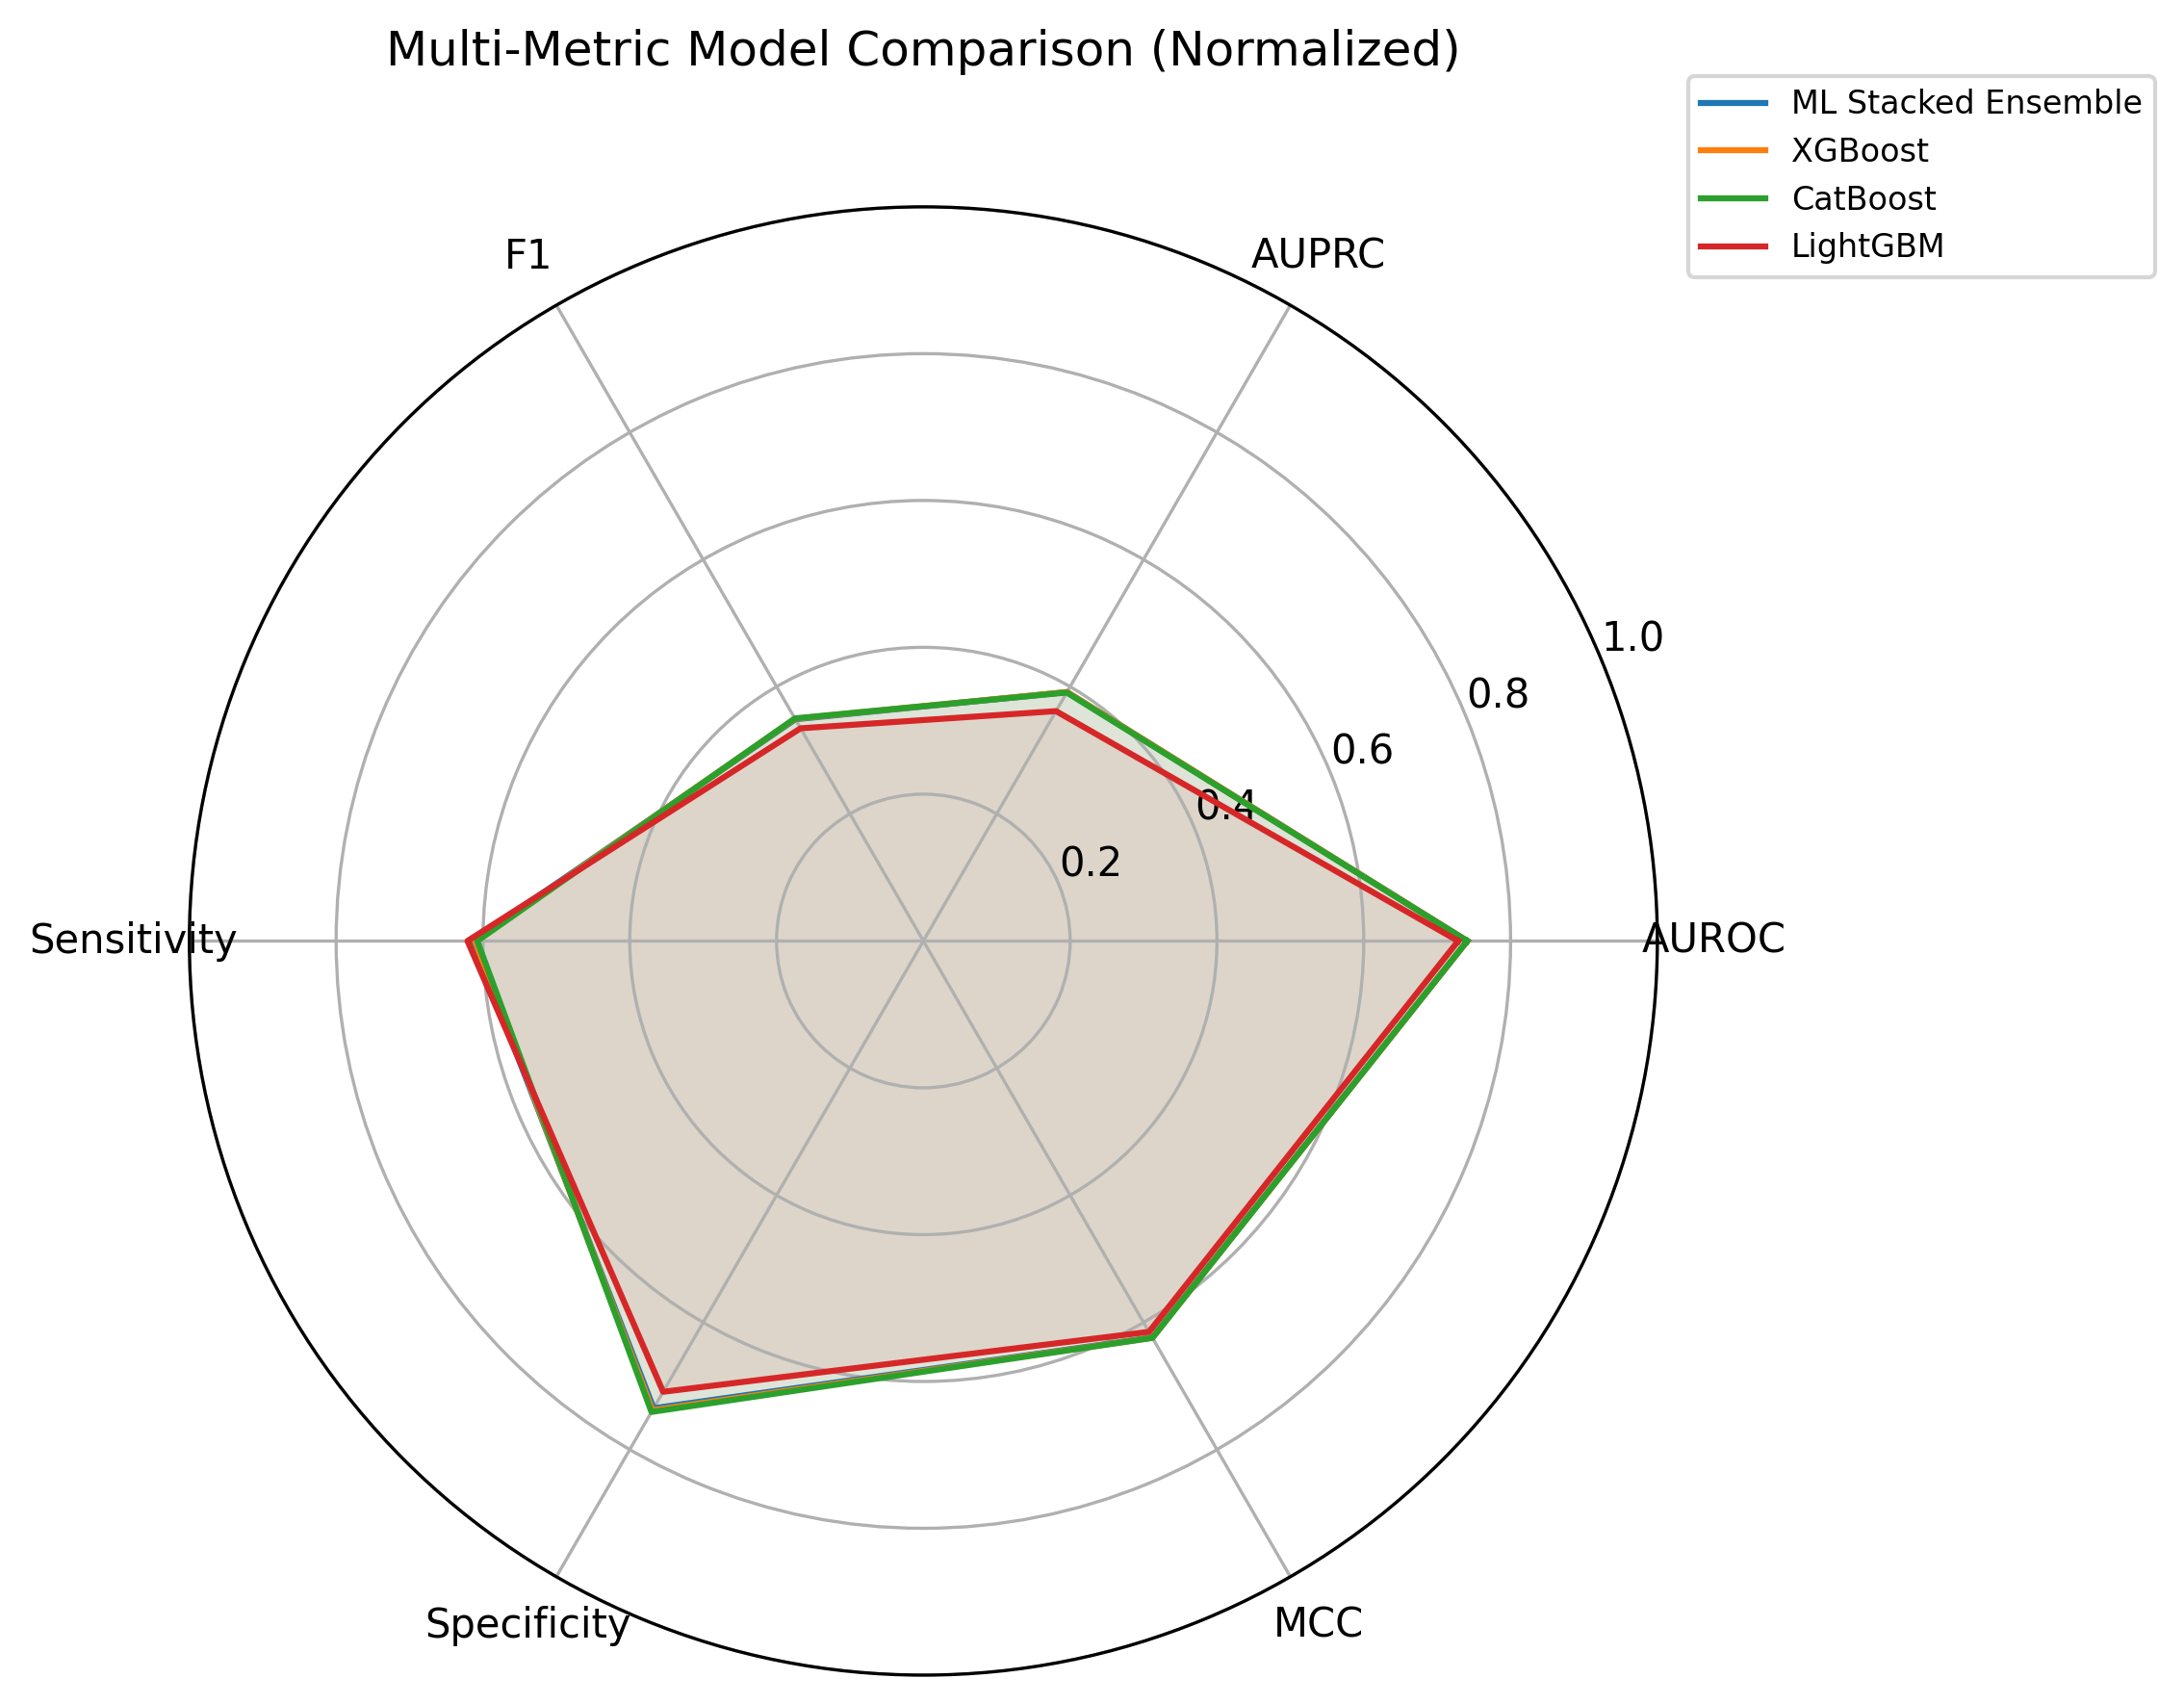

### shap_dependence_Any_Smoking.png

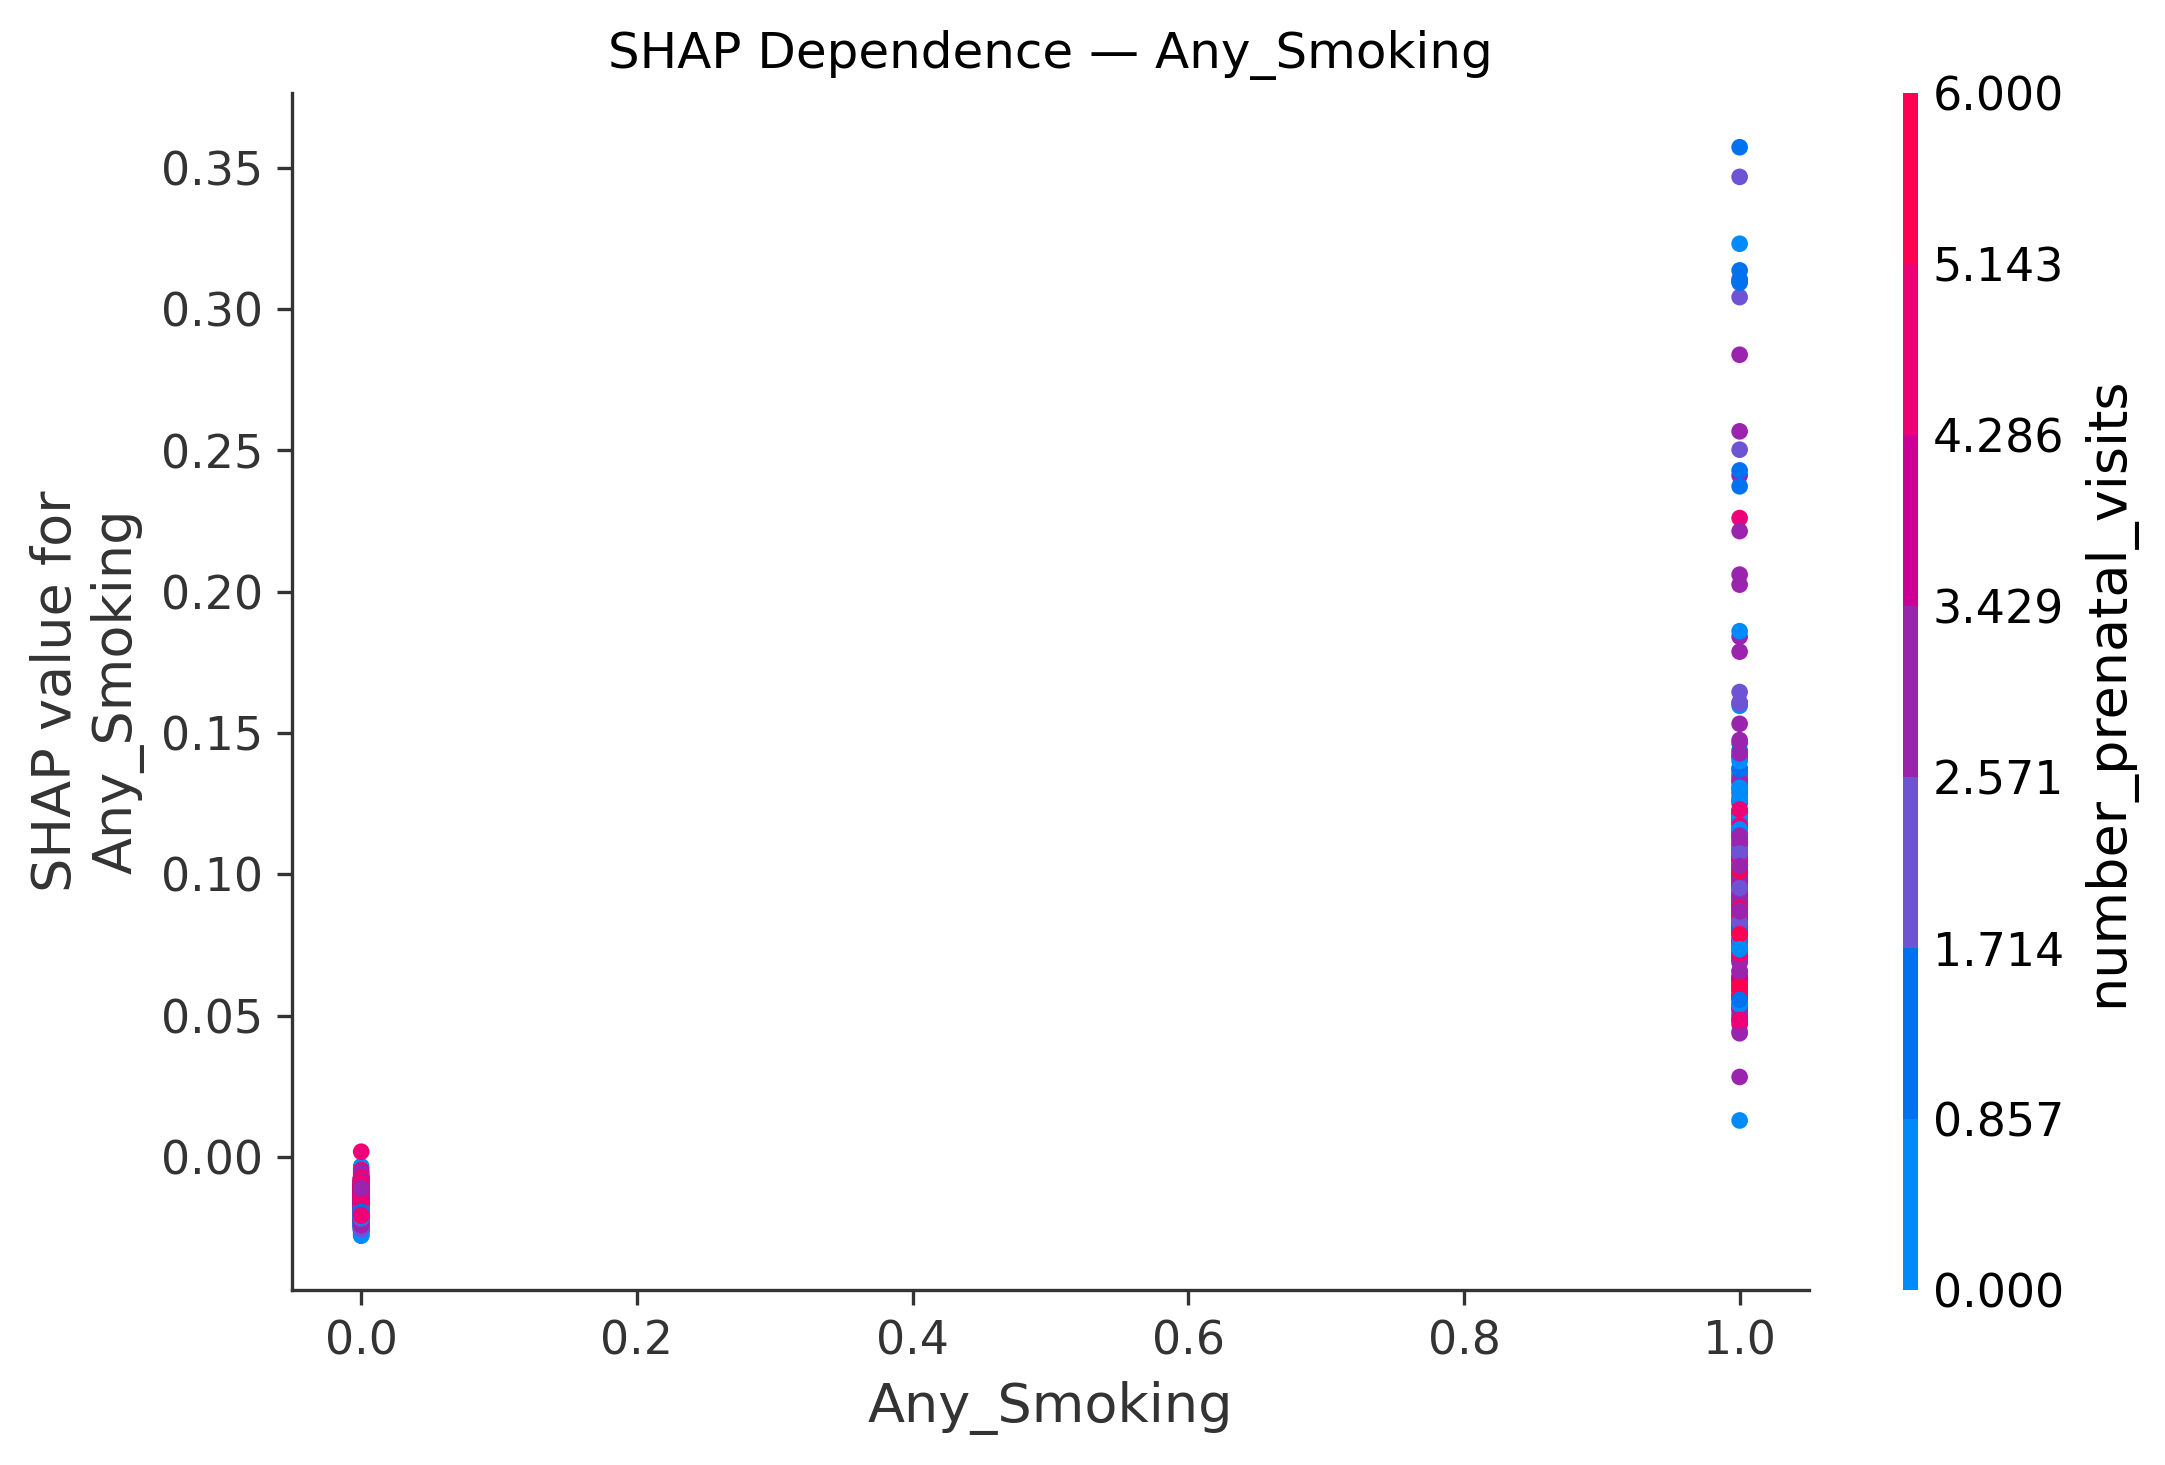

### shap_dependence_Cigs_3rd_Trimester.png

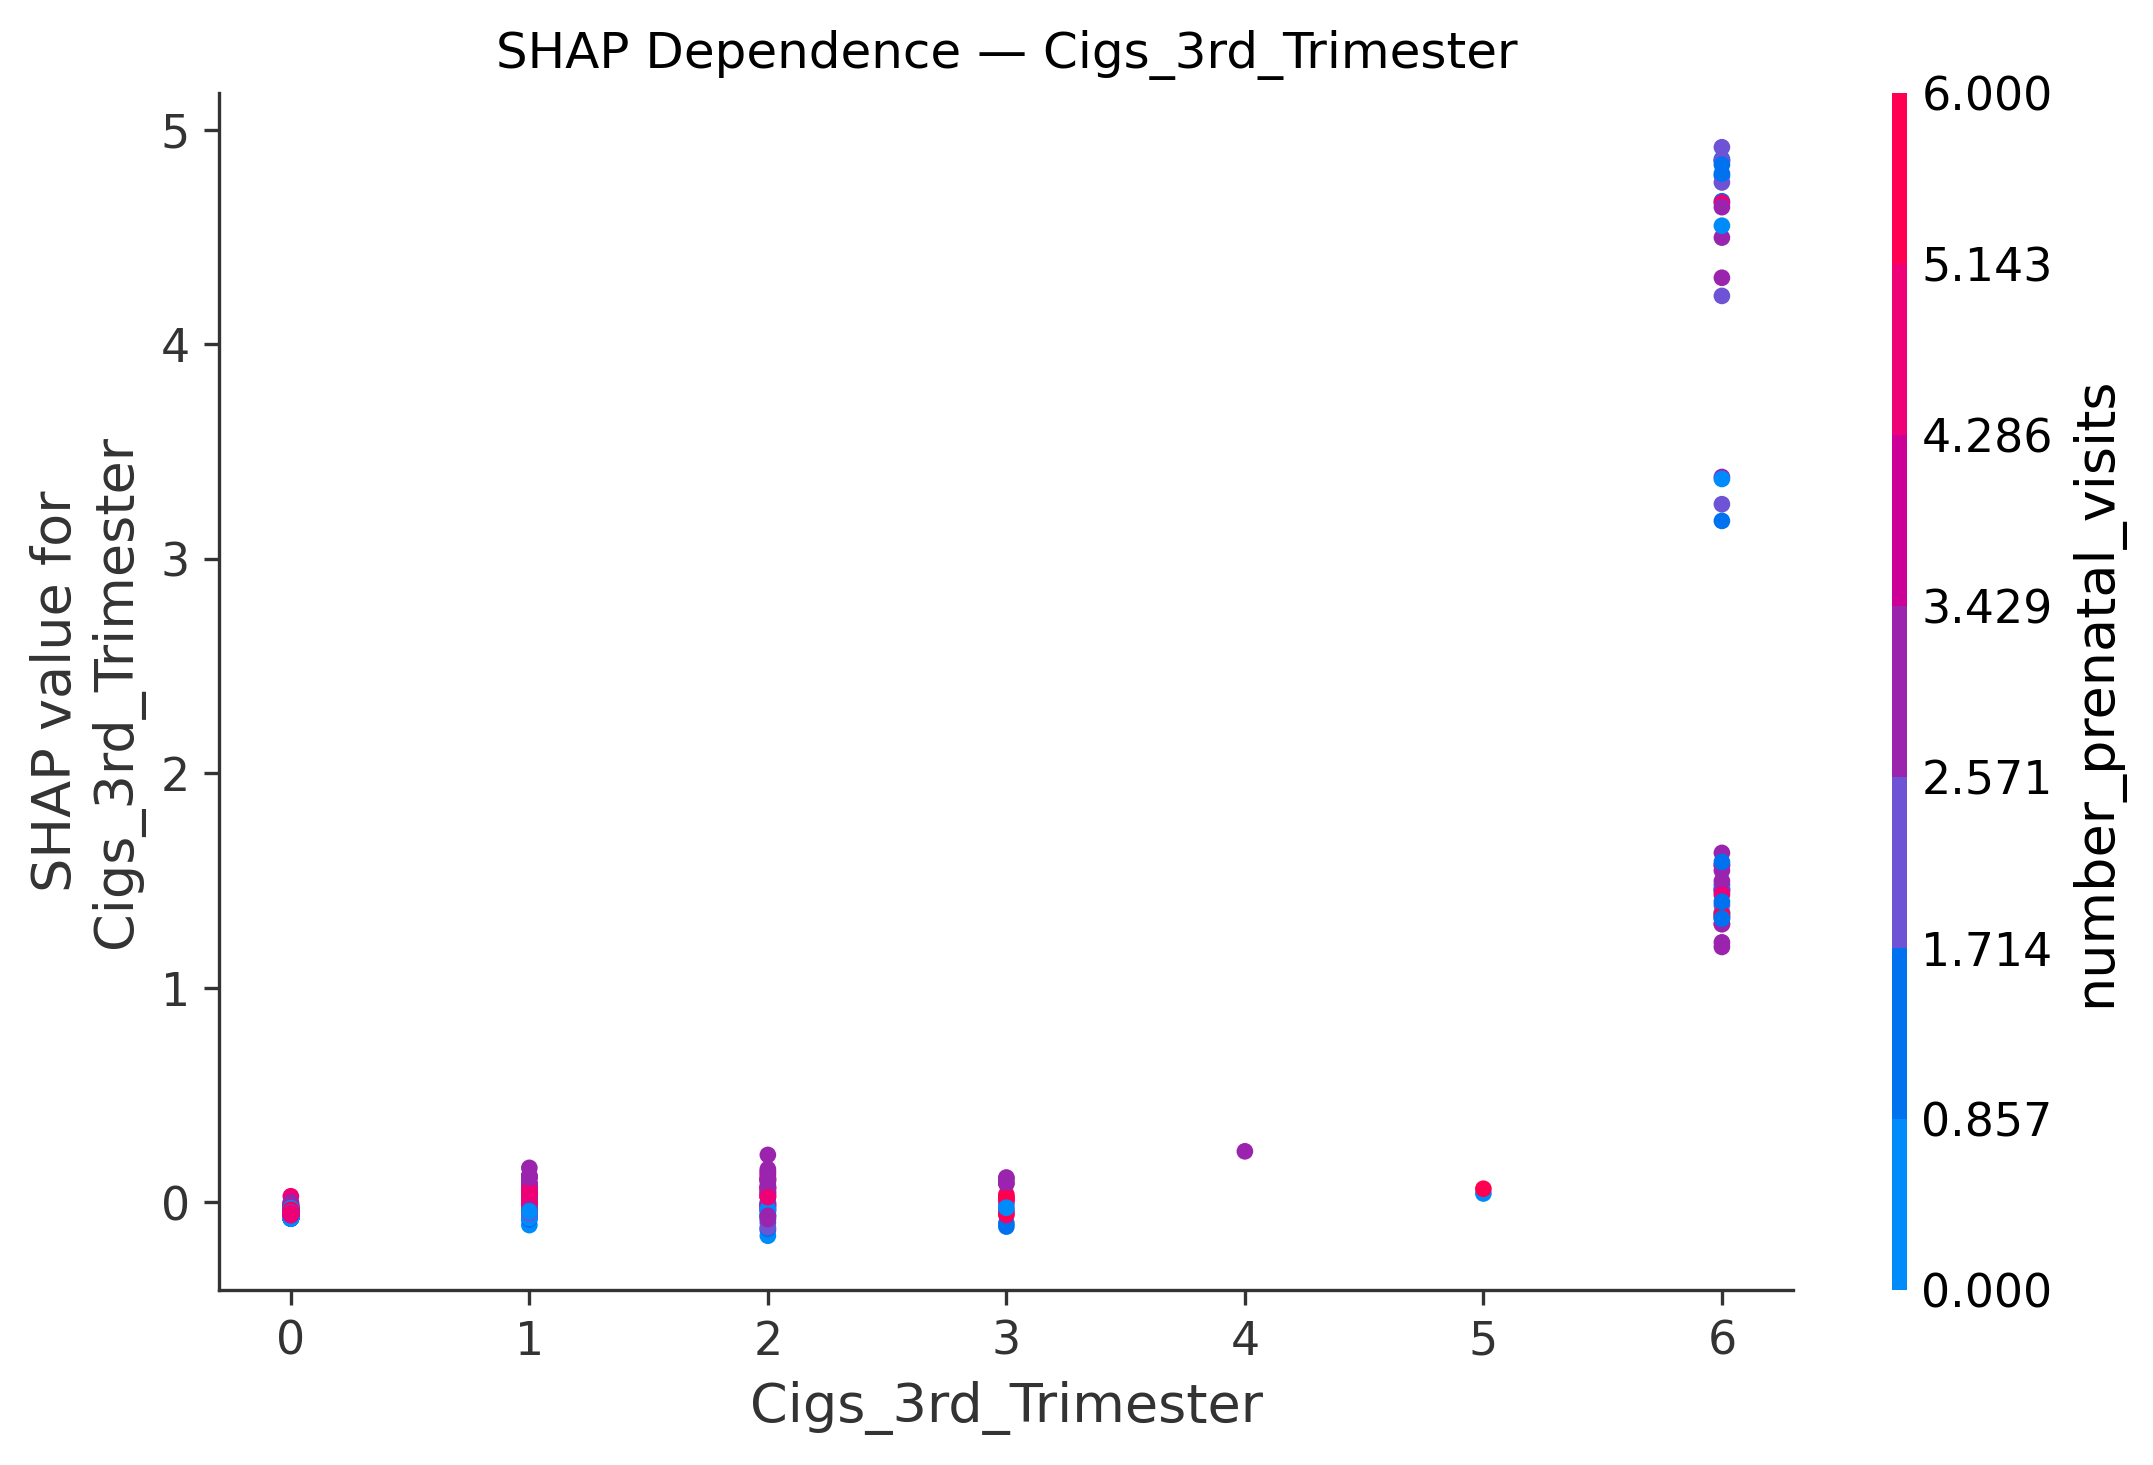

### shap_dependence_Gestational_Hypertension.png

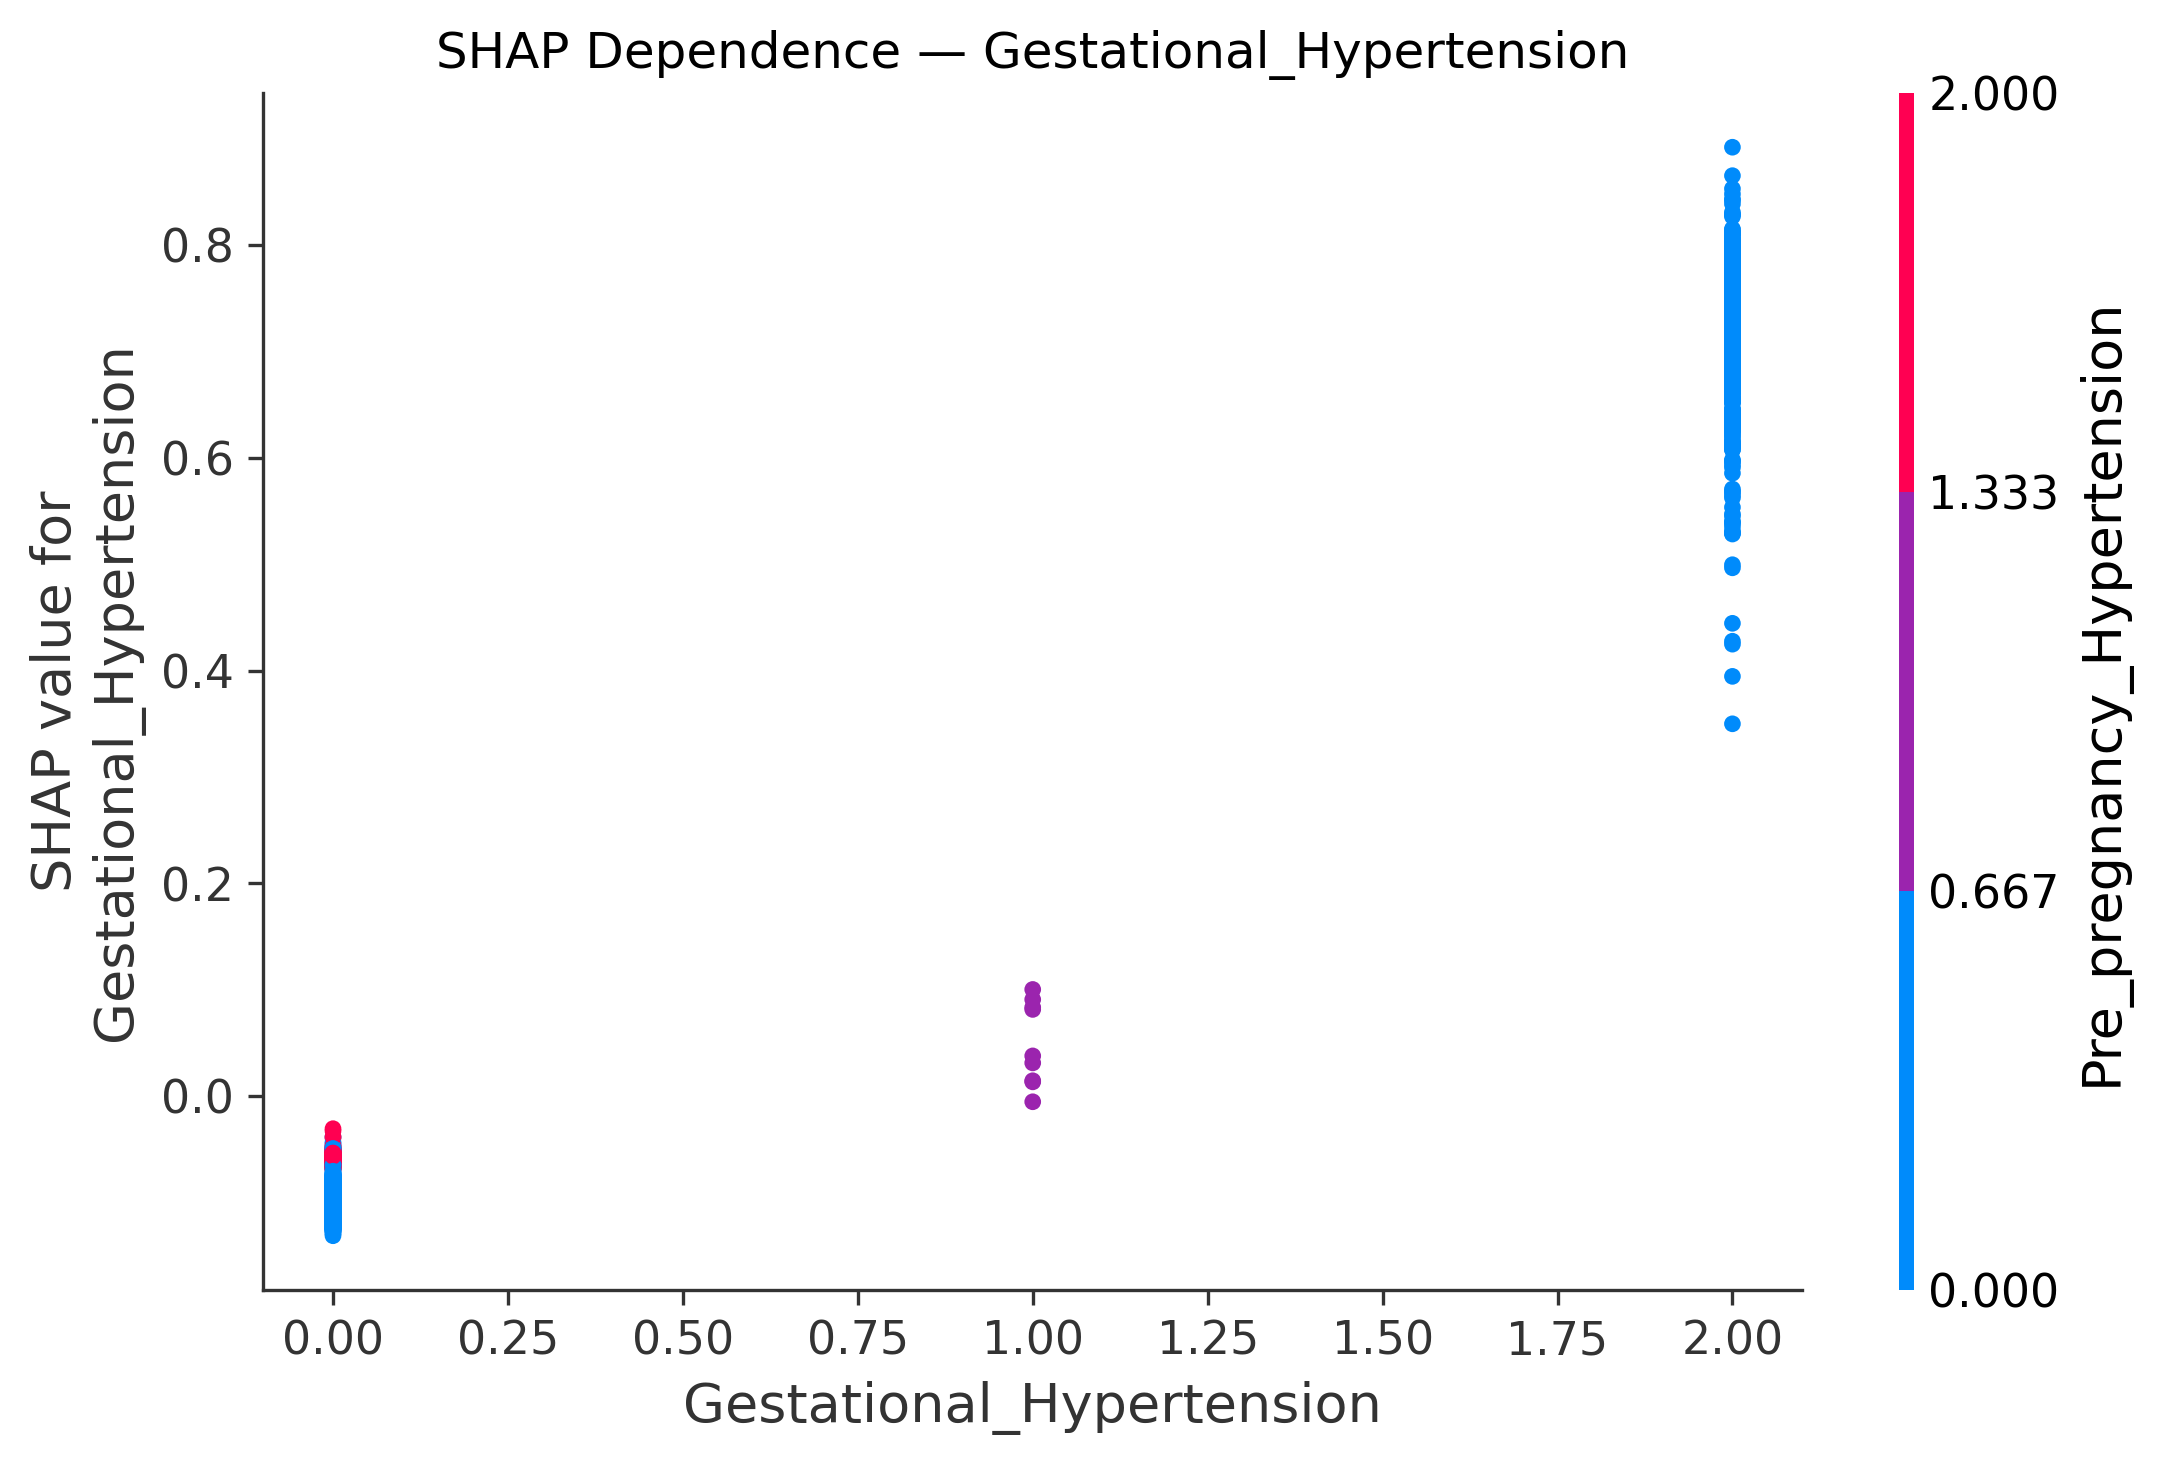

### shap_dependence_Pre_pregnancy_Hypertension.png

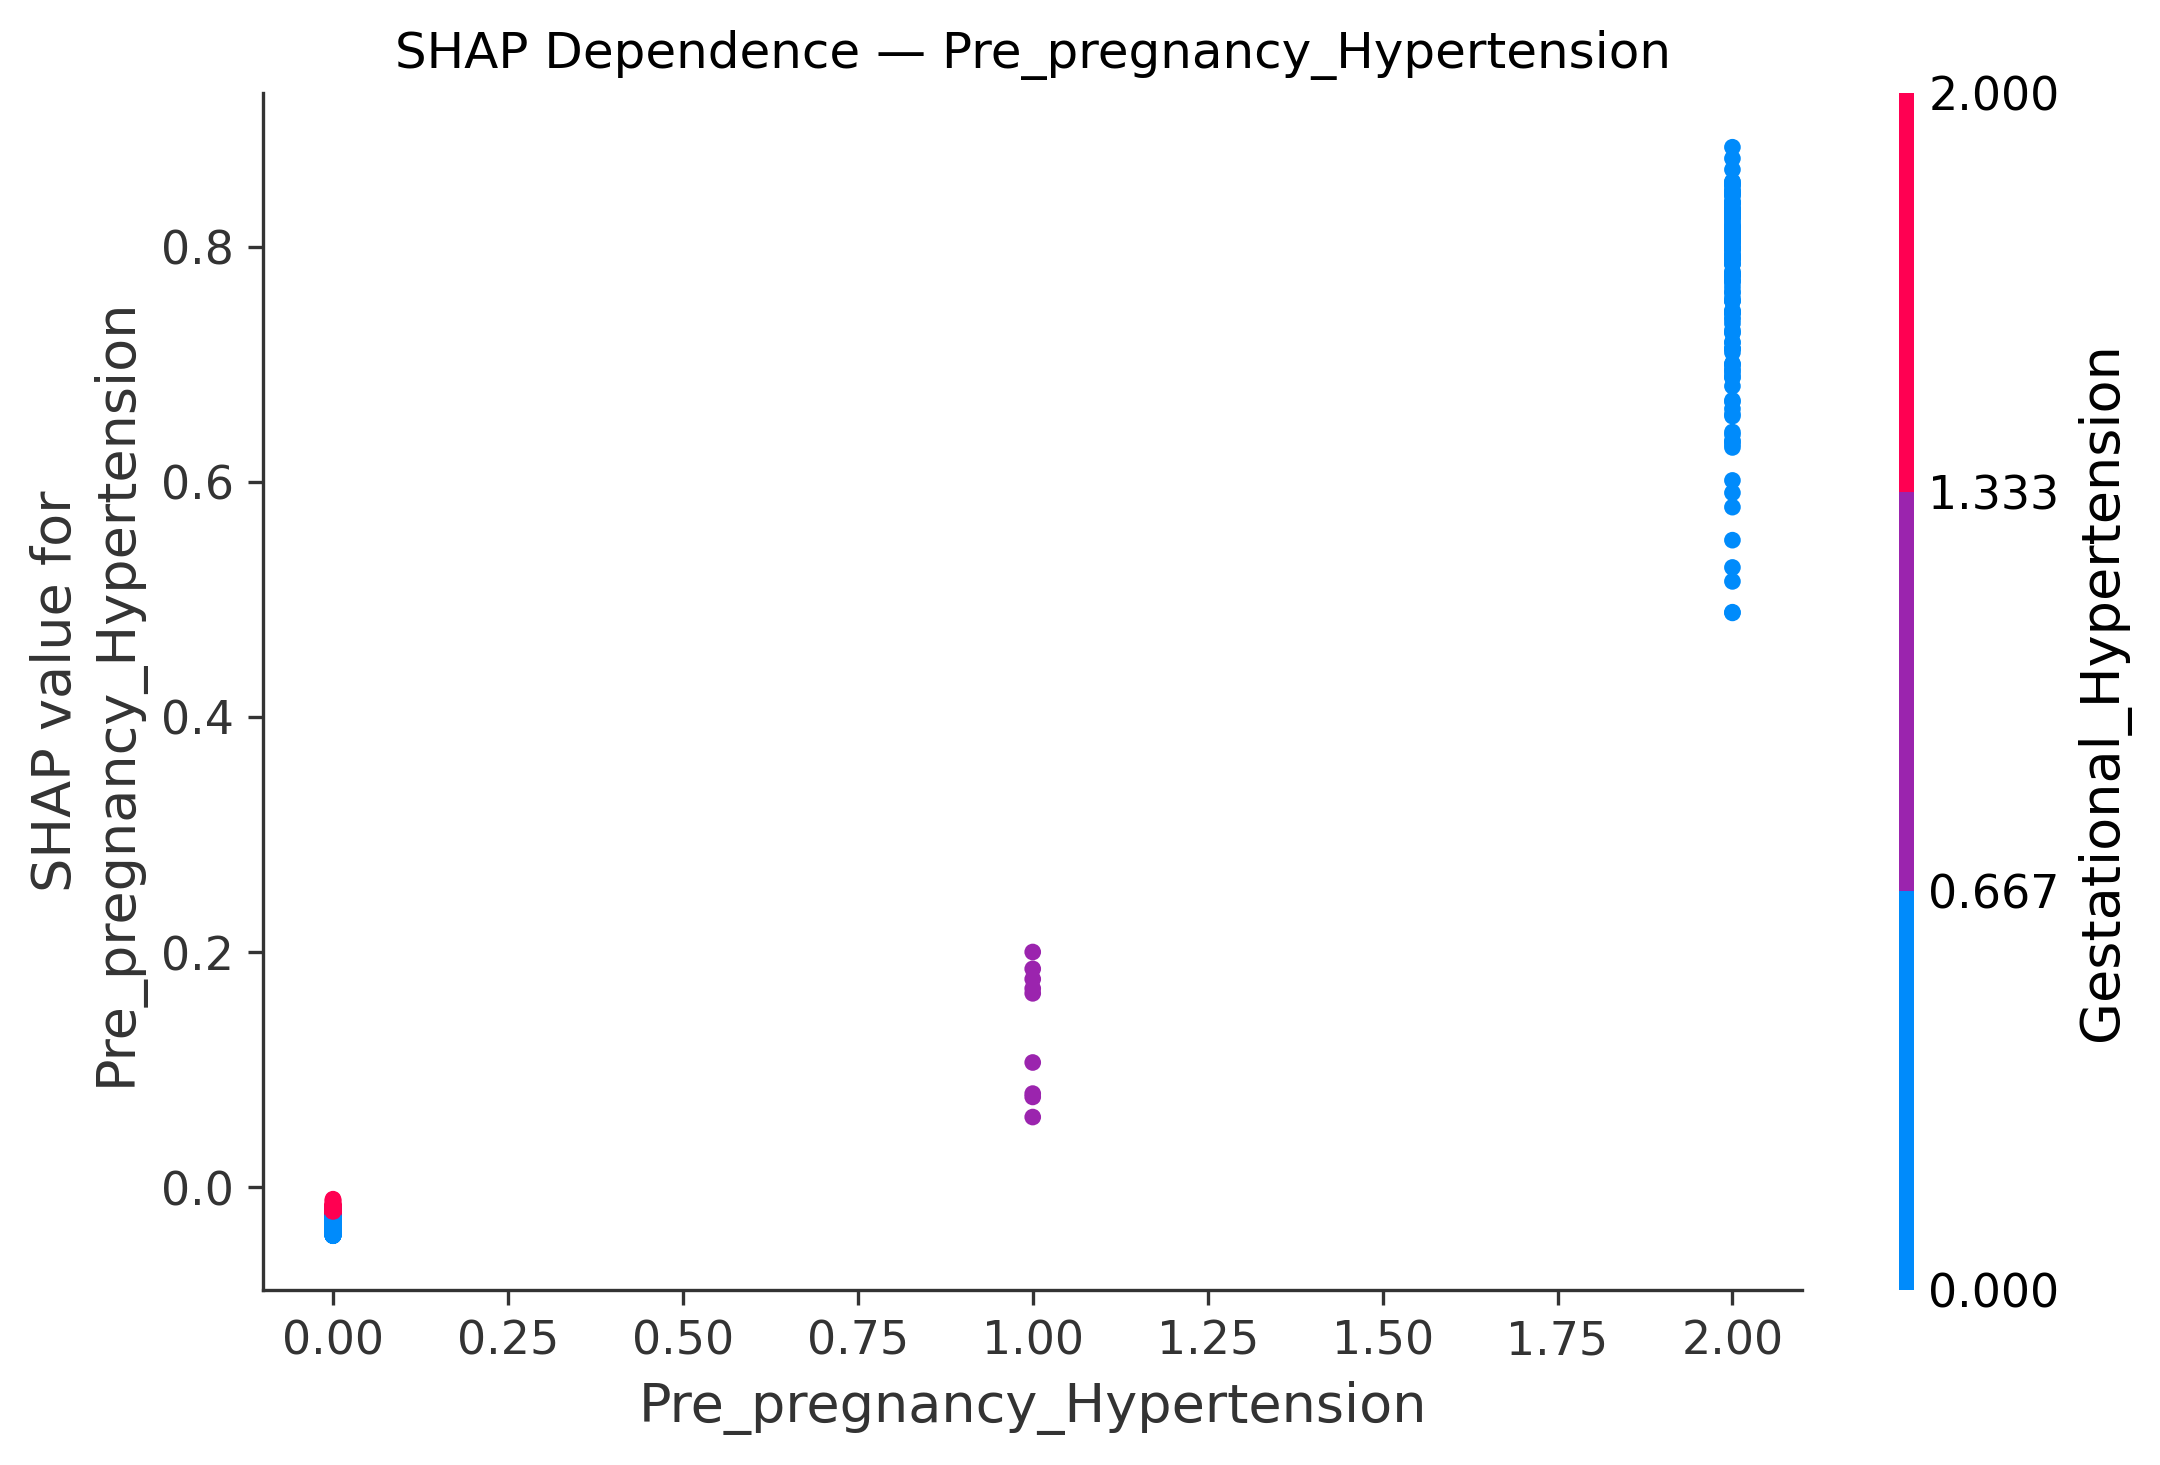

### shap_dependence_number_prenatal_visits.png

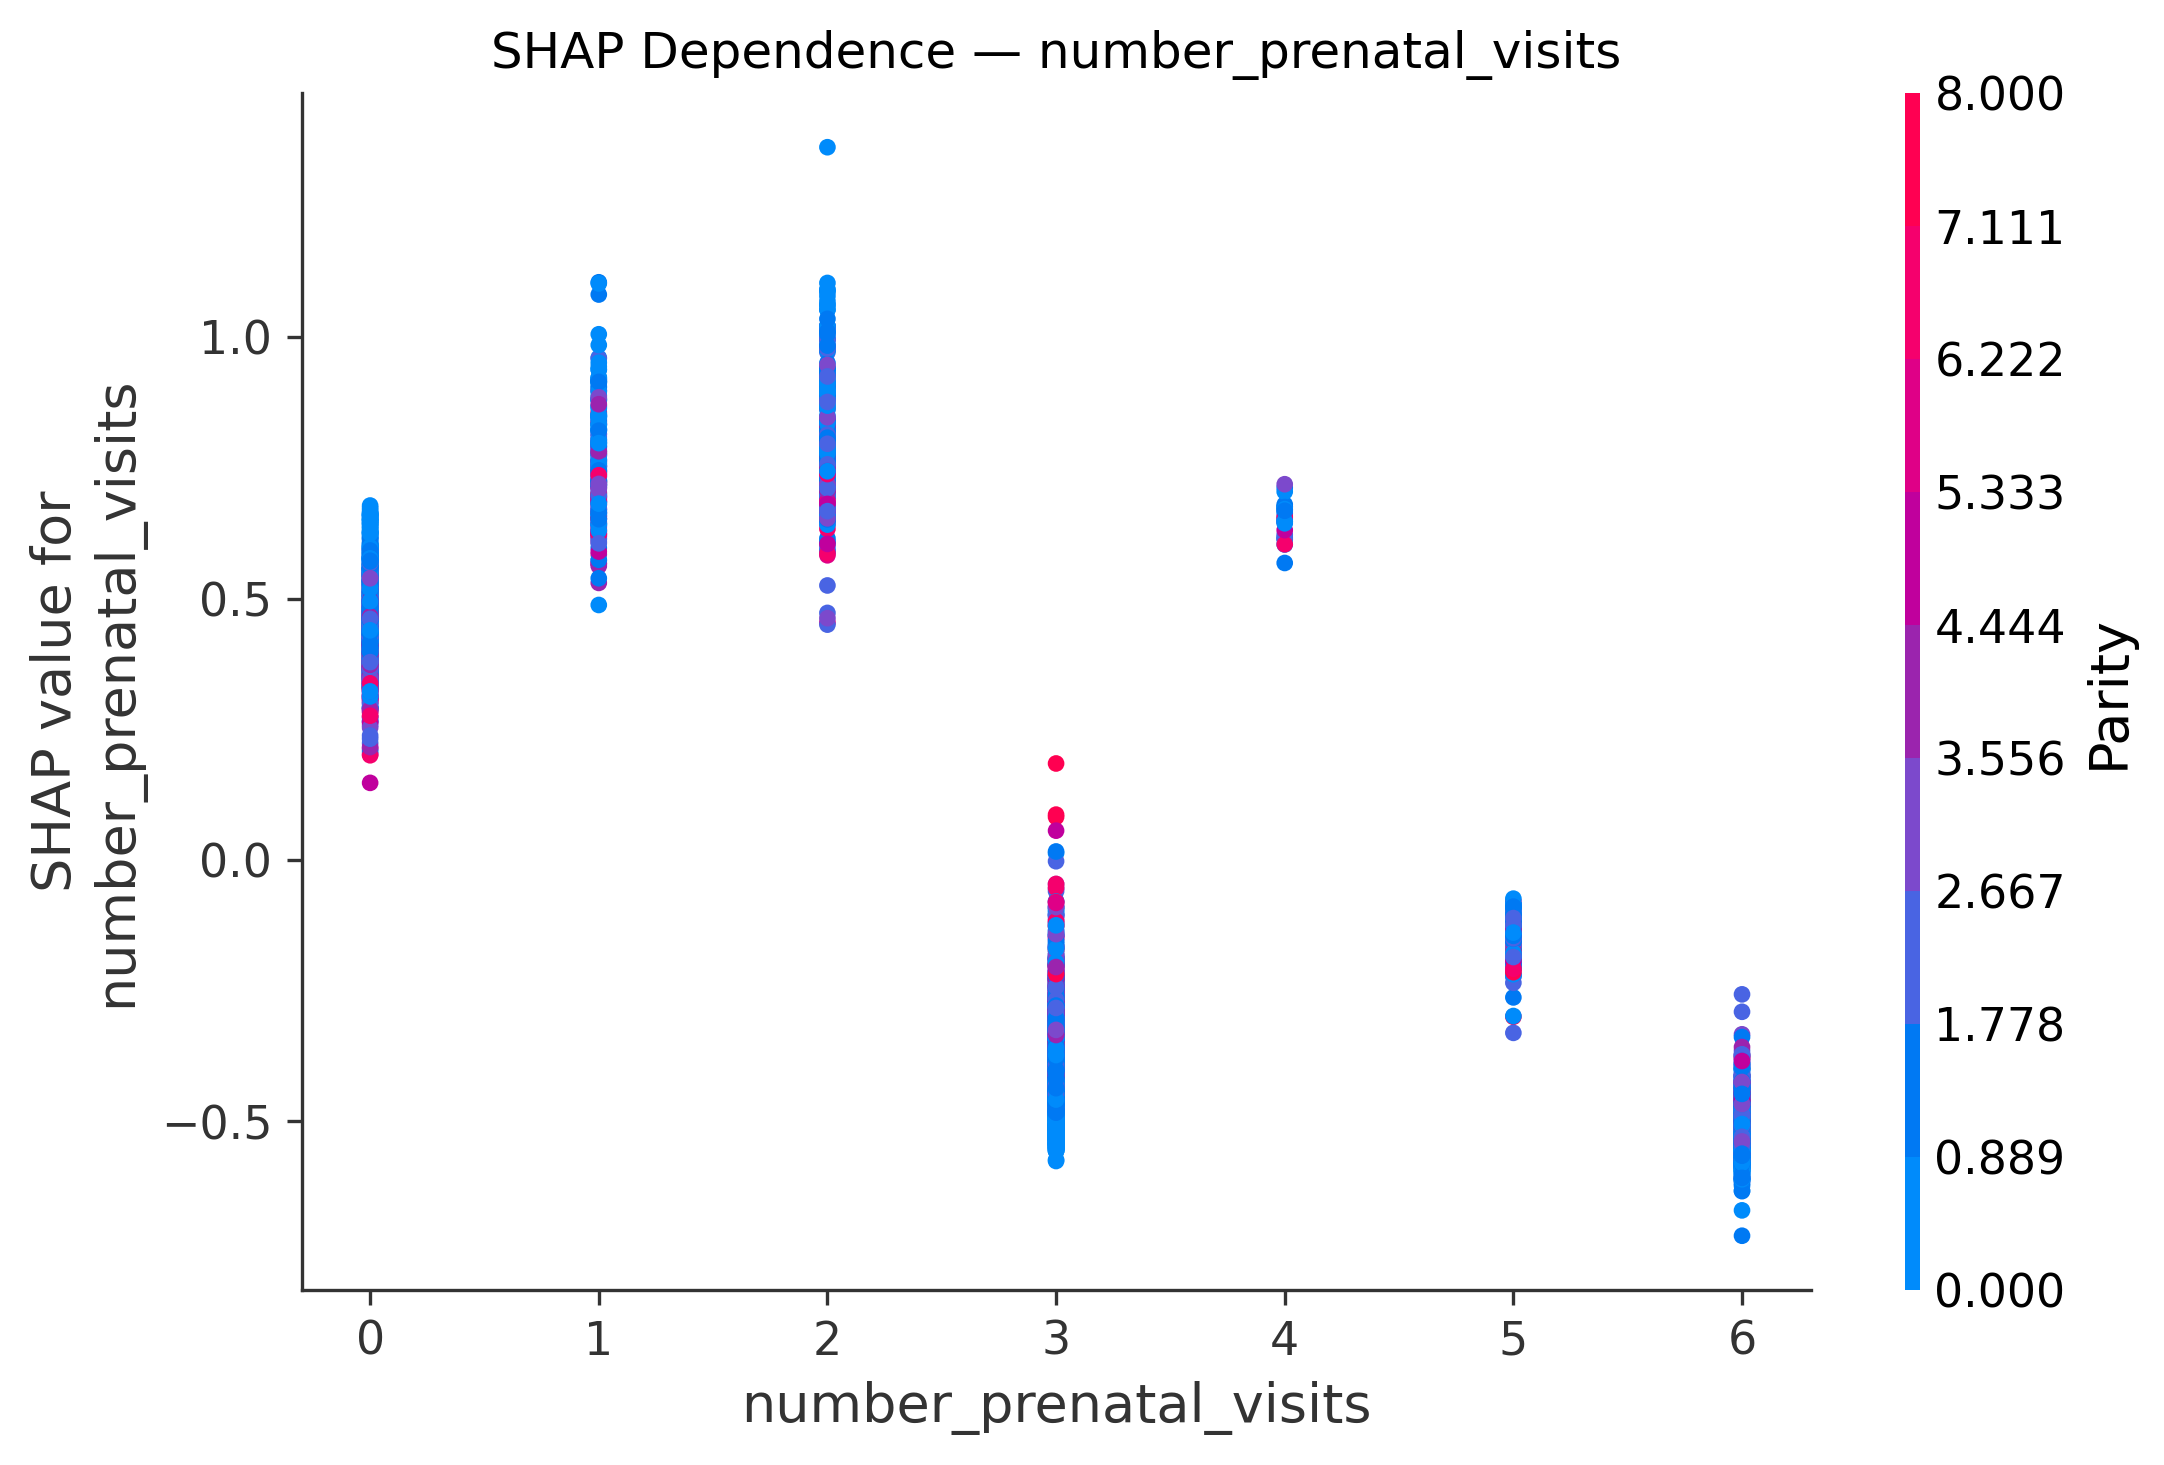

### shap_dependence_plurality.png

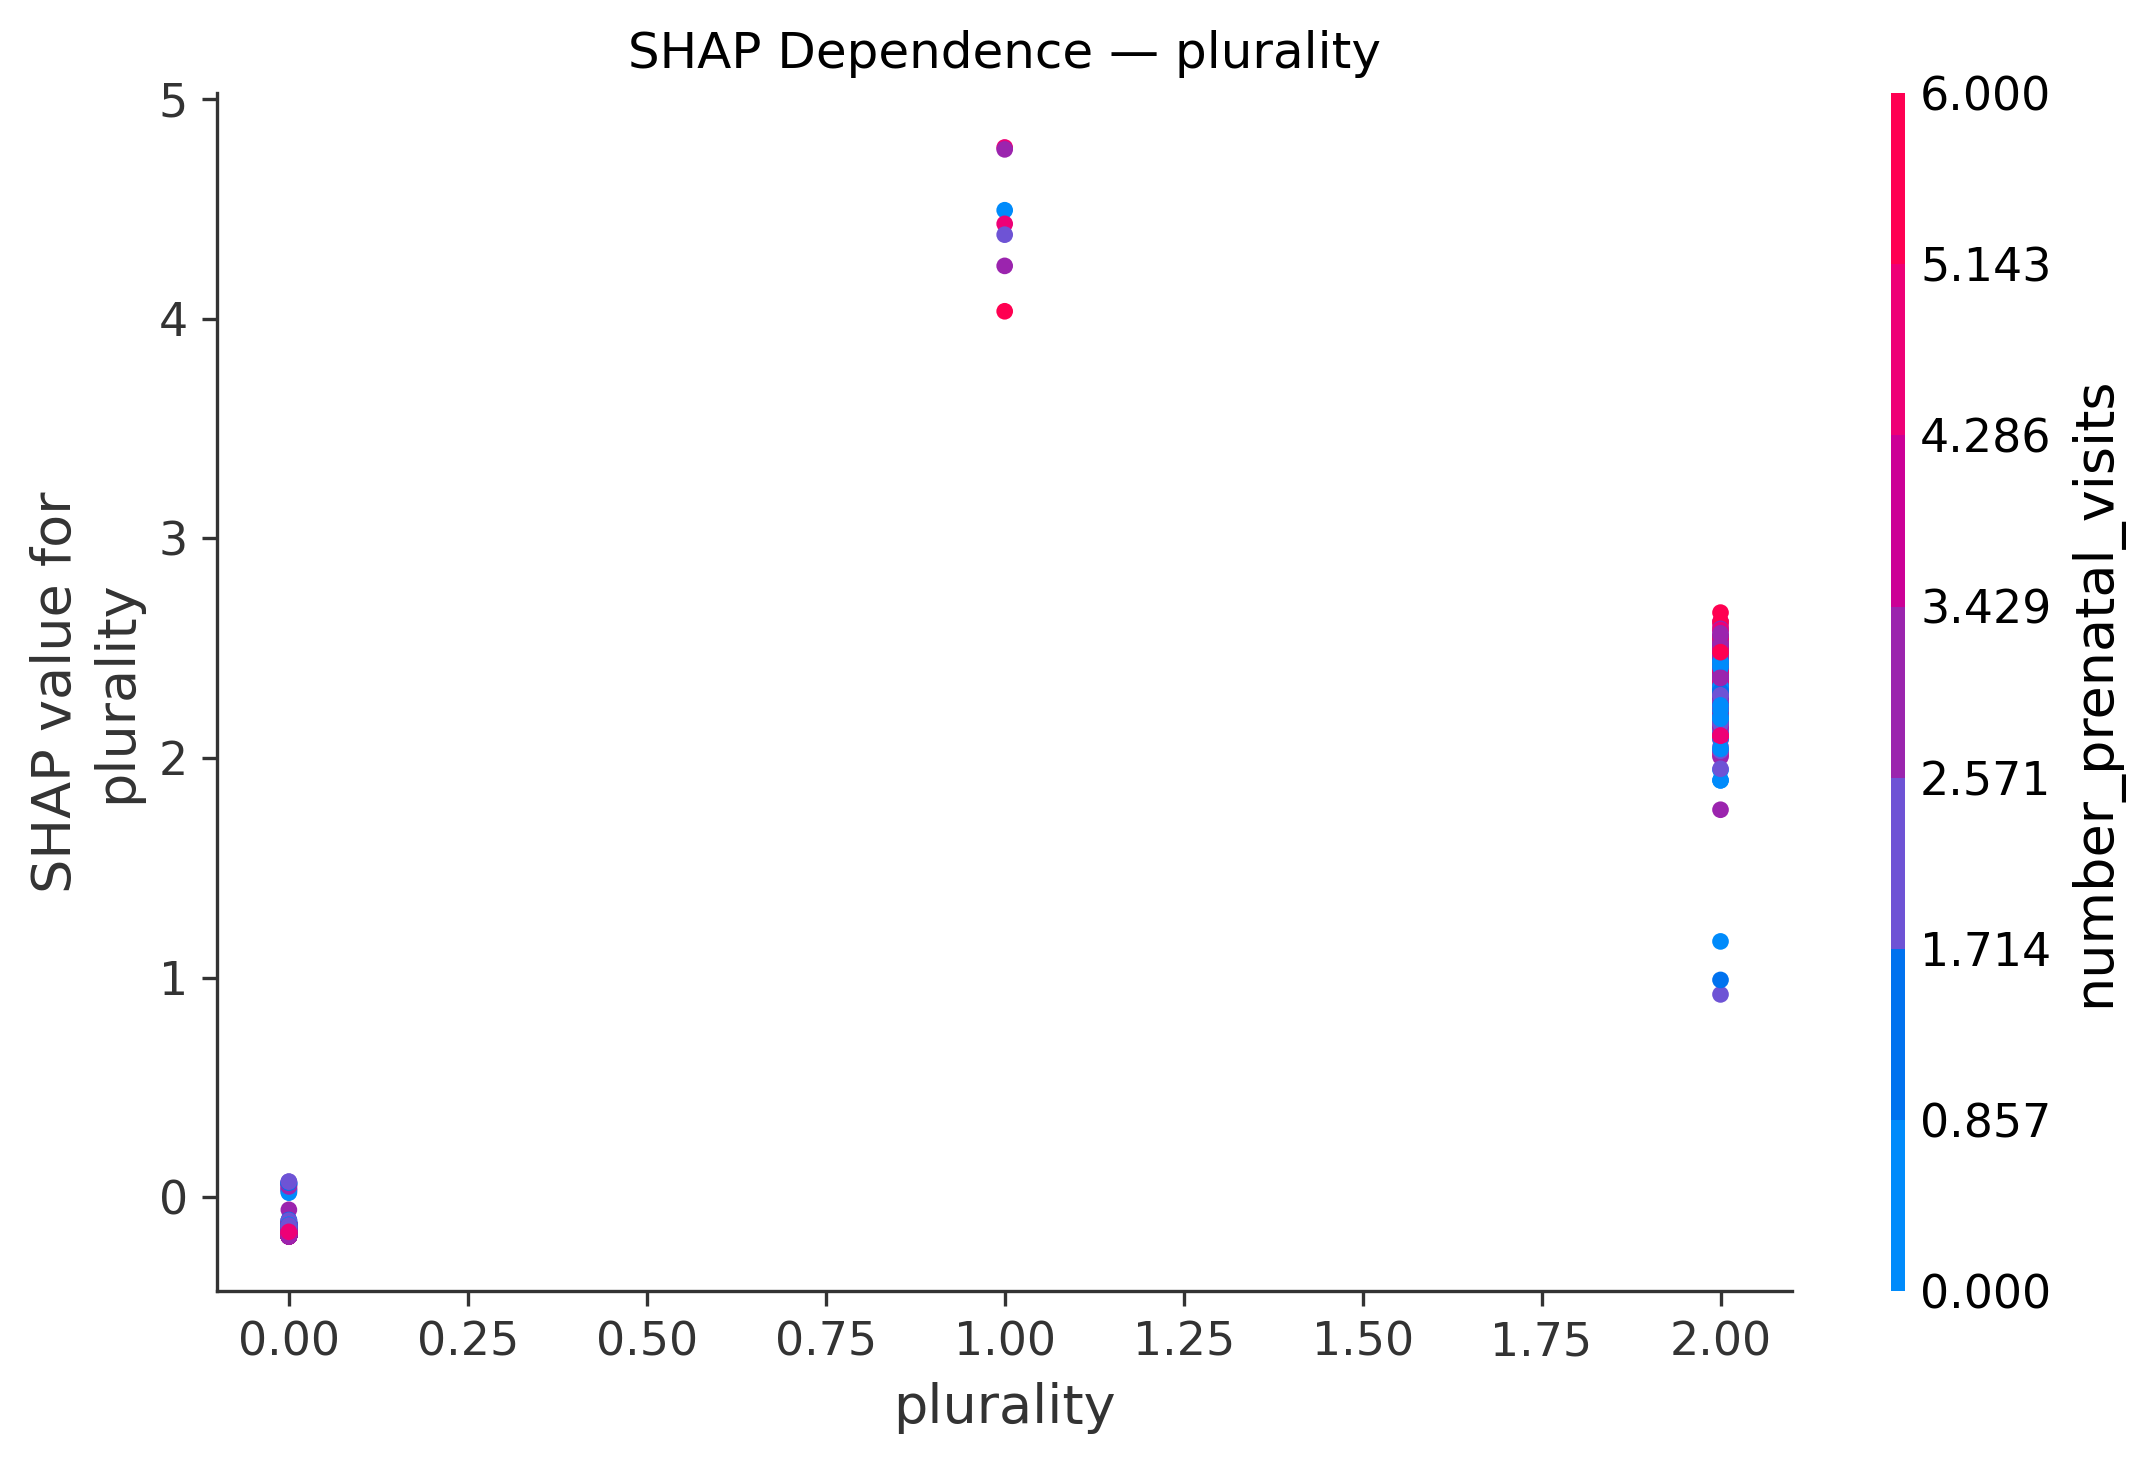


Done displaying figures.

EXPORTING TRANSFORMED DATASET
train: 7,603,761 rows x 27 cols
  CSV:     /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/train_transformed.csv
  Parquet: /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/train_transformed.parquet
val: 1,629,378 rows x 27 cols
  CSV:     /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/val_transformed.csv
  Parquet: /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/val_transformed.parquet
test: 1,629,378 rows x 27 cols
  CSV:     /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/test_transformed.csv
  Parquet: /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/test_transformed.parquet

Combined: 10,862,517 rows x 28 cols
  CSV:     /kaggle/working/preterm_scopus_publication_outputs/transformed_dataset/full_transformed_dataset.csv
  Parquet: /kaggle/working/preterm_scopus_publication_outputs/transforme

In [3]:
# ============================================================
# PART C — DISPLAY IMAGES INLINE + EXPORT TRANSFORMED DATASET
# Run this AFTER Part A (main pipeline) and Part B (extra assets)
# Reuses variables from those cells: OUT_DIR, EXTRA_DIR,
# X_train, X_val, X_test, y_train, y_val, y_test
# ============================================================

import os
import glob
from pathlib import Path
from IPython.display import Image as IPyImage, display, Markdown

# ------------------------------------------------------------
# C1. Display every PNG from Part A + Part B, in order, with titles
# ------------------------------------------------------------

def show_image(path, title=None):
    if not os.path.exists(path):
        print(f"[SKIP] Not found: {path}")
        return
    if title:
        display(Markdown(f"### {title}"))
    display(IPyImage(filename=path, width=850))


print("=" * 90)
print("DISPLAYING ALL SAVED FIGURES")
print("=" * 90)

# --- Part A figures (main pipeline) ---
part_a_figs = [
    ("roc_curves_full_test.png", "ROC Curves - Full Test Models"),
    ("pr_curves_full_test.png", "Precision-Recall Curves - Full Test Models"),
    ("calibration_full_test.png", "Calibration Curves - Full Test Models"),
    ("cnn_roc_curves_test_subset.png", "CNN ROC Curves - CNN Test Subset"),
    ("cnn_pr_curves_test_subset.png", "CNN Precision-Recall Curves - CNN Test Subset"),
    ("xgboost_feature_importance.png", "XGBoost Feature Importance (Top 25)"),
    ("xgboost_shap_summary.png", "SHAP Summary Plot"),
    ("decision_curve_analysis.png", "Decision Curve Analysis"),
    ("cnn_validation_auc_history.png", "CNN Validation AUROC History"),
]

for fname, title in part_a_figs:
    show_image(os.path.join(OUT_DIR, fname), title)

# Any per-branch CNN loss/val_auc plots saved with dynamic names
for fpath in sorted(glob.glob(os.path.join(OUT_DIR, "cnn_*_loss.png"))) + \
             sorted(glob.glob(os.path.join(OUT_DIR, "cnn_*_val_auc.png"))):
    show_image(fpath, os.path.basename(fpath))

# --- Part B figures (extra publication assets) ---
if "EXTRA_DIR" in globals():
    part_b_figs = [
        ("auroc_forest_plot.png", "Forest Plot — AUROC with 95% CI"),
        ("confusion_matrices_grid.png", "Confusion Matrices — Full Test Set"),
        ("sens_spec_vs_threshold_best_model.png", "Sensitivity / Specificity vs Threshold"),
        ("predicted_probability_distribution.png", "Predicted Probability Distribution by Class"),
        ("shap_bar_top20.png", "Mean |SHAP value| — Top 20 Features"),
        ("feature_correlation_heatmap_top20.png", "Feature Correlation Heatmap — Top 20"),
        ("radar_chart_model_comparison.png", "Radar Chart — Multi-Metric Model Comparison"),
    ]
    for fname, title in part_b_figs:
        show_image(os.path.join(EXTRA_DIR, fname), title)

    # SHAP dependence plots (dynamic names, one per top feature)
    for fpath in sorted(glob.glob(os.path.join(EXTRA_DIR, "shap_dependence_*.png"))):
        show_image(fpath, os.path.basename(fpath))
else:
    print("[INFO] EXTRA_DIR not found — Part B was not run in this session.")

print("\nDone displaying figures.")

# ------------------------------------------------------------
# C2. Export transformed (preprocessed) dataset to CSV
# ------------------------------------------------------------
# "Transformed dataset" = X after preprocess_full() (leakage columns
# dropped, categoricals ordinal-encoded, missing imputed), split into
# train/val/test, each saved with its label column attached.
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("EXPORTING TRANSFORMED DATASET")
print("=" * 90)

DATA_EXPORT_DIR = os.path.join(OUT_DIR, "transformed_dataset")
Path(DATA_EXPORT_DIR).mkdir(parents=True, exist_ok=True)

def export_split(X_df, y_ser, split_name):
    out = X_df.copy()
    out["preterm"] = np.asarray(y_ser)
    path_csv = os.path.join(DATA_EXPORT_DIR, f"{split_name}_transformed.csv")
    out.to_csv(path_csv, index=False)
    # Parquet is much smaller/faster for large splits (e.g. train ~1M+ rows)
    try:
        path_parquet = os.path.join(DATA_EXPORT_DIR, f"{split_name}_transformed.parquet")
        out.to_parquet(path_parquet, index=False)
    except Exception as e:
        path_parquet = None
        print(f"[WARN] Parquet export failed for {split_name} (pyarrow missing?): {e}")
    print(f"{split_name}: {out.shape[0]:,} rows x {out.shape[1]} cols")
    print(f"  CSV:     {path_csv}")
    if path_parquet:
        print(f"  Parquet: {path_parquet}")
    return out

train_export = export_split(X_train, y_train, "train")
val_export = export_split(X_val, y_val, "val")
test_export = export_split(X_test, y_test, "test")

# Combined full transformed dataset (with a split marker column)
train_export["split"] = "train"
val_export["split"] = "val"
test_export["split"] = "test"

full_export = pd.concat([train_export, val_export, test_export], axis=0, ignore_index=True)
full_csv_path = os.path.join(DATA_EXPORT_DIR, "full_transformed_dataset.csv")
full_export.to_csv(full_csv_path, index=False)
try:
    full_parquet_path = os.path.join(DATA_EXPORT_DIR, "full_transformed_dataset.parquet")
    full_export.to_parquet(full_parquet_path, index=False)
except Exception as e:
    full_parquet_path = None
    print(f"[WARN] Parquet export failed for combined dataset: {e}")

print(f"\nCombined: {full_export.shape[0]:,} rows x {full_export.shape[1]} cols")
print(f"  CSV:     {full_csv_path}")
if full_parquet_path:
    print(f"  Parquet: {full_parquet_path}")

# Also export a compact data dictionary (feature list + dtype) for the paper appendix
dict_rows = [{"Feature": c, "Dtype": str(full_export[c].dtype)} for c in full_export.columns if c != "split"]
dict_path = os.path.join(DATA_EXPORT_DIR, "data_dictionary.csv")
pd.DataFrame(dict_rows).to_csv(dict_path, index=False)
print(f"  Data dictionary: {dict_path}")

print("\n" + "=" * 90)
print("PART C FINISHED")
print("Figures displayed inline above.")
print("Transformed dataset exported to:", DATA_EXPORT_DIR)
print("=" * 90)